# Clasificación probabilística de alta merma con 18 variables - V1.12

Este cuaderno realiza **toda la ruta de clasificación** utilizada para anticipar si un lote comercial presentará `target_pct_mvt >= 1,7 %`.

Lee Matriz V1.12 desde Google Drive.

La política operativa final vigente es `costo_fn_20x`: su umbral se aprende exclusivamente en `policy_validation` y se utiliza en SHAP, alertas y expedientes posteriores.

## Pasos

1. Obtención, integridad y corte temporal de los datos.
2. Faltantes, outliers y EDA.
3. Ingeniería y disponibilidad temporal de variables.
4. Sensibilidad de cuatro definiciones de alta merma.
5. Screening de 60 combinaciones y tuning de 30 configuraciones: 90 evaluaciones.
6. Trazabilidad `77 -> 76 -> 74` por riesgo de proximidad al target.
7. Selección anidada SHAP y ablación `20/30/40/50/60/74/86`.
8. Diagnóstico posterior de multicolinealidad y sensibilidad de 18/19/20 variables.
9. Balanceo: sin balanceo, pesos, RandomOverSampler y SMOTE dentro del fold.
10. Modelos alternativos, calibración, umbral operativo y baseline empresarial 1,7 %.
11. Matrices de confusión, PR/ROC, SHAP, predicciones.
12. Sesgo-varianza y equidad operacional por granja, sexo de las aves, trimestre y cobertura climática.



## 1. Preparación del entorno


In [ ]:
!pip -q install lightgbm xgboost shap imbalanced-learn openpyxl mlxtend

import json, math, re, shutil, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import drive
from scipy.stats import spearmanr
from sklearn.base import BaseEstimator, TransformerMixin
from mlxtend.evaluate import bias_variance_decomp
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             f1_score, log_loss, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

RANDOM_STATE = 20260803
TARGET = 'target_pct_mvt'
TARGET_CLASS = 'target_alta_merma_1_70'
CUTOFF = 1.70
TEST_START = pd.Timestamp('2025-04-20')
EMBARGO_DAYS = 7
MODO_RAPIDO = False  # True conserva todas las pruebas pero usa menos árboles.
TREES_CV = 180 if MODO_RAPIDO else 350
TREES_FINAL = 250 if MODO_RAPIDO else 500
SHAP_SAMPLE = 120 if MODO_RAPIDO else 250
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Modo:', 'rápido' if MODO_RAPIDO else 'reproducción completa')


Modo: reproducción completa


## 2. OBTENCIÓN DE DATOS: lectura de la matriz V1.12 desde Google Drive

La matriz se localiza por su nombre exacto dentro de `MyDrive`. Si existen varias copias, se debe fijar `MATRIZ_RUTA_EXACTA`.


In [ ]:
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = Path('/content/drive/MyDrive')
MATRIZ_NOMBRE = 'matriz_final_v1_12_con_clima_open_meteo.xlsx'


MATRIZ_RUTA_EXACTA = Path(
    '/content/drive/MyDrive/matriz_final_v1_12_con_clima_open_meteo.xlsx'
)

if MATRIZ_RUTA_EXACTA is not None:
    matrix_path = Path(MATRIZ_RUTA_EXACTA)
    candidates = [matrix_path] if matrix_path.exists() else []
else:
    candidates = sorted(DRIVE_ROOT.rglob(MATRIZ_NOMBRE))

if not candidates:
    raise FileNotFoundError(
        f'No se encontró {MATRIZ_NOMBRE} dentro de {DRIVE_ROOT}. '
        'Guarde la matriz en MyDrive o configure MATRIZ_RUTA_EXACTA.'
    )
if len(candidates) > 1:
    candidate_text = '\n'.join(str(path) for path in candidates)
    raise RuntimeError(
        'Se encontraron varias matrices con el mismo nombre. '
        f'Configure MATRIZ_RUTA_EXACTA con una sola ruta:\n{candidate_text}'
    )

matrix_path = candidates[0]
df = pd.read_excel(matrix_path)
file_name = matrix_path.name

OUT = matrix_path.parent / 'salidas_clasificacion_v1_12_sesgo_equidad_23_08_26'
OUT.mkdir(parents=True, exist_ok=True)

date_candidates = ['fecha_inicio_date', 'fecha_inicio', 'fecha_lote', 'fecha_venta', 'fecha']
date_col = next((column for column in date_candidates if column in df.columns), None)
id_col = next((column for column in ['lote_comercial_id', 'lote_comercial'] if column in df.columns), None)
if date_col is None or TARGET not in df.columns:
    raise ValueError(f'No se encontraron fecha o target. Fechas candidatas: {[c for c in df if "fecha" in c.lower()][:20]}')

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
print('Matriz en Drive:', matrix_path)
print('Dimensión:', df.shape)
print('Fecha analítica:', date_col, '|', df[date_col].min(), 'a', df[date_col].max())
print('Salidas persistentes:', OUT)


Mounted at /content/drive
Matriz en Drive: /content/drive/MyDrive/matriz_final_v1_12_con_clima_open_meteo.xlsx
Dimensión: (2055, 1093)
Fecha analítica: fecha_inicio_date | 2023-01-02 00:00:00 a 2025-10-05 00:00:00
Salidas persistentes: /content/drive/MyDrive/salidas_clasificacion_v1_12_sesgo_equidad_23_08_26


## 3. Integridad, target y partición temporal


In [ ]:
integrity = {
    'filas_originales': len(df),
    'columnas_originales': df.shape[1],
    'target_nulos': int(df[TARGET].isna().sum()),
    'target_negativos_excluidos': int((df[TARGET] < 0).sum()),
    'fecha_nulos': int(df[date_col].isna().sum()),
    'id_duplicados': int(df[id_col].duplicated().sum()) if id_col else np.nan,
}
display(pd.Series(integrity, name='resultado').to_frame())

valid = df[TARGET].notna() & df[date_col].notna() & df[TARGET].ge(0)
modelable = df.loc[valid].sort_values([date_col] + ([id_col] if id_col else [])).reset_index(drop=True)
modelable[TARGET_CLASS] = modelable[TARGET].ge(CUTOFF).astype(int)

train_all = modelable.loc[modelable[date_col] < TEST_START].copy().reset_index(drop=True)
test_sensibilidad = modelable.loc[modelable[date_col] >= TEST_START].copy().reset_index(drop=True)
distribution = pd.DataFrame([
    {'subconjunto':'train', 'n':len(train_all), 'positivos':int(train_all[TARGET_CLASS].sum()),
     'negativos':int((1-train_all[TARGET_CLASS]).sum()), 'prevalencia':train_all[TARGET_CLASS].mean()},
    {'subconjunto':'test_reutilizado_sensibilidad', 'n':len(test_sensibilidad),
     'positivos':int(test_sensibilidad[TARGET_CLASS].sum()),
     'negativos':int((1-test_sensibilidad[TARGET_CLASS]).sum()),
     'prevalencia':test_sensibilidad[TARGET_CLASS].mean()},
])
display(distribution)
distribution.to_csv(OUT/'distribucion_clases.csv', index=False)


,resultado
filas_originales,2055
columnas_originales,1093
target_nulos,0
target_negativos_excluidos,26
fecha_nulos,0
id_duplicados,0


,subconjunto,n,positivos,negativos,prevalencia
0,train,1625,913,712,0.561846
1,test_reutilizado_sensibilidad,404,84,320,0.207921


## 4. TRATAMIENTO DE OUTLIERS Y VALORES FALTANTES


In [ ]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=.005, upper=.995):
        self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        frame = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce')
        self.columns_ = frame.columns.tolist()
        self.low_ = frame.quantile(self.lower)
        self.high_ = frame.quantile(self.upper)
        return self
    def transform(self, X):
        frame = pd.DataFrame(X, columns=self.columns_).apply(pd.to_numeric, errors='coerce')
        return frame.clip(lower=self.low_, upper=self.high_, axis=1)

def quality_profile(frame, columns):
    rows=[]
    for column in columns:
        series=pd.to_numeric(frame[column], errors='coerce')
        q1,q3=series.quantile([.25,.75]); iqr=q3-q1
        out=((series<q1-1.5*iqr)|(series>q3+1.5*iqr)).sum() if pd.notna(iqr) else 0
        rows.append({'variable':column, 'faltantes_n':int(series.isna().sum()),
                     'faltantes_pct':series.isna().mean(),
                     'outliers_iqr_n':int(out),
                     'outliers_iqr_pct':out/max(1,series.notna().sum()),
                     'valores_unicos':series.nunique(dropna=True)})
    return pd.DataFrame(rows)

# La winsorización 0,5 %-99,5 %, la mediana y los indicadores de faltantes
# se aprenden de nuevo dentro del train de cada fold. No se modifica V1.12.


## 5. ANÁLISIS DESCRIPTIVO Y EDA


,target_pct_mvt
count,2029.000000
mean,1.698078
std,0.866782
min,0.000000
1%,0.000000
5%,0.064000
25%,1.160000
50%,1.680000
75%,2.190000
95%,3.100000


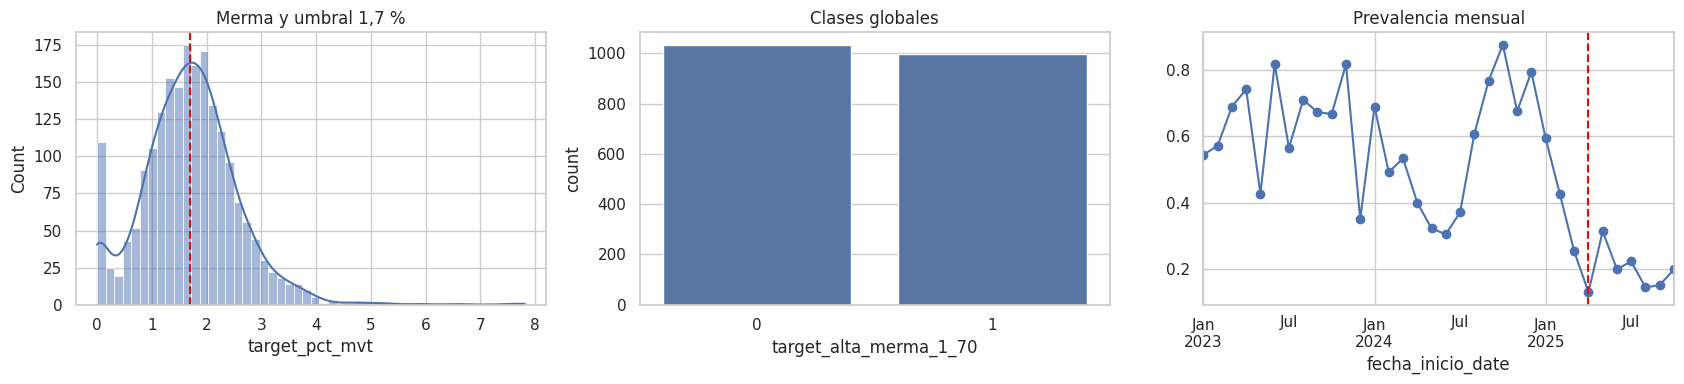

,mean,count
fecha_inicio_date,,
2023-11-01,0.816667,60
2023-12-01,0.350877,57
2024-01-01,0.688525,61
2024-02-01,0.491525,59
2024-03-01,0.533333,60
2024-04-01,0.400000,60
2024-05-01,0.322581,62
2024-06-01,0.305085,59
2024-07-01,0.370968,62


In [ ]:
display(modelable[TARGET].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_frame())

monthly = modelable.set_index(date_col).resample('MS')[TARGET_CLASS].agg(['mean','count'])
fig, axes = plt.subplots(1,3,figsize=(17,4))
sns.histplot(modelable[TARGET], bins=50, kde=True, ax=axes[0])
axes[0].axvline(CUTOFF,color='red',ls='--'); axes[0].set_title('Merma y umbral 1,7 %')
sns.countplot(data=modelable,x=TARGET_CLASS,ax=axes[1]); axes[1].set_title('Clases globales')
monthly['mean'].plot(ax=axes[2],marker='o'); axes[2].axvline(TEST_START,color='red',ls='--')
axes[2].set_title('Prevalencia mensual')
plt.tight_layout(); plt.savefig(OUT/'eda_target_clases_tiempo.png',dpi=160); plt.show()
display(monthly.tail(24))


## 6. INGENIERÍA DE VARIABLES


In [ ]:
def add_engineered_features(source):
    out=source.copy()
    num=lambda name: pd.to_numeric(out[name],errors='coerce')

    if 'carga_guias_n' in out: out['fe_viajes_lote_n']=num('carga_guias_n')
    if 'mes' in out:
        out['fe_mes_sin']=np.sin(2*np.pi*num('mes')/12); out['fe_mes_cos']=np.cos(2*np.pi*num('mes')/12)
    if 'dia_semana' in out:
        out['fe_dia_semana_sin']=np.sin(2*np.pi*num('dia_semana')/7); out['fe_dia_semana_cos']=np.cos(2*np.pi*num('dia_semana')/7)

    guide_specs={
        'fe_guia_duracion_salida_cd_horas_mean':('duracion_salida_cd_horas','mean'),
        'fe_guia_duracion_salida_cd_horas_max':('duracion_salida_cd_horas','max'),
        'fe_guia_duracion_salida_cd_horas_std':('duracion_salida_cd_horas','std'),
        'fe_guia_dist_granja_cd_via_cruce_km_max':('dist_granja_cd_via_cruce_km','max'),
        'fe_guia_velocidad_proxy_kmh_min':('velocidad_proxy_kmh','min'),
        'fe_guia_velocidad_proxy_kmh_mean':('velocidad_proxy_kmh','mean'),
        'fe_guia_velocidad_proxy_kmh_max':('velocidad_proxy_kmh','max'),
    }
    for new,(suffix,stat) in guide_specs.items():
        cols=[c for c in out if re.match(rf'^guia_\d{{2}}_{re.escape(suffix)}$',c)]
        if cols:
            values=out[cols].apply(pd.to_numeric,errors='coerce')
            out[new]=getattr(values,stat)(axis=1,skipna=True)

    interactions={
        'fe_cubicaje_x_duracion_viaje':('cubicaje_ocupacion_camion_ratio_mean','fe_guia_duracion_salida_cd_horas_mean'),
        'fe_thi_ayuno_x_horas_ayuno':('clima_inicio_ayuno_clima_thi_proxy_mean','ayuno_horas_hasta_hora_llena_mean'),
        'fe_aves_jaba_x_thi_transporte':('hacinamiento_unidades_por_jaba_global','clima_transporte_clima_thi_proxy_mean'),
        'fe_kg_jaba_x_temp_transporte':('hacinamiento_kg_pollo_por_jaba_global','clima_transporte_clima_temp_2m_c_mean'),
        'fe_aves_jaba_x_duracion_viaje':('hacinamiento_unidades_por_jaba_global','fe_guia_duracion_salida_cd_horas_mean'),
        'fe_cubicaje_x_thi_transporte':('cubicaje_ocupacion_camion_ratio_mean','clima_transporte_clima_thi_proxy_mean'),
        'fe_peso_ave_x_temp_transporte':('pp_granja_base','clima_transporte_clima_temp_2m_c_mean'),
        'fe_densidad_x_duracion_viaje':('ind65_densidad_aves_m2_pond_kg','fe_guia_duracion_salida_cd_horas_mean'),
        'fe_densidad_x_retorno':('ind65_densidad_aves_m2_pond_kg','tiempo_retorno_horas_mean'),
        'fe_peso_ave_x_thi_transporte':('pp_granja_base','clima_transporte_clima_thi_proxy_mean'),
        'fe_ayuno_x_aves_jaba':('ayuno_horas_hasta_hora_llena_mean','hacinamiento_unidades_por_jaba_global'),
    }
    for new,(left,right) in interactions.items():
        if left in out and right in out: out[new]=num(left)*num(right)

    ranges={
        'fe_clima_transporte_rango_thi':('clima_transporte_clima_thi_proxy_max','clima_transporte_clima_thi_proxy_min'),
        'fe_clima_transporte_rango_temp_c':('clima_transporte_clima_temp_2m_c_max','clima_transporte_clima_temp_2m_c_min'),
        'fe_clima_inicio_ayuno_rango_thi':('clima_inicio_ayuno_clima_thi_proxy_max','clima_inicio_ayuno_clima_thi_proxy_min'),
        'fe_clima_salida_granja_rango_thi':('clima_salida_granja_clima_thi_proxy_max','clima_salida_granja_clima_thi_proxy_min'),
        'fe_clima_llegada_cd_rango_thi':('clima_llegada_cd_clima_thi_proxy_max','clima_llegada_cd_clima_thi_proxy_min'),
    }
    for new,(maximum,minimum) in ranges.items():
        if maximum in out and minimum in out: out[new]=num(maximum)-num(minimum)

    mort=[c for c in [f'mort59_pct_sem{i}' for i in range(1,8)] if c in out]
    if mort:
        values=out[mort].apply(pd.to_numeric,errors='coerce')
        out['fe_mort59_pct_semanal_mean']=values.mean(axis=1)
        out['fe_mort59_pct_semanal_max']=values.max(axis=1)
    if len(mort)>=4:
        out['fe_mort59_tendencia_pct']=values[mort[-2:]].mean(axis=1)-values[mort[:2]].mean(axis=1)
    return out

modelable=add_engineered_features(modelable)
train_all=modelable.loc[modelable[date_col]<TEST_START].copy().reset_index(drop=True)
test_sensibilidad=modelable.loc[modelable[date_col]>=TEST_START].copy().reset_index(drop=True)


## 7. Trazabilidad de variables originales, derivadas y conjuntos 77, 76, 74, 20 y 18


In [ ]:
FEATURES_77 = [
  "fe_cubicaje_x_duracion_viaje",
  "ind65_densidad_aves_m2_pond_kg",
  "fe_guia_dist_granja_cd_via_cruce_km_max",
  "ayuno_horas_hasta_hora_llena_mean",
  "fe_thi_ayuno_x_horas_ayuno",
  "ayuno_horas_hasta_hora_llena_max",
  "carga_jabas_por_guia_max",
  "fe_mes_sin",
  "tiempo_retorno_horas_max",
  "clima_llegada_cd_clima_temp_2m_c_min",
  "pp_granja_base",
  "clima_transporte_clima_radiacion_corta_wm2_mean",
  "fe_guia_velocidad_proxy_kmh_min",
  "clima_llegada_cd_clima_racha_10m_kmh_max",
  "clima_transporte_clima_deficit_presion_vapor_kpa_mean",
  "fe_guia_velocidad_proxy_kmh_mean",
  "fe_aves_jaba_x_thi_transporte",
  "ind65_pollo_bb_ingresado_pond_kg",
  "carga_jabas_por_guia_min",
  "clima_transporte_clima_temp_2m_c_mean",
  "clima_inicio_ayuno_clima_radiacion_corta_wm2_mean",
  "clima_llegada_cd_clima_radiacion_corta_wm2_max",
  "clima_llegada_cd_clima_viento_10m_kmh_mean",
  "fe_kg_jaba_x_temp_transporte",
  "clima_transporte_clima_viento_10m_kmh_mean",
  "fe_mes_cos",
  "clima_llegada_cd_clima_temp_2m_c_mean",
  "mort59_pct_sem2",
  "fe_aves_jaba_x_duracion_viaje",
  "clima_llegada_cd_clima_radiacion_corta_wm2_mean",
  "fe_dia_semana_sin",
  "kg_ingreso_cd_base",
  "fe_viajes_lote_n",
  "clima_transporte_clima_deficit_presion_vapor_kpa_max",
  "clima_inicio_ayuno_clima_radiacion_corta_wm2_max",
  "fe_cubicaje_x_thi_transporte",
  "fe_clima_transporte_rango_thi",
  "pct_merma_viaje_base",
  "carga_peso_jabas_ratio_total",
  "ind65_preparacion_granja_dias_pond_kg",
  "clima_llegada_cd_clima_deficit_presion_vapor_kpa_max",
  "uni_ingreso_cd_base",
  "mort59_pct_sem1",
  "carga_unidades_por_guia_max",
  "pct_muertos_viaje_base",
  "kg_muertos_viaje_base",
  "saca_duracion_horas_mean",
  "clima_transporte_clima_hr_2m_pct_max",
  "clima_salida_granja_clima_thi_proxy_max",
  "carga_jabas_por_guia_std",
  "mort47_unidades_acum_hasta_salida",
  "mort59_pct_sem4",
  "fe_peso_ave_x_temp_transporte",
  "clima_llegada_cd_clima_viento_10m_kmh_max",
  "mort59_pct_sem3",
  "clima_salida_granja_clima_racha_10m_kmh_max",
  "ayuno_jabas_sum",
  "fe_mort59_tendencia_pct",
  "carga_unidades_por_guia_mean",
  "mort59_pct_sem1_3",
  "fe_guia_velocidad_proxy_kmh_max",
  "mort59_pct_sem6_7",
  "mort59_pct_acum_hasta_edad_saca",
  "clima_inicio_ayuno_clima_viento_10m_kmh_max",
  "ayuno_horas_hasta_fin_saca_max",
  "tiempo_ida_horas_mean",
  "tiempo_ida_horas_max",
  "clima_llegada_cd_clima_temp_2m_c_max",
  "mort59_pct_sem4_5",
  "fe_clima_transporte_rango_temp_c",
  "clima_salida_granja_clima_temp_2m_c_max",
  "clima_inicio_ayuno_clima_deficit_presion_vapor_kpa_max",
  "clima_inicio_ayuno_clima_thi_proxy_max",
  "ayuno_unidades_hembra_sum",
  "clima_salida_granja_clima_radiacion_corta_wm2_mean",
  "clima_salida_granja_clima_viento_10m_kmh_mean",
  "fe_dia_semana_cos"
]

FEATURES_74 = [
  "fe_cubicaje_x_duracion_viaje",
  "ind65_densidad_aves_m2_pond_kg",
  "fe_guia_dist_granja_cd_via_cruce_km_max",
  "ayuno_horas_hasta_hora_llena_mean",
  "fe_thi_ayuno_x_horas_ayuno",
  "ayuno_horas_hasta_hora_llena_max",
  "carga_jabas_por_guia_max",
  "fe_mes_sin",
  "tiempo_retorno_horas_max",
  "clima_llegada_cd_clima_temp_2m_c_min",
  "pp_granja_base",
  "clima_transporte_clima_radiacion_corta_wm2_mean",
  "fe_guia_velocidad_proxy_kmh_min",
  "clima_llegada_cd_clima_racha_10m_kmh_max",
  "clima_transporte_clima_deficit_presion_vapor_kpa_mean",
  "fe_guia_velocidad_proxy_kmh_mean",
  "fe_aves_jaba_x_thi_transporte",
  "ind65_pollo_bb_ingresado_pond_kg",
  "carga_jabas_por_guia_min",
  "clima_transporte_clima_temp_2m_c_mean",
  "clima_inicio_ayuno_clima_radiacion_corta_wm2_mean",
  "clima_llegada_cd_clima_radiacion_corta_wm2_max",
  "clima_llegada_cd_clima_viento_10m_kmh_mean",
  "fe_kg_jaba_x_temp_transporte",
  "clima_transporte_clima_viento_10m_kmh_mean",
  "fe_mes_cos",
  "clima_llegada_cd_clima_temp_2m_c_mean",
  "mort59_pct_sem2",
  "fe_aves_jaba_x_duracion_viaje",
  "clima_llegada_cd_clima_radiacion_corta_wm2_mean",
  "fe_dia_semana_sin",
  "kg_ingreso_cd_base",
  "fe_viajes_lote_n",
  "clima_transporte_clima_deficit_presion_vapor_kpa_max",
  "clima_inicio_ayuno_clima_radiacion_corta_wm2_max",
  "fe_cubicaje_x_thi_transporte",
  "fe_clima_transporte_rango_thi",
  "carga_peso_jabas_ratio_total",
  "ind65_preparacion_granja_dias_pond_kg",
  "clima_llegada_cd_clima_deficit_presion_vapor_kpa_max",
  "uni_ingreso_cd_base",
  "mort59_pct_sem1",
  "carga_unidades_por_guia_max",
  "saca_duracion_horas_mean",
  "clima_transporte_clima_hr_2m_pct_max",
  "clima_salida_granja_clima_thi_proxy_max",
  "carga_jabas_por_guia_std",
  "mort47_unidades_acum_hasta_salida",
  "mort59_pct_sem4",
  "fe_peso_ave_x_temp_transporte",
  "clima_llegada_cd_clima_viento_10m_kmh_max",
  "mort59_pct_sem3",
  "clima_salida_granja_clima_racha_10m_kmh_max",
  "ayuno_jabas_sum",
  "fe_mort59_tendencia_pct",
  "carga_unidades_por_guia_mean",
  "mort59_pct_sem1_3",
  "fe_guia_velocidad_proxy_kmh_max",
  "mort59_pct_sem6_7",
  "mort59_pct_acum_hasta_edad_saca",
  "clima_inicio_ayuno_clima_viento_10m_kmh_max",
  "ayuno_horas_hasta_fin_saca_max",
  "tiempo_ida_horas_mean",
  "tiempo_ida_horas_max",
  "clima_llegada_cd_clima_temp_2m_c_max",
  "mort59_pct_sem4_5",
  "fe_clima_transporte_rango_temp_c",
  "clima_salida_granja_clima_temp_2m_c_max",
  "clima_inicio_ayuno_clima_deficit_presion_vapor_kpa_max",
  "clima_inicio_ayuno_clima_thi_proxy_max",
  "ayuno_unidades_hembra_sum",
  "clima_salida_granja_clima_radiacion_corta_wm2_mean",
  "clima_salida_granja_clima_viento_10m_kmh_mean",
  "fe_dia_semana_cos"
]

FEATURES_20_REPORTADAS = [
  "ayuno_horas_hasta_hora_llena_mean",
  "ayuno_horas_hasta_hora_llena_max",
  "fe_cubicaje_x_duracion_viaje",
  "kg_ingreso_cd_base",
  "ind65_densidad_aves_m2_pond_kg",
  "fe_thi_ayuno_x_horas_ayuno",
  "tiempo_retorno_horas_max",
  "uni_ingreso_cd_base",
  "clima_transporte_clima_viento_10m_kmh_mean",
  "fe_kg_jaba_x_temp_transporte",
  "ind65_pollo_bb_ingresado_pond_kg",
  "carga_jabas_por_guia_max",
  "ayuno_horas_hasta_fin_saca_max",
  "carga_unidades_por_guia_max",
  "clima_transporte_clima_radiacion_corta_wm2_mean",
  "clima_transporte_clima_temp_2m_c_mean",
  "pp_granja_base",
  "fe_guia_dist_granja_cd_via_cruce_km_max",
  "mort59_pct_sem2",
  "clima_llegada_cd_clima_radiacion_corta_wm2_mean"
]

CANDIDATES_12 = [
  "fe_guia_duracion_salida_cd_horas_mean",
  "fe_guia_duracion_salida_cd_horas_max",
  "fe_guia_duracion_salida_cd_horas_std",
  "fe_densidad_x_duracion_viaje",
  "fe_densidad_x_retorno",
  "fe_peso_ave_x_thi_transporte",
  "fe_ayuno_x_aves_jaba",
  "fe_mort59_pct_semanal_mean",
  "fe_mort59_pct_semanal_max",
  "fe_clima_inicio_ayuno_rango_thi",
  "fe_clima_salida_granja_rango_thi",
  "fe_clima_llegada_cd_rango_thi"
]

DICCIONARIO_20 = [
  {
    "orden_recomendado": 1,
    "variable_origen": "ayuno_horas_hasta_hora_llena_mean",
    "familia": "Ayuno y saca",
    "descripcion": "Horas desde Hora Ayuno hasta hora_llena; valor promedio por lote comercial.",
    "justificacion_operativa": "Mide duracion, volumen o dispersion del proceso previo a la venta.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 2,
    "variable_origen": "ayuno_horas_hasta_hora_llena_max",
    "familia": "Ayuno y saca",
    "descripcion": "Horas desde Hora Ayuno hasta hora_llena; valor maximo por lote comercial.",
    "justificacion_operativa": "Mide duracion, volumen o dispersion del proceso previo a la venta.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 3,
    "variable_origen": "fe_cubicaje_x_duracion_viaje",
    "familia": "Interacciones operativas",
    "descripcion": "Interaccion entre ocupacion del camion y duracion del viaje.",
    "justificacion_operativa": "Combina componentes fisicos disponibles al horizonte para representar exposicion o intensidad operativa.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Disponible despues de llegada al CD y antes de venta/facturacion; usa solo componentes operativos del lote.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 4,
    "variable_origen": "kg_ingreso_cd_base",
    "familia": "Base Pollo Vivo",
    "descripcion": "Kilos ingresados al CD.",
    "justificacion_operativa": "Caracteristica fisica del lote disponible al ingreso al CD.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 5,
    "variable_origen": "ind65_densidad_aves_m2_pond_kg",
    "familia": "Indicadores avicolas Reporte 65",
    "descripcion": "Densidad de aves por metro cuadrado.",
    "justificacion_operativa": "Caracteriza densidad, preparacion o condiciones de crianza anteriores.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Usar solo si el indicador estaba disponible antes de la venta/salida; en esta matriz se priorizaron indicadores relativamente seguros, revisar temporalidad si se amplia Reporte 65.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 6,
    "variable_origen": "fe_thi_ayuno_x_horas_ayuno",
    "familia": "Interacciones operativas con clima",
    "descripcion": "Exposicion conjunta a THI y duracion de ayuno.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Disponible despues de llegada al CD y antes de venta/facturacion; usa solo componentes operativos del lote.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 7,
    "variable_origen": "tiempo_retorno_horas_max",
    "familia": "Ayuno y saca",
    "descripcion": "tiempo_retorno_horas convertido a horas.",
    "justificacion_operativa": "Mide duracion, volumen o dispersion del proceso previo a la venta.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 8,
    "variable_origen": "uni_ingreso_cd_base",
    "familia": "Base Pollo Vivo",
    "descripcion": "Unidades ingresadas al CD.",
    "justificacion_operativa": "Caracteristica fisica del lote disponible al ingreso al CD.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 9,
    "variable_origen": "clima_transporte_clima_viento_10m_kmh_mean",
    "familia": "Clima Open-Meteo",
    "descripcion": "Promedio de Velocidad del viento a 10 m en km/h. Ambito: Solo tramo transporte: salida_granja, cruce_proxy y llegada_cd.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Sin leakage de target si se interpreta como clima observado/forecast disponible en el evento; en produccion requeriria pronostico o sensor.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 10,
    "variable_origen": "fe_kg_jaba_x_temp_transporte",
    "familia": "Interacciones operativas con clima",
    "descripcion": "Interaccion entre kilos de pollo por jaba y temperatura de transporte.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Disponible despues de llegada al CD y antes de venta/facturacion; usa solo componentes operativos del lote.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 11,
    "variable_origen": "ind65_pollo_bb_ingresado_pond_kg",
    "familia": "Indicadores avicolas Reporte 65",
    "descripcion": "Pollos BB ingresados al lote de granja.",
    "justificacion_operativa": "Caracteriza densidad, preparacion o condiciones de crianza anteriores.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Usar solo si el indicador estaba disponible antes de la venta/salida; en esta matriz se priorizaron indicadores relativamente seguros, revisar temporalidad si se amplia Reporte 65.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 12,
    "variable_origen": "carga_jabas_por_guia_max",
    "familia": "Jabas, carga, hacinamiento y cubicaje",
    "descripcion": "max de jabas_por_guia por guia.",
    "justificacion_operativa": "Describe jabas, aves, peso y ocupacion del transporte.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 13,
    "variable_origen": "ayuno_horas_hasta_fin_saca_max",
    "familia": "Ayuno y saca",
    "descripcion": "Horas desde Hora Ayuno hasta fin_saca; valor maximo por lote comercial.",
    "justificacion_operativa": "Mide duracion, volumen o dispersion del proceso previo a la venta.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 14,
    "variable_origen": "carga_unidades_por_guia_max",
    "familia": "Jabas, carga, hacinamiento y cubicaje",
    "descripcion": "max de unidades_por_guia por guia.",
    "justificacion_operativa": "Describe jabas, aves, peso y ocupacion del transporte.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 15,
    "variable_origen": "clima_transporte_clima_radiacion_corta_wm2_mean",
    "familia": "Clima Open-Meteo",
    "descripcion": "Promedio de Radiacion de onda corta en W/m2. Ambito: Solo tramo transporte: salida_granja, cruce_proxy y llegada_cd.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Sin leakage de target si se interpreta como clima observado/forecast disponible en el evento; en produccion requeriria pronostico o sensor.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 16,
    "variable_origen": "clima_transporte_clima_temp_2m_c_mean",
    "familia": "Clima Open-Meteo",
    "descripcion": "Promedio de Temperatura del aire a 2 m en grados Celsius. Ambito: Solo tramo transporte: salida_granja, cruce_proxy y llegada_cd.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Sin leakage de target si se interpreta como clima observado/forecast disponible en el evento; en produccion requeriria pronostico o sensor.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 17,
    "variable_origen": "pp_granja_base",
    "familia": "Base Pollo Vivo",
    "descripcion": "Peso promedio de granja.",
    "justificacion_operativa": "Caracteristica fisica del lote disponible al ingreso al CD.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 18,
    "variable_origen": "fe_guia_dist_granja_cd_via_cruce_km_max",
    "familia": "Logistica agregada por lote",
    "descripcion": "max por lote de dist_granja_cd_via_cruce_km entre guias.",
    "justificacion_operativa": "Resume distancia, velocidad, duracion o cantidad de viajes del lote.",
    "riesgo_interpretativo": "Sin alerta semantica adicional; mantener interpretacion asociativa.",
    "criterio_leakage_temporal": "Disponible despues de llegada al CD y antes de venta/facturacion; usa solo componentes operativos del lote.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 19,
    "variable_origen": "mort59_pct_sem2",
    "familia": "Mortalidad semanal Reporte 59",
    "descripcion": "Porcentaje de mortalidad en semana de edad 2.",
    "justificacion_operativa": "Resume mortalidad o tendencia sanitaria observada antes del lote comercial.",
    "riesgo_interpretativo": "Historia sanitaria agregada previa; vigilar cambios de captura.",
    "criterio_leakage_temporal": "Potencial predictor, sujeto a validacion temporal y a que este disponible antes del momento de prediccion definido.",
    "escenario_seleccion": "nested_top_20"
  },
  {
    "orden_recomendado": 20,
    "variable_origen": "clima_llegada_cd_clima_radiacion_corta_wm2_mean",
    "familia": "Clima Open-Meteo",
    "descripcion": "Promedio de Radiacion de onda corta en W/m2. Ambito: Llegada al CD Pachacutec.",
    "justificacion_operativa": "Condicion meteorologica asociada a ayuno, salida, transporte o llegada del lote.",
    "riesgo_interpretativo": "Contexto ambiental; no interpretar como causalidad aislada.",
    "criterio_leakage_temporal": "Sin leakage de target si se interpreta como clima observado/forecast disponible en el evento; en produccion requeriria pronostico o sensor.",
    "escenario_seleccion": "nested_top_20"
  }
]


FEATURES_18_REPORTADAS = [
  "ayuno_horas_hasta_hora_llena_mean",
  "fe_cubicaje_x_duracion_viaje",
  "kg_ingreso_cd_base",
  "ind65_densidad_aves_m2_pond_kg",
  "fe_thi_ayuno_x_horas_ayuno",
  "tiempo_retorno_horas_max",
  "clima_transporte_clima_viento_10m_kmh_mean",
  "fe_kg_jaba_x_temp_transporte",
  "ind65_pollo_bb_ingresado_pond_kg",
  "carga_jabas_por_guia_max",
  "ayuno_horas_hasta_fin_saca_max",
  "carga_unidades_por_guia_max",
  "clima_transporte_clima_radiacion_corta_wm2_mean",
  "clima_transporte_clima_temp_2m_c_mean",
  "pp_granja_base",
  "fe_guia_dist_granja_cd_via_cruce_km_max",
  "mort59_pct_sem2",
  "clima_llegada_cd_clima_radiacion_corta_wm2_mean"
]
EXCLUSIONES_PARA_18 = ['uni_ingreso_cd_base', 'ayuno_horas_hasta_hora_llena_max']

LEAKAGE_TARGET_ADJACENT = ['pct_merma_viaje_base','pct_muertos_viaje_base','kg_muertos_viaje_base']
FEATURES_76 = [c for c in FEATURES_77 if c != 'pct_merma_viaje_base']
FEATURES_86 = FEATURES_74 + [c for c in CANDIDATES_12 if c not in FEATURES_74]

trace = pd.DataFrame([
    {'conjunto':'77 conservadoras heredadas','n':len(FEATURES_77),'uso':'sensibilidad'},
    {'conjunto':'76 sin pct_merma_viaje_base','n':len(FEATURES_76),'uso':'sensibilidad de proximidad al target'},
    {'conjunto':'74 sin merma/mortalidad de viaje','n':len(FEATURES_74),'uso':'base auditable de clasificación'},
    {'conjunto':'86 = 74 + 12 candidatas','n':len(FEATURES_86),'uso':'prueba de ampliación'},
    {'conjunto':'20 SHAP estables reportadas','n':len(FEATURES_20_REPORTADAS),'uso':'selección intermedia'},
    {'conjunto':'18 sin redundancias colineales','n':len(FEATURES_18_REPORTADAS),'uso':'modelo final'},
])
display(trace)
display(pd.DataFrame(DICCIONARIO_20))

required=sorted(set(FEATURES_77+FEATURES_86+FEATURES_20_REPORTADAS+FEATURES_18_REPORTADAS))
missing=[c for c in required if c not in modelable]
if missing: raise ValueError(f'Variables requeridas no construidas: {missing}')
for c in required: modelable[c]=pd.to_numeric(modelable[c],errors='coerce')
train_all=modelable.loc[modelable[date_col]<TEST_START].copy().reset_index(drop=True)
test_sensibilidad=modelable.loc[modelable[date_col]>=TEST_START].copy().reset_index(drop=True)

quality=quality_profile(train_all, FEATURES_74)
display(quality.sort_values('faltantes_pct',ascending=False).head(30))
quality.to_csv(OUT/'perfil_faltantes_outliers_74.csv',index=False)


,conjunto,n,uso
0,77 conservadoras heredadas,77,sensibilidad
1,76 sin pct_merma_viaje_base,76,sensibilidad de proximidad al target
2,74 sin merma/mortalidad de viaje,74,base auditable de clasificación
3,86 = 74 + 12 candidatas,86,prueba de ampliación
4,20 SHAP estables reportadas,20,selección intermedia
5,18 sin redundancias colineales,18,modelo final


,orden_recomendado,variable_origen,familia,descripcion,justificacion_operativa,riesgo_interpretativo,criterio_leakage_temporal,escenario_seleccion
0,1,ayuno_horas_hasta_hora_llena_mean,Ayuno y saca,Horas desde Hora Ayuno hasta hora_llena; valor...,"Mide duracion, volumen o dispersion del proces...",Sin alerta semantica adicional; mantener inter...,"Potencial predictor, sujeto a validacion tempo...",nested_top_20
1,2,ayuno_horas_hasta_hora_llena_max,Ayuno y saca,Horas desde Hora Ayuno hasta hora_llena; valor...,"Mide duracion, volumen o dispersion del proces...",Sin alerta semantica adicional; mantener inter...,"Potencial predictor, sujeto a validacion tempo...",nested_top_20
2,3,fe_cubicaje_x_duracion_viaje,Interacciones operativas,Interaccion entre ocupacion del camion y durac...,Combina componentes fisicos disponibles al hor...,Sin alerta semantica adicional; mantener inter...,Disponible despues de llegada al CD y antes de...,nested_top_20
3,4,kg_ingreso_cd_base,Base Pollo Vivo,Kilos ingresados al CD.,Caracteristica fisica del lote disponible al i...,Sin alerta semantica adicional; mantener inter...,"Potencial predictor, sujeto a validacion tempo...",nested_top_20
4,5,ind65_densidad_aves_m2_pond_kg,Indicadores avicolas Reporte 65,Densidad de aves por metro cuadrado.,"Caracteriza densidad, preparacion o condicione...",Sin alerta semantica adicional; mantener inter...,Usar solo si el indicador estaba disponible an...,nested_top_20
5,6,fe_thi_ayuno_x_horas_ayuno,Interacciones operativas con clima,Exposicion conjunta a THI y duracion de ayuno.,"Condicion meteorologica asociada a ayuno, sali...",Contexto ambiental; no interpretar como causal...,Disponible despues de llegada al CD y antes de...,nested_top_20
6,7,tiempo_retorno_horas_max,Ayuno y saca,tiempo_retorno_horas convertido a horas.,"Mide duracion, volumen o dispersion del proces...",Sin alerta semantica adicional; mantener inter...,"Potencial predictor, sujeto a validacion tempo...",nested_top_20
7,8,uni_ingreso_cd_base,Base Pollo Vivo,Unidades ingresadas al CD.,Caracteristica fisica del lote disponible al i...,Sin alerta semantica adicional; mantener inter...,"Potencial predictor, sujeto a validacion tempo...",nested_top_20
8,9,clima_transporte_clima_viento_10m_kmh_mean,Clima Open-Meteo,Promedio de Velocidad del viento a 10 m en km/...,"Condicion meteorologica asociada a ayuno, sali...",Contexto ambiental; no interpretar como causal...,Sin leakage de target si se interpreta como cl...,nested_top_20
9,10,fe_kg_jaba_x_temp_transporte,Interacciones operativas con clima,Interaccion entre kilos de pollo por jaba y te...,"Condicion meteorologica asociada a ayuno, sali...",Contexto ambiental; no interpretar como causal...,Disponible despues de llegada al CD y antes de...,nested_top_20


,variable,faltantes_n,faltantes_pct,outliers_iqr_n,outliers_iqr_pct,valores_unicos
46,carga_jabas_por_guia_std,281,0.172923,25,0.018601,915
61,ayuno_horas_hasta_fin_saca_max,189,0.116308,33,0.022981,183
6,carga_jabas_por_guia_max,186,0.114462,2,0.001390,255
3,ayuno_horas_hasta_hora_llena_mean,186,0.114462,41,0.028492,858
4,fe_thi_ayuno_x_horas_ayuno,186,0.114462,54,0.037526,1438
5,ayuno_horas_hasta_hora_llena_max,186,0.114462,34,0.023628,370
9,clima_llegada_cd_clima_temp_2m_c_min,186,0.114462,5,0.003475,90
8,tiempo_retorno_horas_max,186,0.114462,28,0.019458,253
0,fe_cubicaje_x_duracion_viaje,186,0.114462,14,0.009729,1435
2,fe_guia_dist_granja_cd_via_cruce_km_max,186,0.114462,0,0.000000,27


## 8. TRANSFORMACIÓN Y VALIDACIÓN TEMPORAL PURGADA


In [ ]:
def purged_walk_forward(frame, n_splits=4):
    dates=frame[date_col].reset_index(drop=True)
    unique=np.asarray(sorted(dates.dropna().unique()))
    first=max(1,int(len(unique)*.30))
    blocks=np.array_split(unique[first:],n_splits)
    folds=[]
    for fold,block in enumerate(blocks,1):
        if not len(block): continue
        limit=pd.Timestamp(block.min())-pd.Timedelta(days=EMBARGO_DAYS)
        fit=np.flatnonzero((dates<limit).to_numpy())
        valid=np.flatnonzero(dates.isin(block).to_numpy())
        if len(fit) and len(valid): folds.append((fold,fit,valid))
    return folds

folds=purged_walk_forward(train_all,4)
fold_audit=pd.DataFrame([{
    'fold':fold,'train_n':len(fit),'valid_n':len(valid),
    'train_fin':train_all.iloc[fit][date_col].max(),
    'valid_inicio':train_all.iloc[valid][date_col].min(),
    'valid_fin':train_all.iloc[valid][date_col].max(),
} for fold,fit,valid in folds])
display(fold_audit)
fold_audit.to_csv(OUT/'folds_temporales_purgados.csv',index=False)

def fit_transform_fold(X_fit,X_valid):
    clipper=QuantileClipper().fit(X_fit)
    fit_clip=clipper.transform(X_fit); valid_clip=clipper.transform(X_valid)
    imputer=SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)
    return imputer.fit_transform(fit_clip),imputer.transform(valid_clip),clipper,imputer

def ece_score(y,p,bins=10):
    edges=np.linspace(0,1,bins+1); total=len(y); result=0
    for lo,hi in zip(edges[:-1],edges[1:]):
        mask=(p>=lo)&((p<hi) if hi<1 else (p<=hi))
        if mask.any(): result += mask.mean()*abs(y[mask].mean()-p[mask].mean())
    return result

def probability_metrics(y,p):
    p=np.clip(np.asarray(p,float),1e-6,1-1e-6)
    return {'n':len(y),'positivos':int(np.sum(y)),'prevalencia':float(np.mean(y)),
            'pr_auc':average_precision_score(y,p),'roc_auc':roc_auc_score(y,p),
            'brier':brier_score_loss(y,p),'log_loss':log_loss(y,p),
            'prob_media':float(np.mean(p)),'ece_10':ece_score(np.asarray(y),p)}


,fold,train_n,valid_n,train_fin,valid_inicio,valid_fin
0,1,464,284,2023-08-25,2023-09-02,2024-01-23
1,2,750,285,2024-01-16,2024-01-24,2024-06-14
2,3,1034,282,2024-06-07,2024-06-15,2024-11-24
3,4,1316,295,2024-11-17,2024-11-25,2025-04-19


## 9. Sensibilidad del target y 90 evaluaciones de modelos


In [ ]:
target_cutoffs={
    'alta_merma_empresa_1_70':1.70,
    'alta_merma_fijo_2_00':2.00,
    'alta_merma_p75_train':float(train_all[TARGET].quantile(.75)),
    'alta_merma_p90_train':float(train_all[TARGET].quantile(.90)),
}
screen_sets={
    '77_variables_conservadoras':FEATURES_77,
    '76_sin_pct_merma_viaje_base':FEATURES_76,
    '74_sin_merma_mortalidad_viaje_base':FEATURES_74,
}

SCREEN_MODELS=['baseline_prevalencia_train','logit_l2_balanceada_c035',
               'hgb_lr045_l15_leaf20','lgbm_lr04_l15_leaf25','xgb_lr04_d3_child8']
TUNE_MODELS=['rf_balanceado_leaf10','hgb_lr035_l15_leaf25','hgb_lr03_l31_leaf15','hgb_lr06_l11_leaf25',
             'lgbm_lr025_l31_leaf20','lgbm_lr03_l15_leaf30','lgbm_lr05_l11_leaf35',
             'xgb_lr025_d2_child8','xgb_lr03_d3_child10','xgb_lr05_d2_child12']

def make_model(name,pos_weight=1.0):
    def n(default): return 20 if MODO_RAPIDO else default
    if name=='logit_l2_balanceada_c035':
        return Pipeline([('scale',StandardScaler()),('model',LogisticRegression(C=.35,class_weight='balanced',max_iter=2000,random_state=RANDOM_STATE,n_jobs=1))])
    if name=='rf_balanceado_leaf10':
        return RandomForestClassifier(n_estimators=n(250),min_samples_leaf=10,max_features='sqrt',class_weight='balanced_subsample',random_state=RANDOM_STATE,n_jobs=-1)
    hgb_specs={
        'hgb_lr045_l15_leaf20':(.045,15,20,.08),
        'hgb_lr035_l15_leaf25':(.035,15,25,.12),
        'hgb_lr06_l11_leaf25':(.060,11,25,.12),
        'hgb_lr03_l31_leaf15':(.030,31,15,.04),
    }
    if name in hgb_specs:
        lr,leaves,leaf,l2=hgb_specs[name]
        return HistGradientBoostingClassifier(learning_rate=lr,max_leaf_nodes=leaves,min_samples_leaf=leaf,l2_regularization=l2,random_state=RANDOM_STATE)
    lgb_specs={
        'lgbm_lr04_l15_leaf25':(220,.04,15,25,.15),
        'lgbm_lr03_l15_leaf30':(320,.03,15,30,.25),
        'lgbm_lr025_l31_leaf20':(420,.025,31,20,.20),
        'lgbm_lr05_l11_leaf35':(240,.05,11,35,.30),
    }
    if name in lgb_specs:
        from lightgbm import LGBMClassifier
        trees,lr,leaves,leaf,reg=lgb_specs[name]
        return LGBMClassifier(n_estimators=n(trees),learning_rate=lr,num_leaves=leaves,min_child_samples=leaf,
                              subsample=.85,colsample_bytree=.85,reg_alpha=reg,reg_lambda=reg*2,
                              scale_pos_weight=pos_weight,objective='binary',random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1)
    xgb_specs={
        'xgb_lr04_d3_child8':(220,.04,3,8,1.0),
        'xgb_lr03_d3_child10':(320,.03,3,10,1.2),
        'xgb_lr025_d2_child8':(420,.025,2,8,1.4),
        'xgb_lr05_d2_child12':(240,.05,2,12,1.5),
    }
    if name in xgb_specs:
        from xgboost import XGBClassifier
        trees,lr,depth,child,reg=xgb_specs[name]
        return XGBClassifier(n_estimators=n(trees),learning_rate=lr,max_depth=depth,min_child_weight=child,
                             subsample=.85,colsample_bytree=.85,reg_alpha=.05,reg_lambda=reg,
                             scale_pos_weight=pos_weight,objective='binary:logistic',eval_metric='logloss',tree_method='hist',
                             random_state=RANDOM_STATE,n_jobs=-1,verbosity=0)
    raise ValueError(name)

def evaluate_configuration(features,cutoff,model_name):
    y=train_all[TARGET].ge(cutoff).astype(int).to_numpy(); oof=np.full(len(y),np.nan)
    for _,fit_idx,valid_idx in folds:
        y_fit=y[fit_idx]
        if model_name=='baseline_prevalencia_train':
            oof[valid_idx]=y_fit.mean(); continue
        Xf,Xv,_,_=fit_transform_fold(train_all.iloc[fit_idx][features],train_all.iloc[valid_idx][features])
        pos=y_fit.sum(); neg=len(y_fit)-pos; model=make_model(model_name,neg/max(pos,1)); model.fit(Xf,y_fit); oof[valid_idx]=model.predict_proba(Xv)[:,1]
    mask=~np.isnan(oof); return probability_metrics(y[mask],oof[mask])

screen_rows=[]
for target_name,cutoff in target_cutoffs.items():
    for set_name,features in screen_sets.items():
        for model_name in SCREEN_MODELS:
            screen_rows.append({'target':target_name,'cutoff':cutoff,'feature_set':set_name,'variables_n':len(features),
                                'modelo':model_name,'stage':'screen',**evaluate_configuration(features,cutoff,model_name)})
for set_name,features in screen_sets.items():
    for model_name in TUNE_MODELS:
        screen_rows.append({'target':'alta_merma_empresa_1_70','cutoff':1.70,'feature_set':set_name,'variables_n':len(features),
                            'modelo':model_name,'stage':'tune',**evaluate_configuration(features,1.70,model_name)})

modelos_90=pd.DataFrame(screen_rows).sort_values(['target','pr_auc'],ascending=[True,False])
print('Evaluaciones ejecutadas:',len(modelos_90))
display(modelos_90.groupby(['target','stage']).size().rename('corridas').to_frame())
display(modelos_90.groupby('target').head(5))
modelos_90.to_csv(OUT/'modelos_90_evaluaciones_cv_oof.csv',index=False)


Evaluaciones ejecutadas: 90


corridas
target                  stage           
alta_merma_empresa_1_70 screen        15
                        tune          30
alta_merma_fijo_2_00    screen        15
alta_merma_p75_train    screen        15
alta_merma_p90_train    screen        15

,target,cutoff,feature_set,variables_n,modelo,stage,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
80,alta_merma_empresa_1_70,1.70,74_sin_merma_mortalidad_viaje_base,74,rf_balanceado_leaf10,tune,1146,609,0.531414,0.794405,0.773757,0.196213,0.576579,0.560855,0.049882
70,alta_merma_empresa_1_70,1.70,76_sin_pct_merma_viaje_base,76,rf_balanceado_leaf10,tune,1146,609,0.531414,0.792181,0.775439,0.195240,0.574879,0.555117,0.049345
62,alta_merma_empresa_1_70,1.70,77_variables_conservadoras,77,hgb_lr03_l31_leaf15,tune,1146,609,0.531414,0.788960,0.770598,0.206695,0.604794,0.622675,0.098188
67,alta_merma_empresa_1_70,1.70,77_variables_conservadoras,77,xgb_lr025_d2_child8,tune,1146,609,0.531414,0.788922,0.770641,0.195823,0.575928,0.555486,0.043176
89,alta_merma_empresa_1_70,1.70,74_sin_merma_mortalidad_viaje_base,74,xgb_lr05_d2_child12,tune,1146,609,0.531414,0.787404,0.763843,0.198927,0.583714,0.556514,0.041174
26,alta_merma_fijo_2_00,2.00,74_sin_merma_mortalidad_viaje_base,74,logit_l2_balanceada_c035,screen,1146,420,0.366492,0.643365,0.758399,0.212444,0.627534,0.507249,0.147289
21,alta_merma_fijo_2_00,2.00,76_sin_pct_merma_viaje_base,76,logit_l2_balanceada_c035,screen,1146,420,0.366492,0.641088,0.751981,0.215010,0.633489,0.505736,0.145016
16,alta_merma_fijo_2_00,2.00,77_variables_conservadoras,77,logit_l2_balanceada_c035,screen,1146,420,0.366492,0.637587,0.749282,0.216041,0.636733,0.505350,0.146256
27,alta_merma_fijo_2_00,2.00,74_sin_merma_mortalidad_viaje_base,74,hgb_lr045_l15_leaf20,screen,1146,420,0.366492,0.633697,0.757648,0.194274,0.576244,0.417358,0.066695
19,alta_merma_fijo_2_00,2.00,77_variables_conservadoras,77,xgb_lr04_d3_child8,screen,1146,420,0.366492,0.631035,0.760988,0.200413,0.591526,0.471957,0.109796


## 10. Selección anidada SHAP: cómo se llegó a 20 variables


In [ ]:
def fit_rf(features,fit_idx,class_weight=None,trees=TREES_CV):
    clipper=QuantileClipper().fit(train_all.iloc[fit_idx][features])
    Xclip=clipper.transform(train_all.iloc[fit_idx][features])
    imputer=SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)
    X=imputer.fit_transform(Xclip)
    model=RandomForestClassifier(n_estimators=trees,min_samples_leaf=10,max_features='sqrt',
                                 class_weight=class_weight,random_state=RANDOM_STATE,n_jobs=-1)
    model.fit(X,train_all.iloc[fit_idx][TARGET_CLASS])
    return model,clipper,imputer

def predict_rf(bundle,frame,features):
    model,clipper,imputer=bundle
    return model.predict_proba(imputer.transform(clipper.transform(frame[features])))[:,1]

def nested_shap_ranking(bundle,frame,features):
    model,clipper,imputer=bundle
    sample=frame.sample(n=min(SHAP_SAMPLE,len(frame)),random_state=RANDOM_STATE)
    X=imputer.transform(clipper.transform(sample[features]))
    names=imputer.get_feature_names_out(features).astype(str)
    raw=shap.TreeExplainer(model).shap_values(X,check_additivity=False)
    values=np.asarray(raw[1] if isinstance(raw,list) else raw)
    if values.ndim==3: values=values[:,:,1]
    totals=defaultdict(float)
    for i,name in enumerate(names):
        base=name.replace('missingindicator_','')
        if base in features: totals[base]+=float(np.mean(np.abs(values[:,i])))
    return pd.DataFrame({'variable_origen':list(totals),'mean_abs_shap':list(totals.values())}).sort_values('mean_abs_shap',ascending=False).reset_index(drop=True)

sizes=[20,30,40,50,60]
scenario_prob={f'nested_top_{size}':np.full(len(train_all),np.nan) for size in sizes}
scenario_prob.update({'base_74':np.full(len(train_all),np.nan),
                      'base_74_mas_12_candidatas':np.full(len(train_all),np.nan),
                      'sin_faltantes_mayor_50pct':np.full(len(train_all),np.nan)})
rank_rows=[]; missing_rows=[]

for fold,fit_idx,valid_idx in folds:
    fit_frame=train_all.iloc[fit_idx]; valid_frame=train_all.iloc[valid_idx]
    base_bundle=fit_rf(FEATURES_74,fit_idx)
    scenario_prob['base_74'][valid_idx]=predict_rf(base_bundle,valid_frame,FEATURES_74)
    ranking=nested_shap_ranking(base_bundle,fit_frame,FEATURES_74)
    ranking['fold']=fold; ranking['rank_fold']=np.arange(1,len(ranking)+1)
    rank_rows.extend(ranking.to_dict('records'))
    for size in sizes:
        selected=ranking.head(size).variable_origen.tolist()
        scenario_prob[f'nested_top_{size}'][valid_idx]=predict_rf(fit_rf(selected,fit_idx),valid_frame,selected)
    scenario_prob['base_74_mas_12_candidatas'][valid_idx]=predict_rf(fit_rf(FEATURES_86,fit_idx),valid_frame,FEATURES_86)
    missing_rate=fit_frame[FEATURES_74].isna().mean(); low_missing=missing_rate[missing_rate<=.50].index.tolist()
    scenario_prob['sin_faltantes_mayor_50pct'][valid_idx]=predict_rf(fit_rf(low_missing,fit_idx),valid_frame,low_missing)
    missing_rows.append({'fold':fold,'variables_con_faltantes_le_50':len(low_missing),
                         'excluidas':'; '.join(missing_rate[missing_rate>.50].index)})

selection_by_fold=pd.DataFrame(rank_rows)
stability=(selection_by_fold.groupby('variable_origen',as_index=False)
           .agg(mean_abs_shap=('mean_abs_shap','mean'),rank_medio=('rank_fold','mean'),
                rank_mejor=('rank_fold','min'),rank_peor=('rank_fold','max'),folds=('fold','nunique'))
           .sort_values(['rank_medio','mean_abs_shap'],ascending=[True,False]).reset_index(drop=True))
display(stability.head(30))
selection_by_fold.to_csv(OUT/'seleccion_shap_anidada_por_fold.csv',index=False)
stability.to_csv(OUT/'ranking_estabilidad_variables.csv',index=False)
pd.DataFrame(missing_rows).to_csv(OUT/'auditoria_faltantes_por_fold.csv',index=False)


,variable_origen,mean_abs_shap,rank_medio,rank_mejor,rank_peor,folds
0,ayuno_horas_hasta_hora_llena_mean,0.020700,1.00,1,1,4
1,ayuno_horas_hasta_hora_llena_max,0.018072,3.00,2,5,4
2,fe_cubicaje_x_duracion_viaje,0.015259,4.75,2,8,4
3,kg_ingreso_cd_base,0.015981,5.00,2,11,4
4,ind65_densidad_aves_m2_pond_kg,0.014409,5.75,3,8,4
5,fe_thi_ayuno_x_horas_ayuno,0.012742,8.25,3,15,4
6,uni_ingreso_cd_base,0.012818,8.50,4,14,4
7,tiempo_retorno_horas_max,0.011875,9.25,6,12,4
8,clima_transporte_clima_viento_10m_kmh_mean,0.010673,10.25,6,14,4
9,ind65_pollo_bb_ingresado_pond_kg,0.009906,11.00,4,18,4


In [ ]:
def threshold_for_recall(y,p,minimum=.95):
    precision,recall,thresholds=precision_recall_curve(y,p)
    candidates=[(t,pr,re) for t,pr,re in zip(thresholds,precision[:-1],recall[:-1]) if re>=minimum]
    return max(candidates,key=lambda x:(x[0],x[1]))[0]

def threshold_metrics(y,p,t):
    pred=(p>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),
            'f1':f1_score(y,pred,zero_division=0),'alertas_pct':pred.mean(),
            'specificity':tn/(tn+fp) if tn+fp else 0,'npv':tn/(tn+fn) if tn+fn else 0,
            'tn':tn,'fp':fp,'fn':fn,'tp':tp}

y_full=train_all[TARGET_CLASS].to_numpy(); valid_mask=~np.isnan(scenario_prob['base_74']); y_oof=y_full[valid_mask]
ablation_rows=[]
for name,p_all in scenario_prob.items():
    p=p_all[valid_mask]; t=threshold_for_recall(y_oof,p,.95)
    variables_n=(int(name.rsplit('_',1)[1]) if name.startswith('nested_top_') else
                 86 if name=='base_74_mas_12_candidatas' else 74)
    ablation_rows.append({'escenario':name,'variables_n':variables_n,**probability_metrics(y_oof,p),
                          'threshold_r95':t,**{f'r95_{k}':v for k,v in threshold_metrics(y_oof,p,t).items()}})
ablation=pd.DataFrame(ablation_rows).sort_values(['r95_precision','pr_auc','brier'],ascending=[False,False,True])
display(ablation)

best_precision=ablation.r95_precision.max()
eligible=ablation[ablation.r95_precision>=best_precision-.003]
best_pr=eligible.pr_auc.max(); eligible=eligible[eligible.pr_auc>=best_pr-.005]
selected_scenario=eligible.sort_values(['variables_n','brier']).iloc[0].escenario
selected_n=int(selected_scenario.rsplit('_',1)[1]) if selected_scenario.startswith('nested_top_') else 74
FEATURES_20_RECONSTRUIDAS=stability.head(selected_n).variable_origen.tolist()
comparison=pd.DataFrame({'reportada':pd.Series(FEATURES_20_REPORTADAS),'reconstruida':pd.Series(FEATURES_20_RECONSTRUIDAS)})
print('Escenario seleccionado:',selected_scenario,'| variables:',selected_n)
print('Solapamiento con lista reportada:',len(set(FEATURES_20_REPORTADAS)&set(FEATURES_20_RECONSTRUIDAS)),'de',len(FEATURES_20_REPORTADAS))
display(comparison)
ablation.to_csv(OUT/'metricas_ablacion_variables_cv_oof.csv',index=False)
comparison.to_csv(OUT/'comparacion_20_reportadas_vs_reconstruidas.csv',index=False)

# Para reproducir exactamente las métricas reportadas se continúa con la lista auditada de la corrida original.
FEATURES_20_BASE=FEATURES_20_REPORTADAS
FEATURES_FINAL=FEATURES_18_REPORTADAS
print('Conjunto final para aplicación:', len(FEATURES_FINAL), 'variables')


,escenario,variables_n,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,...,r95_precision,r95_recall,r95_f1,r95_alertas_pct,r95_specificity,r95_npv,r95_tn,r95_fp,r95_fn,r95_tp
0,nested_top_20,20,1146,609,0.531414,0.782351,0.768656,0.203796,0.593610,0.615007,...,0.599379,0.950739,0.735238,0.842932,0.279330,0.833333,150,387,30,579
5,base_74,74,1146,609,0.531414,0.795218,0.778481,0.202596,0.590215,0.618744,...,0.589613,0.950739,0.727844,0.856894,0.249534,0.817073,134,403,30,579
7,sin_faltantes_mayor_50pct,74,1146,609,0.531414,0.795218,0.778481,0.202596,0.590215,0.618744,...,0.589613,0.950739,0.727844,0.856894,0.249534,0.817073,134,403,30,579
3,nested_top_50,50,1146,609,0.531414,0.791976,0.775879,0.201895,0.588548,0.614764,...,0.586626,0.950739,0.725564,0.861257,0.240223,0.811321,129,408,30,579
6,base_74_mas_12_candidatas,86,1146,609,0.531414,0.788352,0.771424,0.202039,0.589383,0.607841,...,0.585440,0.950739,0.724656,0.863002,0.236499,0.808917,127,410,30,579
4,nested_top_60,60,1146,609,0.531414,0.789861,0.773151,0.203032,0.591340,0.614975,...,0.583669,0.950739,0.723298,0.865620,0.230912,0.805195,124,413,30,579
1,nested_top_30,30,1146,609,0.531414,0.786060,0.768409,0.203855,0.593225,0.614533,...,0.583669,0.950739,0.723298,0.865620,0.230912,0.805195,124,413,30,579
2,nested_top_40,40,1146,609,0.531414,0.783274,0.771632,0.203343,0.592574,0.616560,...,0.583082,0.950739,0.722846,0.866492,0.229050,0.803922,123,414,30,579


Escenario seleccionado: nested_top_20 | variables: 20
Solapamiento con lista reportada: 20 de 20


,reportada,reconstruida
0,ayuno_horas_hasta_hora_llena_mean,ayuno_horas_hasta_hora_llena_mean
1,ayuno_horas_hasta_hora_llena_max,ayuno_horas_hasta_hora_llena_max
2,fe_cubicaje_x_duracion_viaje,fe_cubicaje_x_duracion_viaje
3,kg_ingreso_cd_base,kg_ingreso_cd_base
4,ind65_densidad_aves_m2_pond_kg,ind65_densidad_aves_m2_pond_kg
5,fe_thi_ayuno_x_horas_ayuno,fe_thi_ayuno_x_horas_ayuno
6,tiempo_retorno_horas_max,uni_ingreso_cd_base
7,uni_ingreso_cd_base,tiempo_retorno_horas_max
8,clima_transporte_clima_viento_10m_kmh_mean,clima_transporte_clima_viento_10m_kmh_mean
9,fe_kg_jaba_x_temp_transporte,ind65_pollo_bb_ingresado_pond_kg


Conjunto final para aplicación: 18 variables


## 11. Diagnóstico de multicolinealidad, ablación 18/19/20 y decisión final


In [ ]:
prepared=train_all[FEATURES_20_BASE].copy().apply(pd.to_numeric,errors='coerce')
prepared=prepared.fillna(prepared.median())
prepared=prepared.clip(lower=prepared.quantile(.005),upper=prepared.quantile(.995),axis=1)
corr=prepared.corr(method='spearman')
pairs=[]
for i,left in enumerate(FEATURES_20_BASE):
    for right in FEATURES_20_BASE[i+1:]:
        value=corr.loc[left,right]; pairs.append({'variable_1':left,'variable_2':right,'spearman':value,'abs':abs(value)})
pairs=pd.DataFrame(pairs).sort_values('abs',ascending=False)

scaled=StandardScaler().fit_transform(prepared)
vif=[]
for i,name in enumerate(FEATURES_20_BASE):
    X=np.delete(scaled,i,axis=1); y=scaled[:,i]
    r2=LinearRegression().fit(X,y).score(X,y); vif.append({'variable':name,'r2_con_otras':r2,'vif':np.inf if r2>=1 else 1/(1-r2)})
vif=pd.DataFrame(vif).sort_values('vif',ascending=False)
print('Número de condición:',np.linalg.cond(scaled))
print('Pares |Spearman| >= 0,80:',int((pairs['abs']>=.80).sum()))
display(pairs.head(15)); display(vif)
pairs.to_csv(OUT/'diagnostico_pares_correlacion_20vars.csv',index=False)
vif.to_csv(OUT/'diagnostico_vif_20vars.csv',index=False)


Número de condición: 31.886630349216944
Pares |Spearman| >= 0,80: 4


,variable_1,variable_2,spearman,abs
57,kg_ingreso_cd_base,uni_ingreso_cd_base,0.937789,0.937789
0,ayuno_horas_hasta_hora_llena_mean,ayuno_horas_hasta_hora_llena_max,0.918636,0.918636
40,fe_cubicaje_x_duracion_viaje,tiempo_retorno_horas_max,0.831734,0.831734
4,ayuno_horas_hasta_hora_llena_mean,fe_thi_ayuno_x_horas_ayuno,0.808466,0.808466
109,tiempo_retorno_horas_max,fe_guia_dist_granja_cd_via_cruce_km_max,0.788547,0.788547
51,fe_cubicaje_x_duracion_viaje,fe_guia_dist_granja_cd_via_cruce_km_max,0.747767,0.747767
179,clima_transporte_clima_radiacion_corta_wm2_mean,clima_llegada_cd_clima_radiacion_corta_wm2_mean,0.736146,0.736146
22,ayuno_horas_hasta_hora_llena_max,fe_thi_ayuno_x_horas_ayuno,0.713534,0.713534
18,ayuno_horas_hasta_hora_llena_mean,clima_llegada_cd_clima_radiacion_corta_wm2_mean,-0.713519,0.713519
163,ayuno_horas_hasta_fin_saca_max,clima_transporte_clima_radiacion_corta_wm2_mean,-0.711995,0.711995


,variable,r2_con_otras,vif
3,kg_ingreso_cd_base,0.986888,76.263648
7,uni_ingreso_cd_base,0.985601,69.447214
1,ayuno_horas_hasta_hora_llena_max,0.911963,11.358832
16,pp_granja_base,0.901621,10.164817
11,carga_jabas_por_guia_max,0.886033,8.774501
13,carga_unidades_por_guia_max,0.884885,8.686989
0,ayuno_horas_hasta_hora_llena_mean,0.882230,8.491153
14,clima_transporte_clima_radiacion_corta_wm2_mean,0.882050,8.478202
2,fe_cubicaje_x_duracion_viaje,0.840395,6.265460
6,tiempo_retorno_horas_max,0.834974,6.059649


In [ ]:
multi_scenarios={
    '20_completas':[],
    '19_sin_uni_ingreso':['uni_ingreso_cd_base'],
    '19_sin_kg_ingreso':['kg_ingreso_cd_base'],
    '19_sin_ayuno_max':['ayuno_horas_hasta_hora_llena_max'],
    '18_sin_uni_y_ayuno_max':['uni_ingreso_cd_base','ayuno_horas_hasta_hora_llena_max'],
    '18_sin_kg_y_ayuno_max':['kg_ingreso_cd_base','ayuno_horas_hasta_hora_llena_max'],
}
multi_rows=[]
for scenario,removed in multi_scenarios.items():
    cols=[c for c in FEATURES_20_BASE if c not in removed]
    y,p=evaluate_oof_rf(cols,'sin_balanceo') if 'evaluate_oof_rf' in globals() else (None,None)
    if y is None:
        yy=train_all[TARGET_CLASS].to_numpy(); pp=np.full(len(yy),np.nan)
        for _,fit_idx,valid_idx in folds:
            bundle=fit_rf(cols,fit_idx); pp[valid_idx]=predict_rf(bundle,train_all.iloc[valid_idx],cols)
        mask=~np.isnan(pp); y,p=yy[mask],pp[mask]
    multi_rows.append({'escenario':scenario,'variables_n':len(cols),'retiradas':' | '.join(removed),**probability_metrics(y,p)})
multi_ablation=pd.DataFrame(multi_rows).sort_values('pr_auc',ascending=False)
display(multi_ablation)
multi_ablation.to_csv(OUT/'diagnostico_ablacion_multicolinealidad_20vars.csv',index=False)


,escenario,variables_n,retiradas,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
4,18_sin_uni_y_ayuno_max,18,uni_ingreso_cd_base | ayuno_horas_hasta_hora_l...,1146,609,0.531414,0.791993,0.772090,0.202435,0.589268,0.612988,0.086058
5,18_sin_kg_y_ayuno_max,18,kg_ingreso_cd_base | ayuno_horas_hasta_hora_ll...,1146,609,0.531414,0.790821,0.772427,0.201811,0.588217,0.608742,0.080028
3,19_sin_ayuno_max,19,ayuno_horas_hasta_hora_llena_max,1146,609,0.531414,0.788716,0.774001,0.201786,0.588780,0.611719,0.084102
1,19_sin_uni_ingreso,19,uni_ingreso_cd_base,1146,609,0.531414,0.786694,0.768929,0.203072,0.591228,0.611770,0.083403
0,20_completas,20,,1146,609,0.531414,0.784122,0.771038,0.202776,0.591228,0.613103,0.081701
2,19_sin_kg_ingreso,19,kg_ingreso_cd_base,1146,609,0.531414,0.781116,0.766889,0.203906,0.593665,0.611133,0.079956


### Comparación 77, 76, 74, 20 y 18 variables

Esta prueba repite las quince configuraciones candidatas con el target empresarial de 1,7 %. La selección se realiza exclusivamente con predicciones OOF temporales; el periodo posterior no elige el ganador.


Evaluaciones adicionales: 75


,feature_set,variables_n,modelo,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
65,18_sin_redundancias_colineales,18,rf_balanceado_leaf10,1146,609,0.531414,0.788676,0.769580,0.195774,0.574988,0.549715,0.035599
61,18_sin_redundancias_colineales,18,logit_l2_balanceada_c035,1146,609,0.531414,0.785009,0.768904,0.196412,0.580701,0.544428,0.040224
74,18_sin_redundancias_colineales,18,xgb_lr05_d2_child12,1146,609,0.531414,0.777898,0.756268,0.201928,0.589326,0.556328,0.047400
73,18_sin_redundancias_colineales,18,xgb_lr03_d3_child10,1146,609,0.531414,0.777656,0.756294,0.202512,0.591197,0.556198,0.054691
72,18_sin_redundancias_colineales,18,xgb_lr025_d2_child8,1146,609,0.531414,0.777014,0.759709,0.200676,0.586821,0.558273,0.045211
...,...,...,...,...,...,...,...,...,...,...,...,...
3,77_variables_conservadoras,77,lgbm_lr04_l15_leaf25,1146,609,0.531414,0.781462,0.768176,0.206606,0.621719,0.585716,0.101524
10,77_variables_conservadoras,77,lgbm_lr03_l15_leaf30,1146,609,0.531414,0.779940,0.769910,0.204412,0.614103,0.577815,0.088720
4,77_variables_conservadoras,77,xgb_lr04_d3_child8,1146,609,0.531414,0.779542,0.765122,0.198735,0.584689,0.556729,0.051949
8,77_variables_conservadoras,77,hgb_lr06_l11_leaf25,1146,609,0.531414,0.769084,0.764197,0.207426,0.616339,0.619728,0.097582


,feature_set,variables_n,modelo,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
35,74_sin_merma_mortalidad_viaje_base,74,rf_balanceado_leaf10,1146,609,0.531414,0.794405,0.773757,0.196213,0.576579,0.560855,0.049882
20,76_sin_pct_merma_viaje_base,76,rf_balanceado_leaf10,1146,609,0.531414,0.792181,0.775439,0.195240,0.574879,0.555117,0.049345
7,77_variables_conservadoras,77,hgb_lr03_l31_leaf15,1146,609,0.531414,0.788960,0.770598,0.206695,0.604794,0.622675,0.098188
65,18_sin_redundancias_colineales,18,rf_balanceado_leaf10,1146,609,0.531414,0.788676,0.769580,0.195774,0.574988,0.549715,0.035599
46,20_seleccion_anidada_shap,20,logit_l2_balanceada_c035,1146,609,0.531414,0.784878,0.769121,0.196250,0.579695,0.545324,0.033055


,modelo,pr_auc_promedio,pr_auc_max,roc_auc_promedio,brier_promedio
9,rf_balanceado_leaf10,0.788315,0.794405,0.772006,0.195990
8,logit_l2_balanceada_c035,0.785794,0.786896,0.768759,0.197626
10,xgb_lr025_d2_child8,0.782437,0.788922,0.765637,0.198044
13,xgb_lr05_d2_child12,0.780395,0.787404,0.760967,0.199871
11,xgb_lr03_d3_child10,0.779415,0.787186,0.760718,0.200870
12,xgb_lr04_d3_child8,0.779049,0.786582,0.762974,0.199580
2,hgb_lr045_l15_leaf20,0.777289,0.785694,0.766251,0.207613
0,hgb_lr035_l15_leaf25,0.772653,0.784154,0.763077,0.207215
1,hgb_lr03_l31_leaf15,0.771212,0.788960,0.761138,0.210109
3,hgb_lr06_l11_leaf25,0.769039,0.780135,0.762585,0.208985


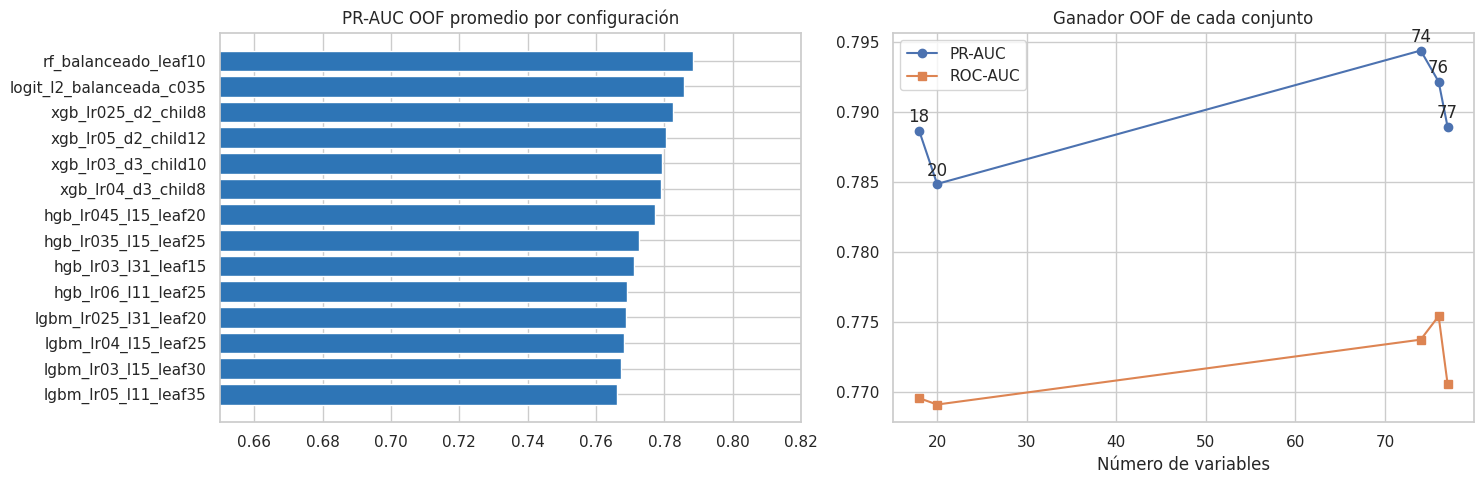

In [ ]:
feature_sets_75={
    '77_variables_conservadoras':FEATURES_77,
    '76_sin_pct_merma_viaje_base':[c for c in FEATURES_77 if c!='pct_merma_viaje_base'],
    '74_sin_merma_mortalidad_viaje_base':FEATURES_74,
    '20_seleccion_anidada_shap':FEATURES_20_BASE,
    '18_sin_redundancias_colineales':FEATURES_18_REPORTADAS,
}
candidate_models=list(dict.fromkeys(SCREEN_MODELS+TUNE_MODELS))
rows_75=[]
for set_name,features in feature_sets_75.items():
    for model_name in candidate_models:
        rows_75.append({'feature_set':set_name,'variables_n':len(features),'modelo':model_name,
                        **evaluate_configuration(features,1.70,model_name)})
modelos_75=pd.DataFrame(rows_75).sort_values(['feature_set','pr_auc','roc_auc','brier'],ascending=[True,False,False,True])
ganadores_75=(modelos_75[~modelos_75.modelo.eq('baseline_prevalencia_train')]
              .groupby('feature_set',as_index=False).head(1).sort_values('pr_auc',ascending=False))
print('Evaluaciones adicionales:',len(modelos_75))
display(modelos_75)
display(ganadores_75)
resumen_por_modelo=(modelos_75[~modelos_75.modelo.eq('baseline_prevalencia_train')]
                    .groupby('modelo',as_index=False).agg(pr_auc_promedio=('pr_auc','mean'),
                                                         pr_auc_max=('pr_auc','max'),
                                                         roc_auc_promedio=('roc_auc','mean'),
                                                         brier_promedio=('brier','mean'))
                    .sort_values('pr_auc_promedio',ascending=False))
display(resumen_por_modelo)
fig,axes=plt.subplots(1,2,figsize=(15,5))
axes[0].barh(resumen_por_modelo.modelo[::-1],resumen_por_modelo.pr_auc_promedio[::-1],color='#2E75B6')
axes[0].set_xlim(.65,.82); axes[0].set_title('PR-AUC OOF promedio por configuración')
ordered=ganadores_75.sort_values('variables_n')
axes[1].plot(ordered.variables_n,ordered.pr_auc,'o-',label='PR-AUC'); axes[1].plot(ordered.variables_n,ordered.roc_auc,'s-',label='ROC-AUC')
for row in ordered.itertuples(): axes[1].annotate(str(row.variables_n),(row.variables_n,row.pr_auc),xytext=(0,6),textcoords='offset points',ha='center')
axes[1].set_xlabel('Número de variables'); axes[1].set_title('Ganador OOF de cada conjunto'); axes[1].legend()
plt.tight_layout(); plt.savefig(OUT/'comparacion_modelos_y_feature_sets.png',dpi=180,bbox_inches='tight'); plt.show()
modelos_75.to_csv(OUT/'modelos_75_feature_sets_cv_oof.csv',index=False)
ganadores_75.to_csv(OUT/'ganador_por_feature_set.csv',index=False)


## 12. VERIFICACIÓN DE BALANCEO


,metodo,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10,...,r95_precision,r95_recall,r95_f1,r95_alertas_pct,r95_specificity,r95_npv,r95_tn,r95_fp,r95_fn,r95_tp
6,smote_estandar,1146,609,0.531414,0.790653,0.770610,0.195233,0.573775,0.541076,0.031587,...,0.586626,0.950739,0.725564,0.861257,0.240223,0.811321,129,408,30,579
5,random_oversampling,1146,609,0.531414,0.785775,0.768913,0.195470,0.574666,0.544230,0.030885,...,0.583669,0.950739,0.723298,0.865620,0.230912,0.805195,124,413,30,579
0,sin_balanceo,1146,609,0.531414,0.791993,0.772090,0.202435,0.589268,0.612988,0.086058,...,0.582495,0.950739,0.722396,0.867365,0.227188,0.802632,122,415,30,579
1,balanced_subsample,1146,609,0.531414,0.788135,0.768708,0.196202,0.575921,0.551017,0.030292,...,0.581910,0.950739,0.721945,0.868237,0.225326,0.801325,121,416,30,579
2,costo_fn_2x,1146,609,0.531414,0.793338,0.772534,0.228060,0.650135,0.702796,0.171382,...,0.581325,0.950739,0.721495,0.869110,0.223464,0.800000,120,417,30,579
3,costo_fn_5x,1146,609,0.531414,0.789866,0.769060,0.280204,0.800306,0.802467,0.271284,...,0.577268,0.950739,0.718362,0.875218,0.210428,0.790210,113,424,30,579
4,costo_fn_10x,1146,609,0.531414,0.787966,0.766262,0.322442,0.960811,0.860241,0.328827,...,0.571006,0.950739,0.713494,0.884817,0.189944,0.772727,102,435,30,579


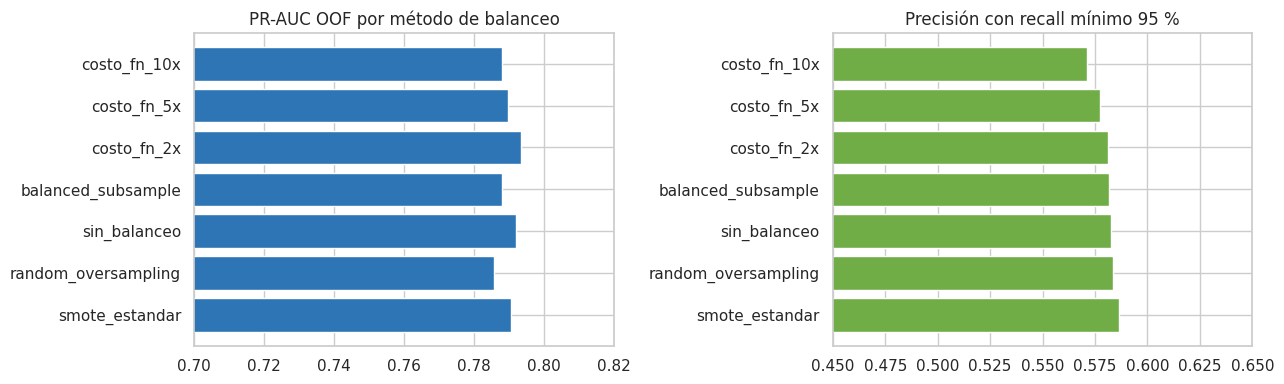

Balanceo elegido sin mirar test: sin_balanceo
Nota: SMOTE sobremuestrea la clase normal, que es la minoritaria en train.


In [ ]:
def evaluate_oof_rf(features,method):
    y=train_all[TARGET_CLASS].to_numpy(); oof=np.full(len(y),np.nan)
    for _,fit_idx,valid_idx in folds:
        Xf,Xv,_,_=fit_transform_fold(train_all.iloc[fit_idx][features],train_all.iloc[valid_idx][features])
        y_fit=y[fit_idx]; class_weight=None
        if method=='balanced_subsample': class_weight='balanced_subsample'
        if method=='costo_fn_2x': class_weight={0:1,1:2}
        if method=='costo_fn_5x': class_weight={0:1,1:5}
        if method=='costo_fn_10x': class_weight={0:1,1:10}
        if method=='random_oversampling': Xf,y_fit=RandomOverSampler(random_state=RANDOM_STATE).fit_resample(Xf,y_fit)
        if method=='smote_estandar':
            minority=min(np.bincount(y_fit)); k=max(1,min(5,minority-1))
            Xf,y_fit=SMOTE(random_state=RANDOM_STATE,k_neighbors=k).fit_resample(Xf,y_fit)
        model=RandomForestClassifier(n_estimators=TREES_CV,min_samples_leaf=10,max_features='sqrt',
                                     class_weight=class_weight,random_state=RANDOM_STATE,n_jobs=-1)
        model.fit(Xf,y_fit); oof[valid_idx]=model.predict_proba(Xv)[:,1]
    mask=~np.isnan(oof); return y[mask],oof[mask]

balance_methods=['sin_balanceo','balanced_subsample','costo_fn_2x','costo_fn_5x','costo_fn_10x','random_oversampling','smote_estandar']
balance_rows=[]
for method in balance_methods:
    y,p=evaluate_oof_rf(FEATURES_FINAL,method); t=threshold_for_recall(y,p,.95)
    balance_rows.append({'metodo':method,**probability_metrics(y,p),'threshold_r95':t,
                         **{f'r95_{k}':v for k,v in threshold_metrics(y,p,t).items()}})
balance=pd.DataFrame(balance_rows).sort_values(['r95_precision','pr_auc','brier'],ascending=[False,False,True])
display(balance)
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].barh(balance.metodo,balance.pr_auc,color='#2E75B6'); axes[0].set_title('PR-AUC OOF por método de balanceo'); axes[0].set_xlim(.70,.82)
axes[1].barh(balance.metodo,balance.r95_precision,color='#70AD47'); axes[1].set_title('Precisión con recall mínimo 95 %'); axes[1].set_xlim(.45,.65)
plt.tight_layout(); plt.savefig(OUT/'comparacion_balanceo.png',dpi=170,bbox_inches='tight'); plt.show()
balance.to_csv(OUT/'balanceo_cv_oof.csv',index=False)

# Selección formal: precisión a recall 95 %, PR-AUC y preferencia por simplicidad.
best_precision=float(balance.r95_precision.max())
eligible=balance[balance.r95_precision>=best_precision-.005].copy()
best_pr=float(eligible.pr_auc.max())
eligible=eligible[eligible.pr_auc>=best_pr-.002].copy()
preference={'sin_balanceo':0,'balanced_subsample':1,'costo_fn_2x':2,'costo_fn_5x':3,
            'costo_fn_10x':4,'random_oversampling':5,'smote_estandar':6}
eligible['preferencia_metodologica']=eligible.metodo.map(preference)
BALANCE_FINAL=eligible.sort_values(['preferencia_metodologica','brier']).iloc[0].metodo
print('Balanceo elegido sin mirar test:',BALANCE_FINAL)
print('Nota: SMOTE sobremuestrea la clase normal, que es la minoritaria en train.')


## 13. ESTANDARIZACIÓN DE LAS 18 VARIABLES: comparación temporal

La estandarización se prueba como análisis de sensibilidad después de seleccionar las 18 variables y el método de balanceo. En cada fold, el `StandardScaler` se ajusta solo con el train correspondiente y se aplica después al bloque de validación, evitando fuga de información temporal.

La comparación mantiene constantes variables, folds, imputación, tratamiento de outliers, balanceo, hiperparámetros y semilla. Por tanto, la única diferencia evaluada es usar o no estandarización.


,escenario,variables_n,balanceo,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,...,r95_fp,r95_fn,r95_tp,delta_pr_auc_vs_sin,delta_roc_auc_vs_sin,delta_brier_vs_sin,delta_log_loss_vs_sin,delta_ece_10_vs_sin,delta_r95_precision_vs_sin,delta_r95_recall_vs_sin
0,sin_estandarizacion,18,sin_balanceo,1146,609,0.531414,0.791993,0.772090,0.202435,0.589268,...,415,30,579,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,con_estandarizacion,18,sin_balanceo,1146,609,0.531414,0.791998,0.772148,0.202415,0.589235,...,415,30,579,0.000005,0.000058,-0.000021,-0.000033,-0.000023,0.0,0.0


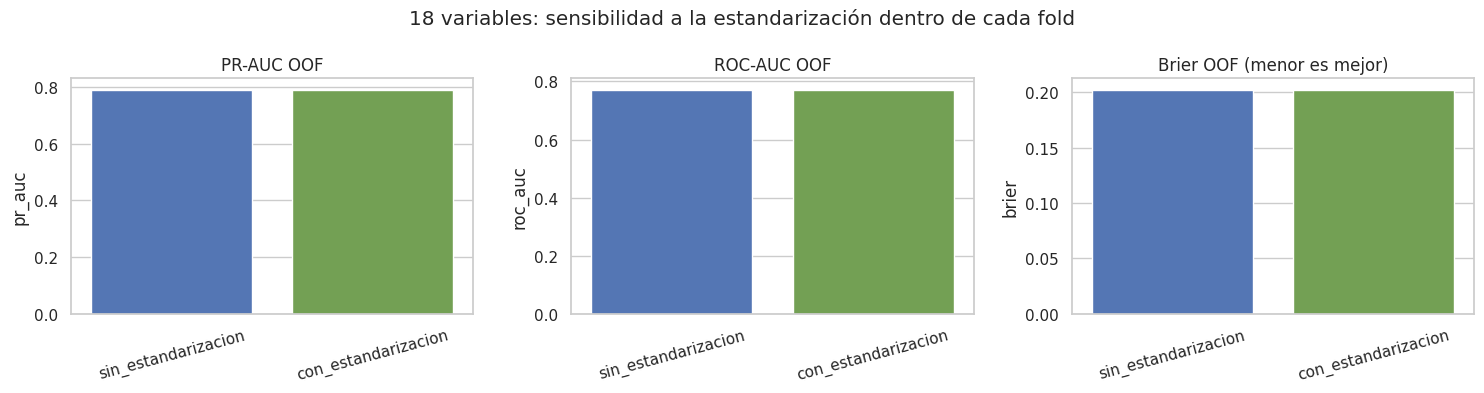

Decisión metodológica: la estandarización se reporta como sensibilidad; no se elige mirando el test.


In [ ]:
def apply_selected_balance(X, y, method):
    X_res, y_res, class_weight = X, y, None
    if method == 'balanced_subsample': class_weight = 'balanced_subsample'
    if method == 'costo_fn_2x': class_weight = {0:1, 1:2}
    if method == 'costo_fn_5x': class_weight = {0:1, 1:5}
    if method == 'costo_fn_10x': class_weight = {0:1, 1:10}
    if method == 'random_oversampling':
        X_res, y_res = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X, y)
    if method == 'smote_estandar':
        minority = min(np.bincount(y)); k = max(1, min(5, minority-1))
        X_res, y_res = SMOTE(random_state=RANDOM_STATE, k_neighbors=k).fit_resample(X, y)
    return X_res, y_res, class_weight

def evaluate_oof_standardization(standardize):
    y = train_all[TARGET_CLASS].to_numpy()
    oof = np.full(len(y), np.nan)
    for _, fit_idx, valid_idx in folds:
        X_fit, X_valid, _, _ = fit_transform_fold(
            train_all.iloc[fit_idx][FEATURES_FINAL],
            train_all.iloc[valid_idx][FEATURES_FINAL],
        )
        if standardize:
            scaler = StandardScaler().fit(X_fit)
            X_fit = scaler.transform(X_fit)
            X_valid = scaler.transform(X_valid)
        X_fit, y_fit, class_weight = apply_selected_balance(X_fit, y[fit_idx], BALANCE_FINAL)
        model = RandomForestClassifier(
            n_estimators=TREES_CV, min_samples_leaf=10, max_features='sqrt',
            class_weight=class_weight, random_state=RANDOM_STATE, n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]
    mask = ~np.isnan(oof)
    return y[mask], oof[mask]

standardization_rows = []
standardization_oof_prob = {}
for label, standardize in [('sin_estandarizacion', False), ('con_estandarizacion', True)]:
    y_std, p_std = evaluate_oof_standardization(standardize)
    standardization_oof_prob[label] = p_std
    threshold_std = threshold_for_recall(y_std, p_std, .95)
    standardization_rows.append({
        'escenario': label,
        'variables_n': len(FEATURES_FINAL),
        'balanceo': BALANCE_FINAL,
        **probability_metrics(y_std, p_std),
        'threshold_r95': threshold_std,
        **{f'r95_{key}': value for key, value in threshold_metrics(y_std, p_std, threshold_std).items()},
    })

standardization_oof = pd.DataFrame(standardization_rows)
base_oof = standardization_oof.loc[standardization_oof.escenario.eq('sin_estandarizacion')].iloc[0]
for metric in ['pr_auc', 'roc_auc', 'brier', 'log_loss', 'ece_10', 'r95_precision', 'r95_recall']:
    standardization_oof[f'delta_{metric}_vs_sin'] = standardization_oof[metric] - base_oof[metric]

display(standardization_oof)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=standardization_oof, x='escenario', y='pr_auc', ax=axes[0], palette=['#4472C4','#70AD47'])
sns.barplot(data=standardization_oof, x='escenario', y='roc_auc', ax=axes[1], palette=['#4472C4','#70AD47'])
sns.barplot(data=standardization_oof, x='escenario', y='brier', ax=axes[2], palette=['#4472C4','#70AD47'])
axes[0].set_title('PR-AUC OOF'); axes[1].set_title('ROC-AUC OOF'); axes[2].set_title('Brier OOF (menor es mejor)')
for ax in axes:
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
plt.suptitle('18 variables: sensibilidad a la estandarización dentro de cada fold')
plt.tight_layout(); plt.savefig(OUT/'comparacion_estandarizacion_oof.png', dpi=180, bbox_inches='tight'); plt.show()
standardization_oof.to_csv(OUT/'comparacion_estandarizacion_oof.csv', index=False)

print('Decisión metodológica: la estandarización se reporta como sensibilidad; no se elige mirando el test.')


## 14. Aplicación final, calibración y selección temporal de la política

La política final `costo_fn_20x` minimiza `FP + 20 x FN` en `policy_validation`. El test de sensibilidad recibe el umbral ya fijado y no participa en su selección.


In [ ]:
dates=np.asarray(sorted(train_all[date_col].dropna().unique()))
calibration_start=pd.Timestamp(dates[int(len(dates)*.70)])
policy_start=pd.Timestamp(dates[int(len(dates)*.85)])
model_limit=calibration_start-pd.Timedelta(days=EMBARGO_DAYS)

model_fit=train_all[train_all[date_col]<model_limit].copy()
calibration_fit=train_all[(train_all[date_col]>=calibration_start)&(train_all[date_col]<policy_start)].copy()
policy_validation=train_all[train_all[date_col]>=policy_start].copy()
parts=pd.DataFrame([
    {'parte':'model_fit','inicio':model_fit[date_col].min(),'fin':model_fit[date_col].max(),'n':len(model_fit),'prevalencia':model_fit[TARGET_CLASS].mean()},
    {'parte':'calibration_fit','inicio':calibration_fit[date_col].min(),'fin':calibration_fit[date_col].max(),'n':len(calibration_fit),'prevalencia':calibration_fit[TARGET_CLASS].mean()},
    {'parte':'policy_validation','inicio':policy_validation[date_col].min(),'fin':policy_validation[date_col].max(),'n':len(policy_validation),'prevalencia':policy_validation[TARGET_CLASS].mean()},
    {'parte':'test_sensibilidad','inicio':test_sensibilidad[date_col].min(),'fin':test_sensibilidad[date_col].max(),'n':len(test_sensibilidad),'prevalencia':test_sensibilidad[TARGET_CLASS].mean()},
])
display(parts); parts.to_csv(OUT/'particiones_temporales_finales.csv',index=False)

clipper=QuantileClipper().fit(model_fit[FEATURES_FINAL])
imputer=SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)
X_model=imputer.fit_transform(clipper.transform(model_fit[FEATURES_FINAL]))
def tx(frame): return imputer.transform(clipper.transform(frame[FEATURES_FINAL]))
y_model=model_fit[TARGET_CLASS].to_numpy(); X_model_res=X_model; y_model_res=y_model; class_weight=None
if BALANCE_FINAL=='balanced_subsample': class_weight='balanced_subsample'
if BALANCE_FINAL=='costo_fn_2x': class_weight={0:1,1:2}
if BALANCE_FINAL=='costo_fn_5x': class_weight={0:1,1:5}
if BALANCE_FINAL=='costo_fn_10x': class_weight={0:1,1:10}
if BALANCE_FINAL=='random_oversampling':
    X_model_res,y_model_res=RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_model,y_model)
if BALANCE_FINAL=='smote_estandar':
    minority=min(np.bincount(y_model)); k=max(1,min(5,minority-1))
    X_model_res,y_model_res=SMOTE(random_state=RANDOM_STATE,k_neighbors=k).fit_resample(X_model,y_model)
final_model=RandomForestClassifier(n_estimators=TREES_FINAL,min_samples_leaf=10,max_features='sqrt',
                                   class_weight=class_weight,random_state=RANDOM_STATE,n_jobs=-1)
final_model.fit(X_model_res,y_model_res)
raw_cal=final_model.predict_proba(tx(calibration_fit))[:,1]
raw_policy=final_model.predict_proba(tx(policy_validation))[:,1]
raw_test=final_model.predict_proba(tx(test_sensibilidad))[:,1]


# Variante paralela estandarizada para comparar el mismo modelo final de 18 variables.
final_scaler_std = StandardScaler().fit(X_model)
def tx_std(frame): return final_scaler_std.transform(tx(frame))

X_model_std = final_scaler_std.transform(X_model)
X_model_std_res, y_model_std_res, class_weight_std = apply_selected_balance(
    X_model_std, y_model, BALANCE_FINAL
)
final_model_std = RandomForestClassifier(
    n_estimators=TREES_FINAL, min_samples_leaf=10, max_features='sqrt',
    class_weight=class_weight_std, random_state=RANDOM_STATE, n_jobs=-1,
)
final_model_std.fit(X_model_std_res, y_model_std_res)
raw_cal_std = final_model_std.predict_proba(tx_std(calibration_fit))[:,1]
raw_policy_std = final_model_std.predict_proba(tx_std(policy_validation))[:,1]
raw_test_std = final_model_std.predict_proba(tx_std(test_sensibilidad))[:,1]


,parte,inicio,fin,n,prevalencia
0,model_fit,2023-01-02,2024-07-17,1113,0.571429
1,calibration_fit,2024-07-25,2024-12-13,241,0.697095
2,policy_validation,2024-12-14,2025-04-19,257,0.416342
3,test_sensibilidad,2025-04-20,2025-10-05,404,0.207921


,metodo,subconjunto,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
0,raw,policy_validation,257,107,0.416342,0.707100,0.784486,0.226322,0.648218,0.612317,0.198662
1,raw,test_sensibilidad,404,84,0.207921,0.555500,0.815885,0.266127,0.742251,0.571292,0.363371
2,sigmoid,policy_validation,257,107,0.416342,0.707100,0.784486,0.250566,0.709412,0.664836,0.248493
3,sigmoid,test_sensibilidad,404,84,0.207921,0.555500,0.815885,0.308267,0.850503,0.623626,0.415705
4,isotonic,policy_validation,257,107,0.416342,0.659712,0.770717,0.255819,0.741124,0.650796,0.239806
5,isotonic,test_sensibilidad,404,84,0.207921,0.488075,0.791202,0.308426,0.927279,0.600171,0.392250


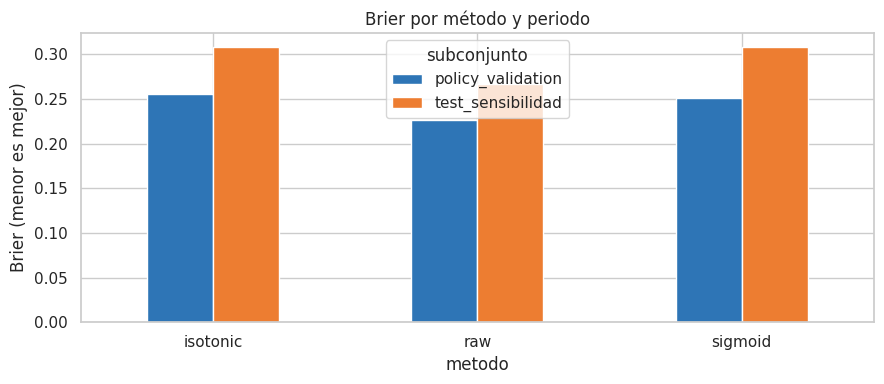

Calibración elegida solo en policy_validation: raw


In [ ]:
class ProbabilityCalibrator:
    def __init__(self,method): self.method=method; self.model=None
    def _logit(self,p):
        p=np.clip(np.asarray(p),1e-6,1-1e-6); return np.log(p/(1-p)).reshape(-1,1)
    def fit(self,p,y):
        if self.method=='sigmoid': self.model=LogisticRegression(max_iter=2000,random_state=RANDOM_STATE).fit(self._logit(p),y)
        elif self.method=='isotonic': self.model=IsotonicRegression(out_of_bounds='clip').fit(p,y)
        return self
    def predict(self,p):
        if self.method=='raw': return np.asarray(p)
        if self.method=='sigmoid': return self.model.predict_proba(self._logit(p))[:,1]
        return self.model.predict(p)

calibrators={m:ProbabilityCalibrator(m).fit(raw_cal,calibration_fit[TARGET_CLASS].to_numpy()) for m in ['raw','sigmoid','isotonic']}
calibration_rows=[]; probabilities={}
for method,calibrator in calibrators.items():
    probabilities[method]={'policy':calibrator.predict(raw_policy),'test':calibrator.predict(raw_test)}
    calibration_rows += [
        {'metodo':method,'subconjunto':'policy_validation',**probability_metrics(policy_validation[TARGET_CLASS].to_numpy(),probabilities[method]['policy'])},
        {'metodo':method,'subconjunto':'test_sensibilidad',**probability_metrics(test_sensibilidad[TARGET_CLASS].to_numpy(),probabilities[method]['test'])},
    ]
calibration=pd.DataFrame(calibration_rows)
display(calibration)
cal_plot=calibration.pivot(index='metodo',columns='subconjunto',values='brier')
cal_plot.plot(kind='bar',figsize=(9,4),color=['#2E75B6','#ED7D31'])
plt.title('Brier por método y periodo'); plt.ylabel('Brier (menor es mejor)'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(OUT/'grafico_calibracion_metodos.png',dpi=170,bbox_inches='tight'); plt.show()
selected_calibration=calibration[calibration.subconjunto.eq('policy_validation')].sort_values(['brier','ece_10']).iloc[0].metodo
print('Calibración elegida solo en policy_validation:',selected_calibration)
calibration.to_csv(OUT/'calibracion_temporal.csv',index=False)
p_policy=probabilities[selected_calibration]['policy']; p_test=probabilities[selected_calibration]['test']
y_policy=policy_validation[TARGET_CLASS].to_numpy(); y_test=test_sensibilidad[TARGET_CLASS].to_numpy()


# Calibración independiente de la variante estandarizada, elegida solo con policy_validation.
calibrators_std = {
    method: ProbabilityCalibrator(method).fit(raw_cal_std, calibration_fit[TARGET_CLASS].to_numpy())
    for method in ['raw', 'sigmoid', 'isotonic']
}
calibration_std_rows = []
probabilities_std = {}
for method, calibrator_std in calibrators_std.items():
    probabilities_std[method] = {
        'policy': calibrator_std.predict(raw_policy_std),
        'test': calibrator_std.predict(raw_test_std),
    }
    calibration_std_rows.append({
        'metodo': method,
        'subconjunto': 'policy_validation',
        **probability_metrics(y_policy, probabilities_std[method]['policy']),
    })
calibration_std = pd.DataFrame(calibration_std_rows)
selected_calibration_std = calibration_std.sort_values(['brier','ece_10']).iloc[0].metodo
p_policy_std = probabilities_std[selected_calibration_std]['policy']
p_test_std = probabilities_std[selected_calibration_std]['test']

standardization_test = pd.DataFrame([
    {
        'escenario': 'sin_estandarizacion',
        'calibracion': selected_calibration,
        **probability_metrics(y_test, p_test),
    },
    {
        'escenario': 'con_estandarizacion',
        'calibracion': selected_calibration_std,
        **probability_metrics(y_test, p_test_std),
    },
])
base_test_std = standardization_test.loc[standardization_test.escenario.eq('sin_estandarizacion')].iloc[0]
for metric in ['pr_auc','roc_auc','brier','log_loss','ece_10']:
    standardization_test[f'delta_{metric}_vs_sin'] = standardization_test[metric] - base_test_std[metric]
standardization_test.to_csv(OUT/'comparacion_estandarizacion_test_sensibilidad.csv', index=False)


,subconjunto,politica,threshold,precision,recall,f1,alertas_pct,specificity,npv,tn,fp,fn,tp
0,policy_validation,recall_min_95,0.423122,0.495146,0.953271,0.651757,0.801556,0.306667,0.901961,46,104,5,102
1,test_sensibilidad,recall_min_95,0.423122,0.287234,0.964286,0.442623,0.698020,0.371875,0.975410,119,201,3,81
2,policy_validation,recall_min_90,0.491079,0.532967,0.906542,0.671280,0.708171,0.433333,0.866667,65,85,10,97
3,test_sensibilidad,recall_min_90,0.491079,0.320988,0.928571,0.477064,0.601485,0.484375,0.962733,155,165,6,78
4,policy_validation,costo_fn_5x,0.407866,0.495238,0.971963,0.656151,0.817121,0.293333,0.936170,44,106,3,104
5,test_sensibilidad,costo_fn_5x,0.407866,0.274576,0.964286,0.427441,0.730198,0.331250,0.972477,106,214,3,81
6,policy_validation,costo_fn_10x,0.312765,0.453390,1.000000,0.623907,0.918288,0.140000,1.000000,21,129,0,107
7,test_sensibilidad,costo_fn_10x,0.312765,0.240000,1.000000,0.387097,0.866337,0.168750,1.000000,54,266,0,84
8,policy_validation,costo_fn_20x,0.312765,0.453390,1.000000,0.623907,0.918288,0.140000,1.000000,21,129,0,107
9,test_sensibilidad,costo_fn_20x,0.312765,0.240000,1.000000,0.387097,0.866337,0.168750,1.000000,54,266,0,84


,estado,subconjunto,politica,threshold,precision,recall,f1,alertas_pct,specificity,npv,tn,fp,fn,tp
8,POLITICA_FINAL_VIGENTE,policy_validation,costo_fn_20x,0.312765,0.45339,1.0,0.623907,0.918288,0.14000,1.0,21,129,0,107
9,POLITICA_FINAL_VIGENTE,test_sensibilidad,costo_fn_20x,0.312765,0.24000,1.0,0.387097,0.866337,0.16875,1.0,54,266,0,84


Política final: costo_fn_20x | umbral aprendido en policy_validation: 0.312765


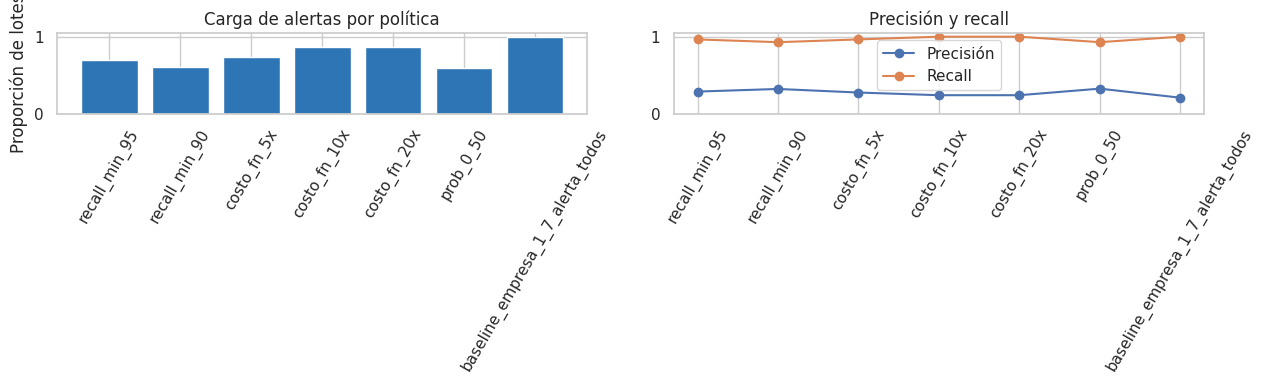

In [ ]:
def threshold_min_cost(y,p,fn_cost):
    candidates=np.unique(np.r_[0,p,1]); rows=[]
    for t in candidates:
        tn,fp,fn,tp=confusion_matrix(y,p>=t,labels=[0,1]).ravel(); rows.append((fp+fn_cost*fn,-t,t))
    return min(rows)[2]

thresholds={
    'recall_min_95':threshold_for_recall(y_policy,p_policy,.95),
    'recall_min_90':threshold_for_recall(y_policy,p_policy,.90),
    'costo_fn_5x':threshold_min_cost(y_policy,p_policy,5),
    'costo_fn_10x':threshold_min_cost(y_policy,p_policy,10),
    'costo_fn_20x':threshold_min_cost(y_policy,p_policy,20),
    'prob_0_50':.50,
}
POLITICA_FINAL = 'costo_fn_20x'
UMBRAL_FINAL = float(thresholds[POLITICA_FINAL])
policy_rows=[]
for name,t in thresholds.items():
    policy_rows += [
        {'subconjunto':'policy_validation','politica':name,'threshold':t,**threshold_metrics(y_policy,p_policy,t)},
        {'subconjunto':'test_sensibilidad','politica':name,'threshold':t,**threshold_metrics(y_test,p_test,t)},
    ]
baseline={'subconjunto':'test_sensibilidad','politica':'baseline_empresa_1_7_alerta_todos','threshold':np.nan,
          **threshold_metrics(y_test,np.ones_like(y_test,float),.5)}
policy_rows.append(baseline)
policies=pd.DataFrame(policy_rows)
display(policies)

politica_final = policies[policies.politica.eq(POLITICA_FINAL)].copy()
politica_final.insert(0, 'estado', 'POLITICA_FINAL_VIGENTE')
display(politica_final)
politica_final.to_csv(OUT/'politica_final_costo_fn_20x.csv', index=False)
politica_final.to_excel(OUT/'politica_final_costo_fn_20x.xlsx', index=False)
print('Política final:', POLITICA_FINAL, '| umbral aprendido en policy_validation:', f'{UMBRAL_FINAL:.6f}')

policy_plot=policies[policies.subconjunto.eq('test_sensibilidad')].copy()
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].bar(policy_plot.politica,policy_plot.alertas_pct,color='#2E75B6'); axes[0].set_title('Carga de alertas por política'); axes[0].set_ylabel('Proporción de lotes'); axes[0].tick_params(axis='x',rotation=60)
axes[1].plot(policy_plot.politica,policy_plot.precision,'o-',label='Precisión'); axes[1].plot(policy_plot.politica,policy_plot.recall,'o-',label='Recall'); axes[1].set_ylim(0,1.05); axes[1].legend(); axes[1].set_title('Precisión y recall'); axes[1].tick_params(axis='x',rotation=60)
plt.tight_layout(); plt.savefig(OUT/'grafico_politicas_umbral.png',dpi=170,bbox_inches='tight'); plt.show()
policies.to_csv(OUT/'politicas_umbral_y_baseline.csv',index=False)


## 15. EVALUACIÓN DE PERFORMANCE Y MATRICES DE CONFUSIÓN


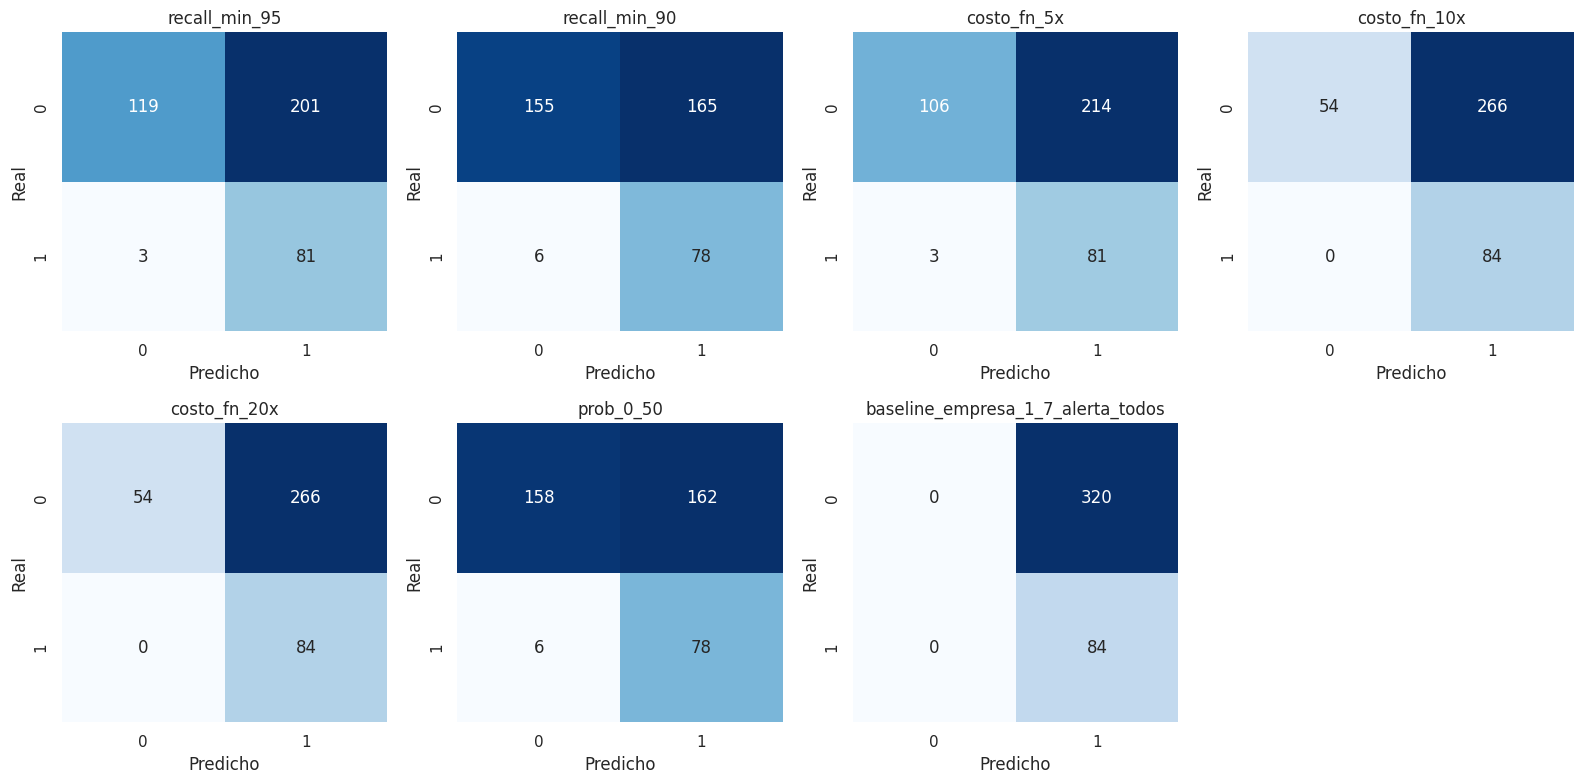

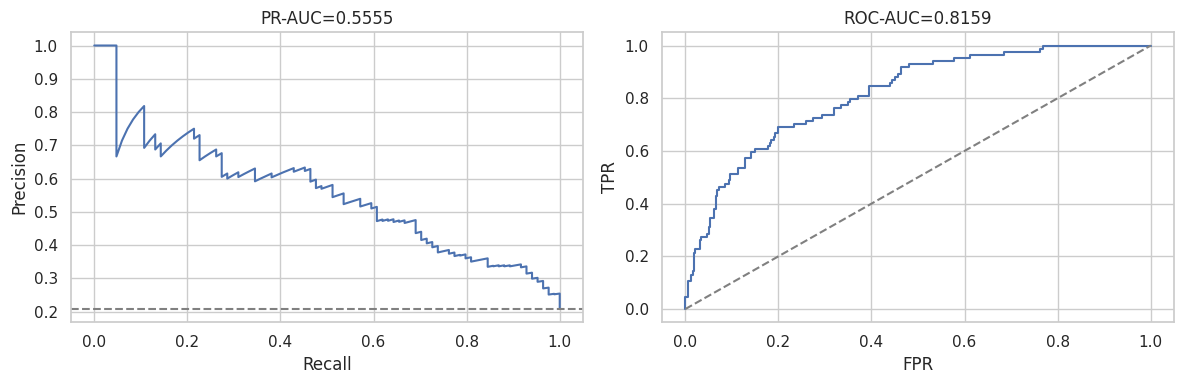

,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,ece_10
0,404,84,0.207921,0.5555,0.815885,0.266127,0.742251,0.571292,0.363371


,escenario,calibracion,n,positivos,prevalencia,pr_auc,roc_auc,brier,log_loss,prob_media,...,precision,recall,f1,alertas_pct,specificity,npv,tn,fp,fn,tp
0,sin_estandarizacion,raw,404,84,0.207921,0.55550,0.815885,0.266127,0.742251,0.571292,...,0.287234,0.964286,0.442623,0.69802,0.371875,0.97541,119,201,3,81
1,con_estandarizacion,raw,404,84,0.207921,0.55491,0.815774,0.266157,0.742361,0.571295,...,0.287234,0.964286,0.442623,0.69802,0.371875,0.97541,119,201,3,81


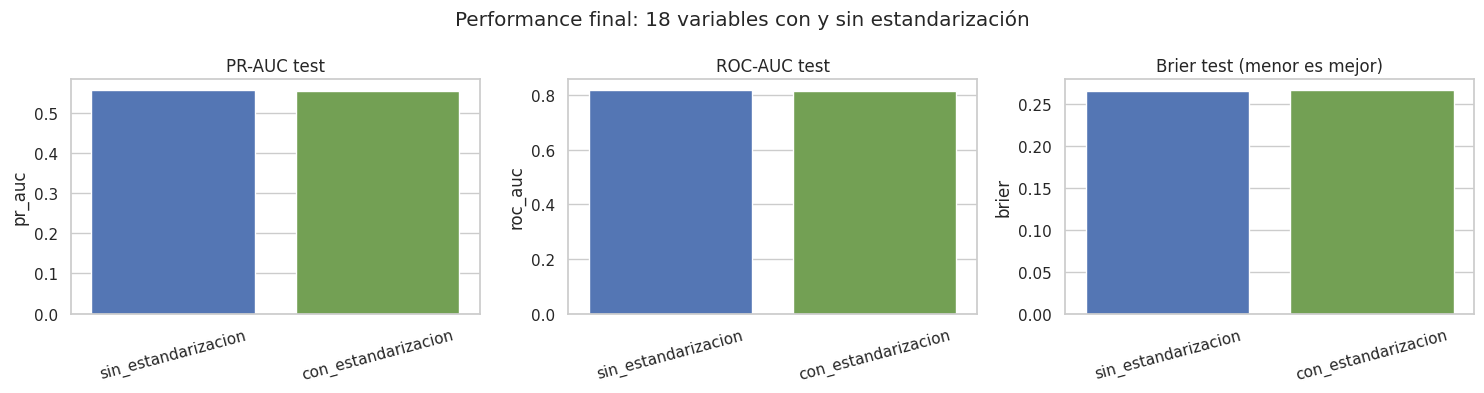

,periodo_evaluacion,escenario,variables_n,balanceo,calibracion,origen_umbral,pr_auc,roc_auc,brier,log_loss,ece_10,threshold_r95,precision,recall,specificity,npv,f1,alertas_pct,tn,fp,fn,tp,delta_pr_auc_vs_sin,delta_roc_auc_vs_sin,delta_brier_vs_sin,delta_log_loss_vs_sin,delta_ece_10_vs_sin
0,validacion_temporal_oof,sin_estandarizacion,18,sin_balanceo,no_aplica,predicciones_oof,0.7920,0.7721,0.2024,0.5893,0.0861,0.3675,0.5825,0.9507,0.2272,0.8026,0.7224,0.8674,122,415,30,579,0.0000,0.0000,0.0000,0.0000,0.0000
1,validacion_temporal_oof,con_estandarizacion,18,sin_balanceo,no_aplica,predicciones_oof,0.7920,0.7721,0.2024,0.5892,0.0860,0.3675,0.5825,0.9507,0.2272,0.8026,0.7224,0.8674,122,415,30,579,0.0000,0.0001,-0.0000,-0.0000,-0.0000
2,test_sensibilidad_desde_2025_04_20,sin_estandarizacion,18,sin_balanceo,raw,policy_validation,0.5555,0.8159,0.2661,0.7423,0.3634,0.4231,0.2872,0.9643,0.3719,0.9754,0.4426,0.6980,119,201,3,81,0.0000,0.0000,0.0000,0.0000,0.0000
3,test_sensibilidad_desde_2025_04_20,con_estandarizacion,18,sin_balanceo,raw,policy_validation,0.5549,0.8158,0.2662,0.7424,0.3634,0.4231,0.2872,0.9643,0.3719,0.9754,0.4426,0.6980,119,201,3,81,-0.0006,-0.0001,0.0000,0.0001,0.0000


Tabla final guardada en CSV y Excel dentro de: /content/drive/MyDrive/salidas_clasificacion_v1_12_sesgo_equidad_23_08_26


In [ ]:
test_rows=policies[policies.subconjunto.eq('test_sensibilidad')]
fig,axes=plt.subplots(2,4,figsize=(16,8)); axes=axes.flatten()
for ax,(_,row) in zip(axes,test_rows.iterrows()):
    cm=np.array([[row.tn,row.fp],[row.fn,row.tp]])
    sns.heatmap(cm,annot=True,fmt='.0f',cbar=False,cmap='Blues',ax=ax)
    ax.set_title(row.politica); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
for ax in axes[len(test_rows):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(OUT/'matrices_confusion_politicas.png',dpi=170); plt.show()

precision,recall,_=precision_recall_curve(y_test,p_test); fpr,tpr,_=roc_curve(y_test,p_test)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(recall,precision); axes[0].axhline(y_test.mean(),ls='--',color='gray')
axes[0].set(title=f'PR-AUC={average_precision_score(y_test,p_test):.4f}',xlabel='Recall',ylabel='Precision')
axes[1].plot(fpr,tpr); axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(title=f'ROC-AUC={roc_auc_score(y_test,p_test):.4f}',xlabel='FPR',ylabel='TPR')
plt.tight_layout(); plt.savefig(OUT/'curvas_pr_roc_test.png',dpi=170); plt.show()

test_probability=probability_metrics(y_test,p_test)
display(pd.DataFrame([test_probability]))


standardization_operational_rows = []
for label, p_policy_scenario, p_test_scenario in [
    ('sin_estandarizacion', p_policy, p_test),
    ('con_estandarizacion', p_policy_std, p_test_std),
]:
    threshold_scenario = threshold_for_recall(y_policy, p_policy_scenario, .95)
    standardization_operational_rows.append({
        'escenario': label,
        'threshold_r95': threshold_scenario,
        **threshold_metrics(y_test, p_test_scenario, threshold_scenario),
    })
standardization_operational = pd.DataFrame(standardization_operational_rows)
standardization_test = standardization_test.merge(
    standardization_operational, on='escenario', how='left', validate='one_to_one'
)
standardization_test.to_csv(OUT/'comparacion_estandarizacion_test_sensibilidad.csv', index=False)

display(standardization_test)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=standardization_test, x='escenario', y='pr_auc', ax=axes[0], palette=['#4472C4','#70AD47'])
sns.barplot(data=standardization_test, x='escenario', y='roc_auc', ax=axes[1], palette=['#4472C4','#70AD47'])
sns.barplot(data=standardization_test, x='escenario', y='brier', ax=axes[2], palette=['#4472C4','#70AD47'])
axes[0].set_title('PR-AUC test'); axes[1].set_title('ROC-AUC test'); axes[2].set_title('Brier test (menor es mejor)')
for ax in axes:
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Performance final: 18 variables con y sin estandarización')
plt.tight_layout(); plt.savefig(OUT/'comparacion_estandarizacion_test_sensibilidad.png', dpi=180, bbox_inches='tight'); plt.show()

# Tabla consolidada de resultados. Une la evidencia OOF y el
# test de sensibilidad sin utilizar el test para escoger estandarización,
# calibración ni umbral. En OOF, el prefijo r95_ identifica el umbral estimado
# sobre las predicciones fuera de fold; en test, el umbral proviene de
# policy_validation y se aplica una sola vez al periodo de sensibilidad.
oof_final = standardization_oof.rename(columns={
    'r95_precision': 'precision',
    'r95_recall': 'recall',
    'r95_specificity': 'specificity',
    'r95_f1': 'f1',
    'r95_alertas_pct': 'alertas_pct',
    'r95_npv': 'npv',
    'r95_tn': 'tn',
    'r95_fp': 'fp',
    'r95_fn': 'fn',
    'r95_tp': 'tp',
}).copy()
oof_final['periodo_evaluacion'] = 'validacion_temporal_oof'
oof_final['calibracion'] = 'no_aplica'
oof_final['origen_umbral'] = 'predicciones_oof'

test_final = standardization_test.copy()
test_final['periodo_evaluacion'] = 'test_sensibilidad_desde_2025_04_20'
test_final['variables_n'] = len(FEATURES_FINAL)
test_final['balanceo'] = BALANCE_FINAL
test_final['origen_umbral'] = 'policy_validation'

tabla_final_columnas = [
    'periodo_evaluacion', 'escenario', 'variables_n', 'balanceo',
    'calibracion', 'origen_umbral',
    'pr_auc', 'roc_auc', 'brier', 'log_loss', 'ece_10',
    'threshold_r95', 'precision', 'recall', 'specificity', 'npv', 'f1',
    'alertas_pct', 'tn', 'fp', 'fn', 'tp',
    'delta_pr_auc_vs_sin', 'delta_roc_auc_vs_sin',
    'delta_brier_vs_sin', 'delta_log_loss_vs_sin', 'delta_ece_10_vs_sin',
]
tabla_final_resultados = pd.concat(
    [oof_final.reindex(columns=tabla_final_columnas),
     test_final.reindex(columns=tabla_final_columnas)],
    ignore_index=True,
)

display(
    tabla_final_resultados.style
    .format({
        column: '{:.4f}' for column in [
            'pr_auc', 'roc_auc', 'brier', 'log_loss', 'ece_10',
            'threshold_r95', 'precision', 'recall', 'specificity', 'npv', 'f1',
            'alertas_pct', 'delta_pr_auc_vs_sin', 'delta_roc_auc_vs_sin',
            'delta_brier_vs_sin', 'delta_log_loss_vs_sin', 'delta_ece_10_vs_sin',
        ]
    }, na_rep='—')
    .set_caption('Tabla final de resultados: 18 variables con y sin estandarización')
)
tabla_final_resultados.to_csv(OUT/'tabla_final_resultados_consolidada.csv', index=False)
tabla_final_resultados.to_excel(OUT/'tabla_final_resultados_consolidada.xlsx', index=False)
print('Tabla final guardada en CSV y Excel dentro de:', OUT)


In [ ]:

prev=y_test.mean(); eps=1e-15
mean_pos=p_test[y_test==1].mean(); mean_neg=p_test[y_test==0].mean()
ll_model=np.sum(y_test*np.log(np.clip(p_test,eps,1-eps))+(1-y_test)*np.log(np.clip(1-p_test,eps,1-eps)))
ll_null=np.sum(y_test*np.log(prev)+(1-y_test)*np.log(1-prev))
pseudo=pd.DataFrame([{
    'tjur':mean_pos-mean_neg,
    'prob_media_alta':mean_pos,
    'prob_media_normal':mean_neg,
    'efron':1-np.sum((y_test-p_test)**2)/np.sum((y_test-prev)**2),
    'mcfadden_predictivo':1-ll_model/ll_null,
    'somers_d':2*roc_auc_score(y_test,p_test)-1,
}])
display(pseudo)
pseudo.to_csv(OUT/'pseudo_r2_clasificacion.csv',index=False)
print('No interpretar Tjur como porcentaje de variabilidad de la merma continua.')


,tjur,prob_media_alta,prob_media_normal,efron,mcfadden_predictivo,somers_d
0,0.222408,0.747456,0.525048,-0.615931,-0.452009,0.631771


No interpretar Tjur como porcentaje de variabilidad de la merma continua.


## 16. SHAP FINAL DE 18 VARIABLES

Este bloque amplía la explicabilidad en dos niveles:

1. **Gobernanza global:** importancia, distribución, dirección, dependencia y patrones conjuntos de las variables.
2. **Gobernanza por lote:** principales contribuciones, sentido del efecto y gráficos waterfall para casos representativos.

SHAP explica el comportamiento del modelo; no demuestra causalidad. Las explicaciones se usan para priorizar revisión humana y documentar por qué un lote recibió determinado nivel de riesgo.

Para alertas, casos cercanos al umbral y expedientes se utiliza la política final `costo_fn_20x`. Los gráficos globales SHAP explican el mismo modelo y no dependen del umbral.


,variable_origen,mean_abs_shap,mean_shap,pct_contribucion_positiva
8,fe_cubicaje_x_duracion_viaje,0.044367,-0.024686,0.353960
14,kg_ingreso_cd_base,0.036655,0.007878,0.650990
1,ayuno_horas_hasta_hora_llena_mean,0.036350,0.002890,0.673267
17,tiempo_retorno_horas_max,0.035321,-0.017848,0.449257
9,fe_guia_dist_granja_cd_via_cruce_km_max,0.028731,-0.018036,0.512376
10,fe_kg_jaba_x_temp_transporte,0.024169,0.015086,0.527228
2,carga_jabas_por_guia_max,0.023039,0.012545,0.570545
7,clima_transporte_clima_viento_10m_kmh_mean,0.019603,0.003100,0.439356
11,fe_thi_ayuno_x_horas_ayuno,0.016511,0.012393,0.625000
5,clima_transporte_clima_radiacion_corta_wm2_mean,0.015989,0.010476,0.691832


,variable_origen,mean_abs_shap,mean_shap_positivo,mean_shap_negativo,pct_aumenta_riesgo,spearman_valor_vs_shap
1,fe_cubicaje_x_duracion_viaje,0.044334,0.009824,-0.034510,0.361386,-0.974683
2,kg_ingreso_cd_base,0.036655,0.022267,-0.014388,0.650990,-0.917885
0,ayuno_horas_hasta_hora_llena_mean,0.036248,0.019569,-0.016679,0.475248,-0.923378
5,tiempo_retorno_horas_max,0.035259,0.008705,-0.026554,0.297030,-0.836153
15,fe_guia_dist_granja_cd_via_cruce_km_max,0.028585,0.005275,-0.023311,0.358911,-0.724952
7,fe_kg_jaba_x_temp_transporte,0.024125,0.019605,-0.004519,0.549505,0.915717
9,carga_jabas_por_guia_max,0.022989,0.017767,-0.005222,0.641089,-0.953833
6,clima_transporte_clima_viento_10m_kmh_mean,0.019540,0.011320,-0.008220,0.507426,0.926313
4,fe_thi_ayuno_x_horas_ayuno,0.016320,0.014356,-0.001963,0.940594,-0.421108
12,clima_transporte_clima_radiacion_corta_wm2_mean,0.015940,0.013208,-0.002732,0.727723,0.843298


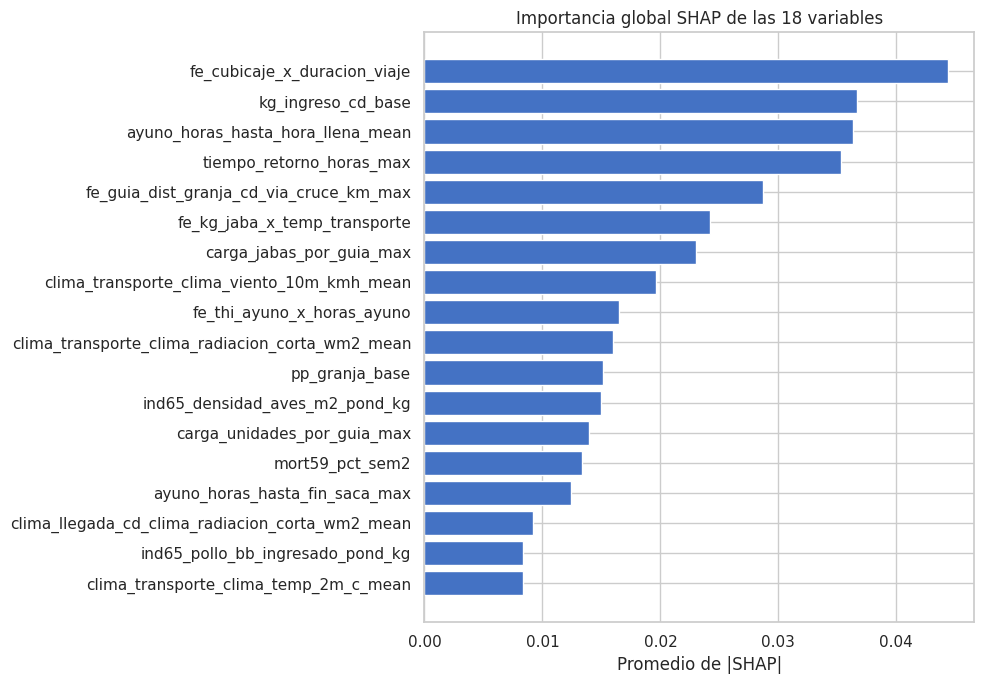

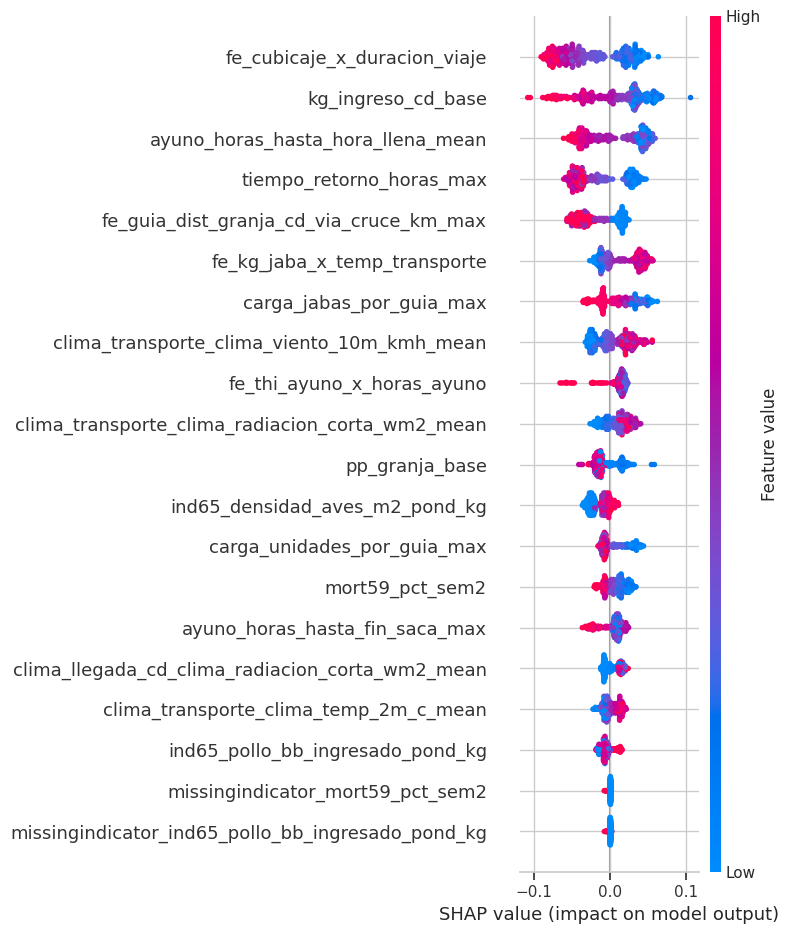

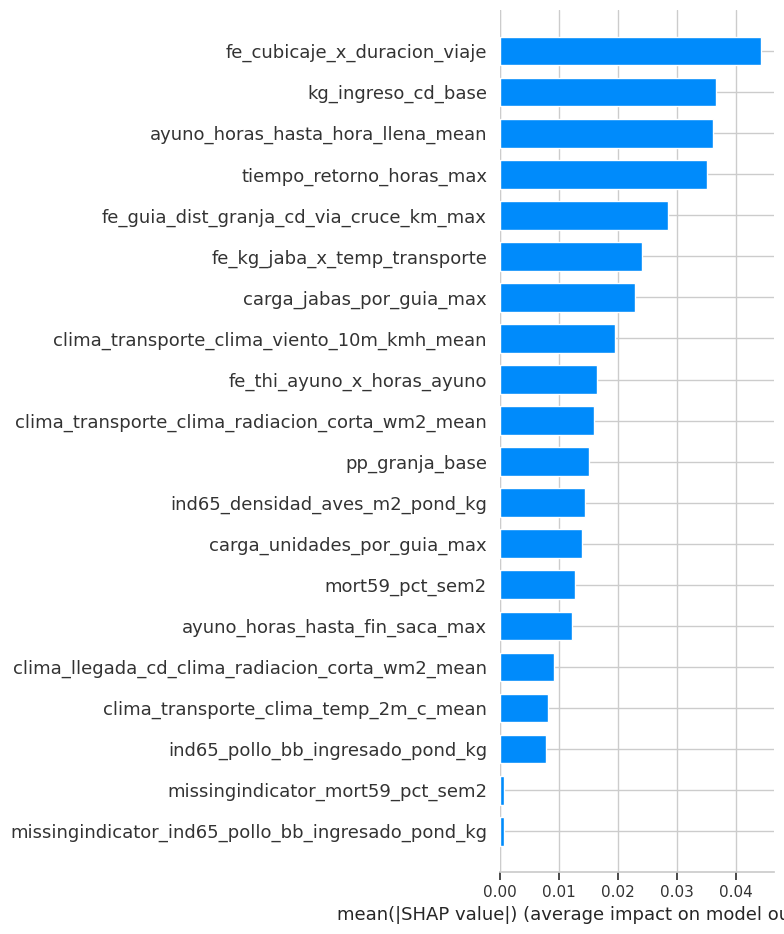

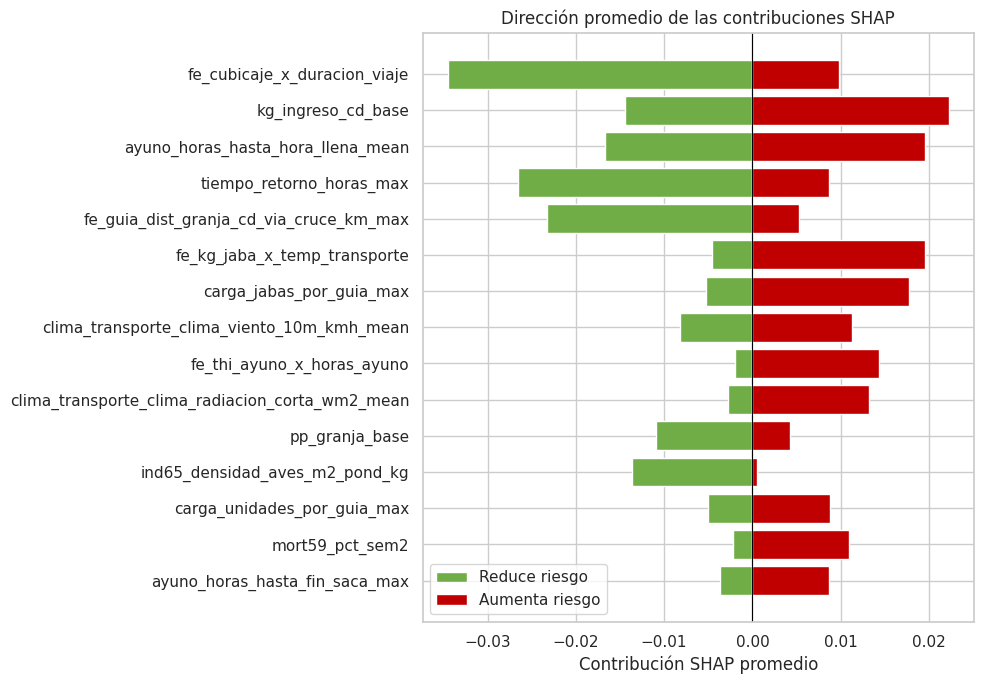

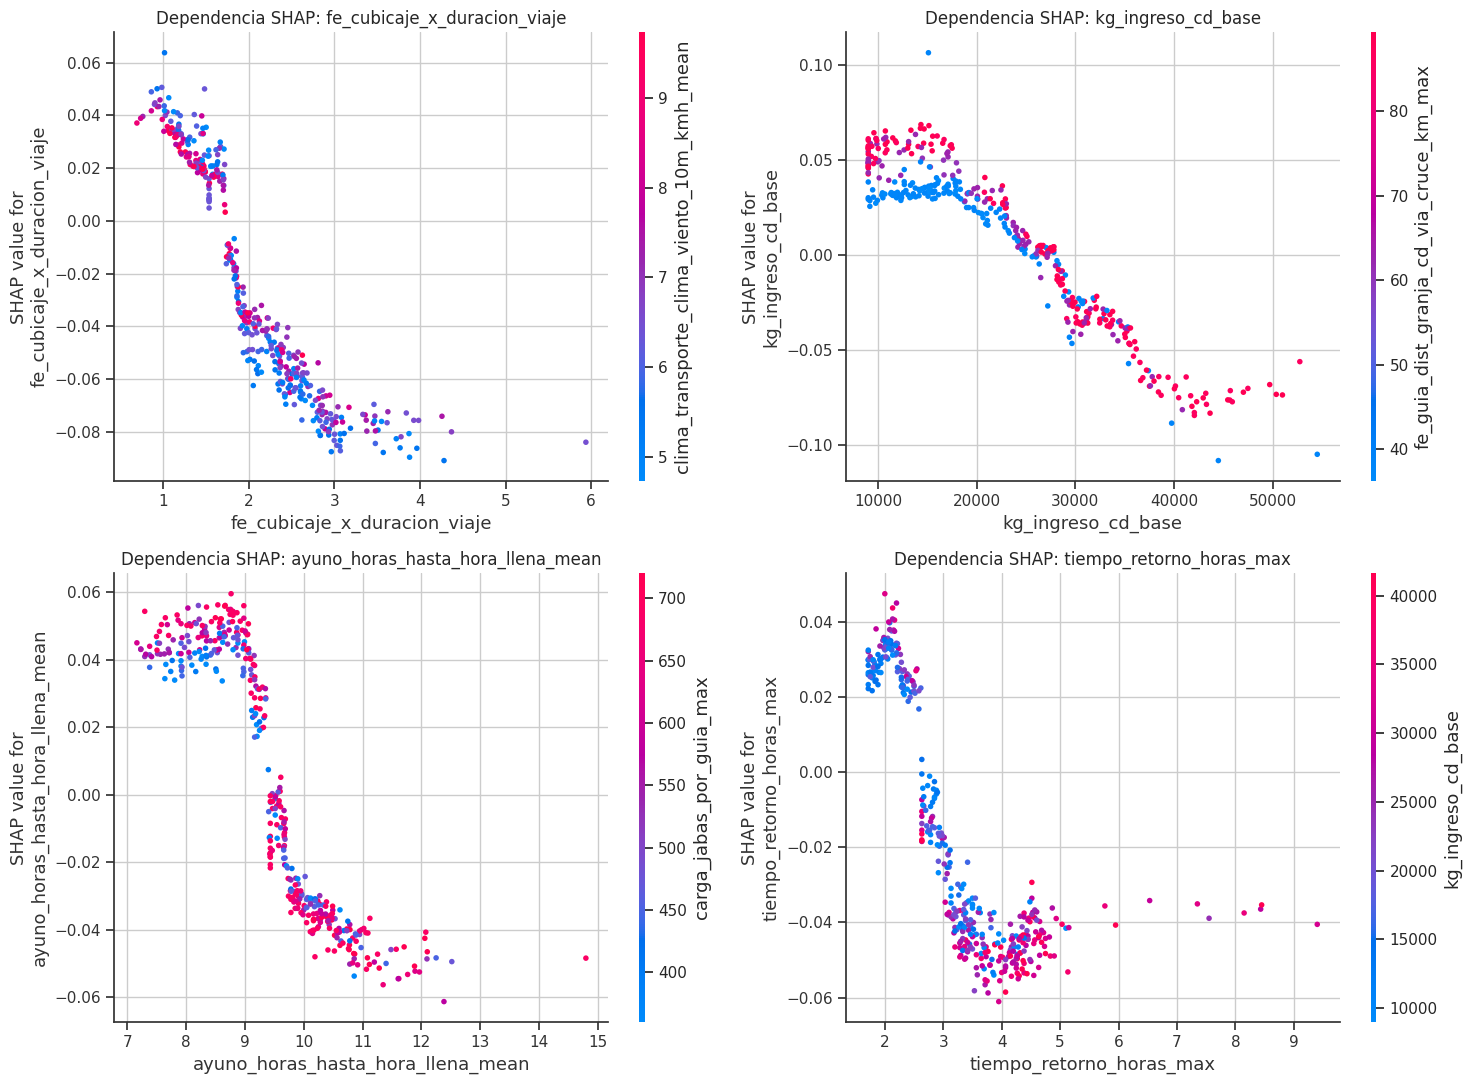

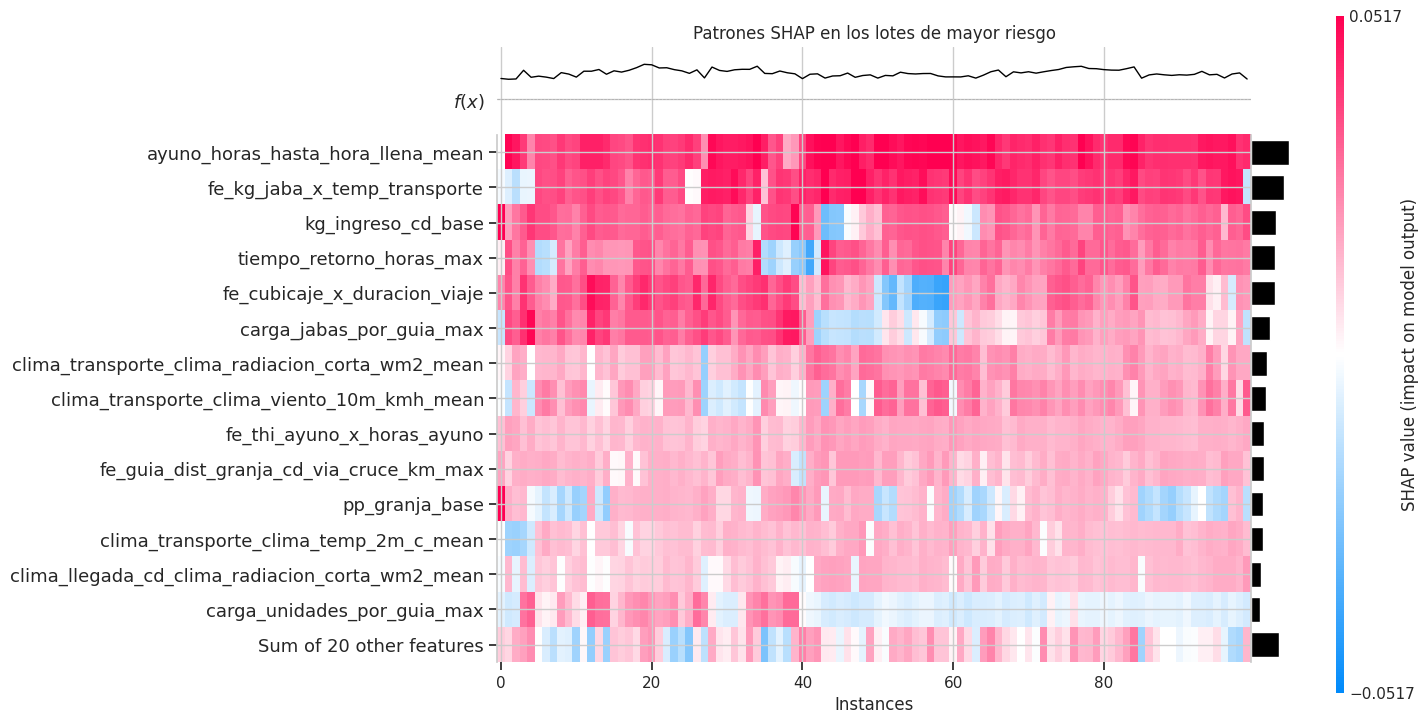

,fila_test,lote_comercial_id,fecha,target_pct_mvt,clase_real,probabilidad_modelo_raw,probabilidad_alta_merma_calibrada,politica_operativa,threshold_operativo,alerta_modelo,...,top_1_shap,top_1_sentido,top_2_variable,top_2_valor_modelo,top_2_shap,top_2_sentido,top_3_variable,top_3_valor_modelo,top_3_shap,top_3_sentido
198,198,CD-VENTA_14528_2025-07-01_GRANJA-BOLIVAR-I,2025-07-01,2.05,1,0.927396,0.927396,costo_fn_20x,0.312765,1,...,0.043364,aumenta_riesgo,ayuno_horas_hasta_hora_llena_mean,7.875000,0.041789,aumenta_riesgo,tiempo_retorno_horas_max,2.050000,0.034529,aumenta_riesgo
278,278,CD-VENTA_14608_2025-08-03_GRANJA-MELGAR-VIII,2025-08-03,2.34,1,0.922491,0.922491,costo_fn_20x,0.312765,1,...,0.042400,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,0.759352,0.039596,aumenta_riesgo,tiempo_retorno_horas_max,2.066667,0.034727,aumenta_riesgo
105,105,CD-VENTA_14434_2025-05-27_GRANJA-MELGAR-IV,2025-05-27,2.00,1,0.908017,0.908017,costo_fn_20x,0.312765,1,...,0.056024,aumenta_riesgo,tiempo_retorno_horas_max,2.200000,0.045113,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,447.808597,0.044487,aumenta_riesgo
285,285,CD-VENTA_14615_2025-08-07_GRANJA-MELGAR-IV,2025-08-07,2.10,1,0.907437,0.907437,costo_fn_20x,0.312765,1,...,0.051986,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,455.003025,0.039162,aumenta_riesgo,tiempo_retorno_horas_max,2.116667,0.037690,aumenta_riesgo
279,279,CD-VENTA_14609_2025-08-04_GRANJA-MELGAR-VIII,2025-08-04,1.58,0,0.902382,0.902382,costo_fn_20x,0.312765,1,...,0.041347,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,454.965000,0.035784,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,1.171296,0.032697,aumenta_riesgo
213,213,CD-VENTA_14543_2025-07-06_GRANJA-PUMACAHUA-II,2025-07-06,1.43,0,0.901116,0.901116,costo_fn_20x,0.312765,1,...,0.050622,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,446.473938,0.046452,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,1.098611,0.034655,aumenta_riesgo
202,202,CD-VENTA_14532_2025-07-02_GRANJA-BOLIVAR-I,2025-07-02,3.78,1,0.899751,0.899751,costo_fn_20x,0.312765,1,...,0.049907,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,468.720000,0.046035,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,1.009815,0.043619,aumenta_riesgo
271,271,CD-VENTA_14601_2025-07-31_GRANJA-MELGAR-VII,2025-07-31,2.26,1,0.895516,0.895516,costo_fn_20x,0.312765,1,...,0.042061,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,451.448516,0.037403,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,1.099531,0.035264,aumenta_riesgo
79,79,CD-VENTA_14408_2025-05-18_GRANJA-MELGAR-IX,2025-05-18,4.96,1,0.893778,0.893778,costo_fn_20x,0.312765,1,...,0.040947,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,0.734427,0.038900,aumenta_riesgo,tiempo_retorno_horas_max,2.183333,0.033757,aumenta_riesgo
39,39,CD-VENTA_14367_2025-05-04_GRANJA-MELGAR-I,2025-05-04,2.45,1,0.892607,0.892607,costo_fn_20x,0.312765,1,...,0.038573,aumenta_riesgo,fe_cubicaje_x_duracion_viaje,0.690278,0.037110,aumenta_riesgo,fe_kg_jaba_x_temp_transporte,457.726286,0.032907,aumenta_riesgo


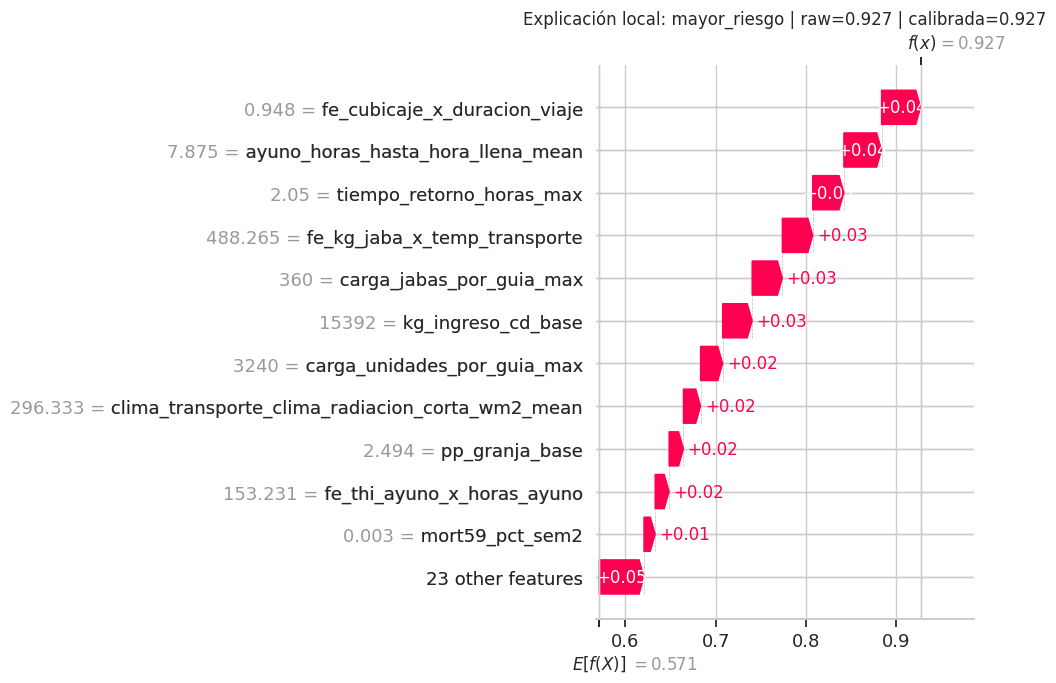

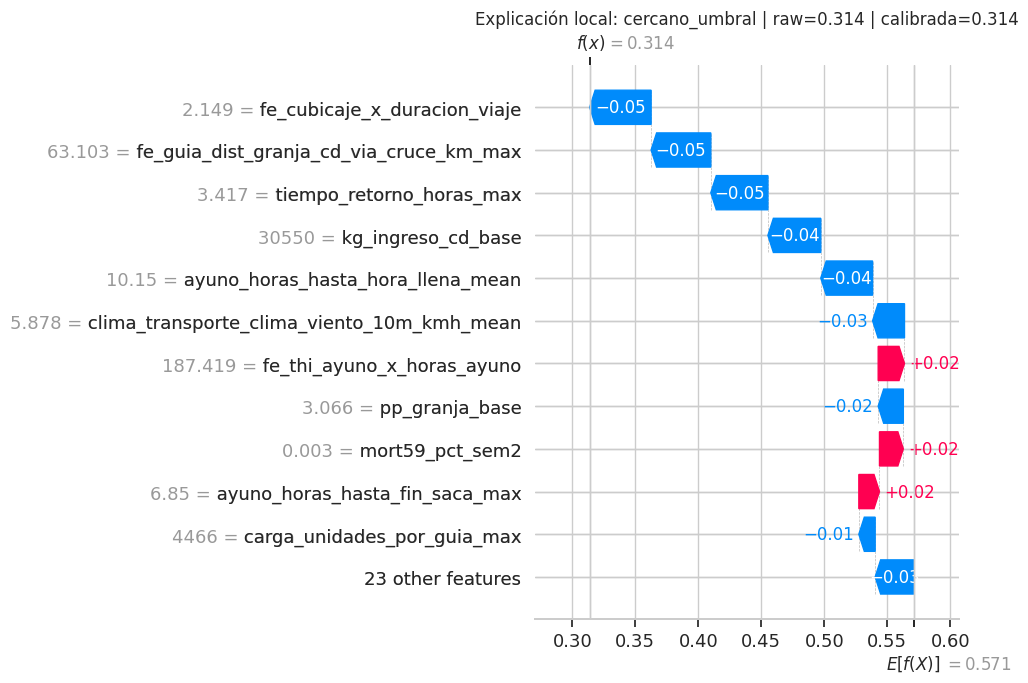

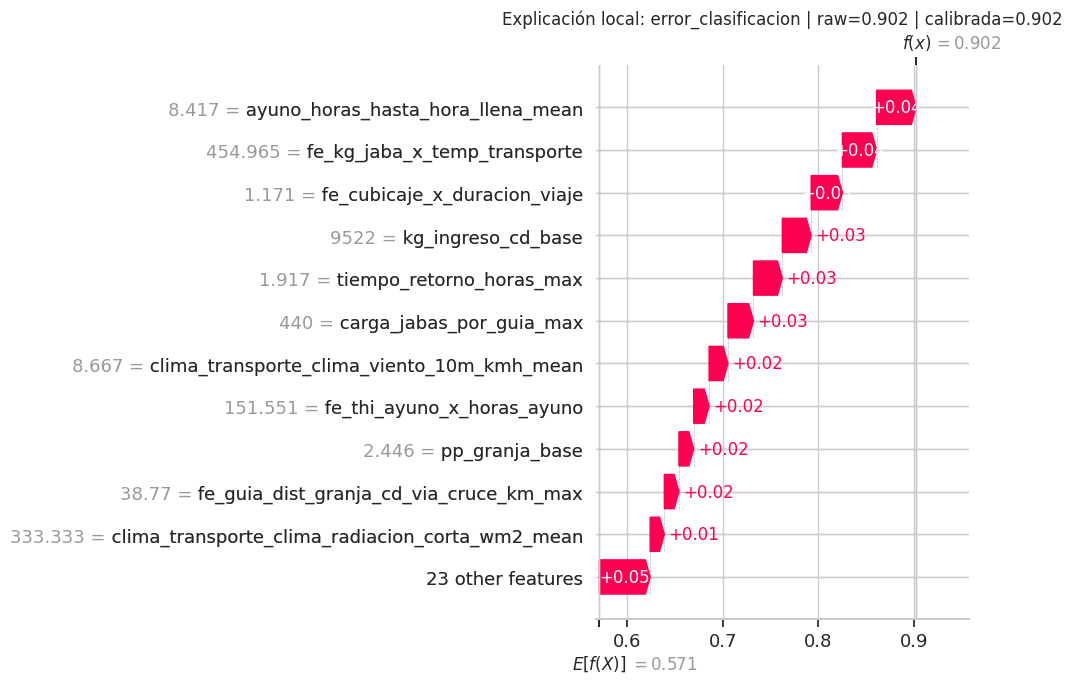

,caso,fila_test,lote_comercial_id,clase_real,probabilidad_modelo_raw,probabilidad_calibrada,politica_operativa,threshold_operativo,alerta
0,mayor_riesgo,198,CD-VENTA_14528_2025-07-01_GRANJA-BOLIVAR-I,1,0.927396,0.927396,costo_fn_20x,0.312765,1
1,cercano_umbral,97,CD-VENTA_14426_2025-05-24_GRANJA-ZELA-VI,0,0.313804,0.313804,costo_fn_20x,0.312765,1
2,error_clasificacion,279,CD-VENTA_14609_2025-08-04_GRANJA-MELGAR-VIII,0,0.902382,0.902382,costo_fn_20x,0.312765,1


Política usada en gobernanza SHAP y expedientes: costo_fn_20x | umbral: 0.312765
Lectura de gobernanza: revisar conjuntamente importancia, dirección, dependencia y explicación local.
SHAP describe el modelo; no debe interpretarse como evidencia causal ni como decisión automática.


In [ ]:
X_test_final = tx(test_sensibilidad)
feature_names = imputer.get_feature_names_out(FEATURES_FINAL).astype(str)
explainer = shap.TreeExplainer(final_model)
raw_shap = explainer.shap_values(X_test_final, check_additivity=False)
shap_values = np.asarray(raw_shap[1] if isinstance(raw_shap, list) else raw_shap)
if shap_values.ndim == 3: shap_values = shap_values[:,:,1]

expected = np.asarray(explainer.expected_value)
base_value = float(expected if expected.ndim == 0 else expected.reshape(-1)[-1])
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values), base_value),
    data=X_test_final,
    feature_names=feature_names.tolist(),
)

# Importancia por característica del modelo y agregada a las 18 variables originales.
importance_model = pd.DataFrame({
    'feature_modelo': feature_names,
    'mean_abs_shap': np.mean(np.abs(shap_values), axis=0),
    'mean_shap': np.mean(shap_values, axis=0),
    'pct_contribucion_positiva': np.mean(shap_values > 0, axis=0),
})
importance_model['variable_origen'] = importance_model.feature_modelo.str.replace('missingindicator_', '', regex=False)
importance = (importance_model.groupby('variable_origen', as_index=False)
              .agg(mean_abs_shap=('mean_abs_shap','sum'),
                   mean_shap=('mean_shap','sum'),
                   pct_contribucion_positiva=('pct_contribucion_positiva','mean'))
              .sort_values('mean_abs_shap', ascending=False))

direction_rows = []
for variable in FEATURES_FINAL:
    model_indices = np.flatnonzero(np.array([
        name == variable or name == f'missingindicator_{variable}' for name in feature_names
    ]))
    combined_shap = shap_values[:, model_indices].sum(axis=1)
    variable_index = np.flatnonzero(feature_names == variable)
    rho = np.nan
    if len(variable_index):
        values_numeric = X_test_final[:, variable_index[0]]
        valid_rho = np.isfinite(values_numeric) & np.isfinite(combined_shap)
        if valid_rho.sum() > 2 and np.unique(values_numeric[valid_rho]).size > 1:
            rho = spearmanr(values_numeric[valid_rho], combined_shap[valid_rho]).statistic
    direction_rows.append({
        'variable_origen': variable,
        'mean_abs_shap': float(np.mean(np.abs(combined_shap))),
        'mean_shap_positivo': float(np.mean(np.where(combined_shap > 0, combined_shap, 0))),
        'mean_shap_negativo': float(np.mean(np.where(combined_shap < 0, combined_shap, 0))),
        'pct_aumenta_riesgo': float(np.mean(combined_shap > 0)),
        'spearman_valor_vs_shap': rho,
    })
governance_summary = pd.DataFrame(direction_rows).sort_values('mean_abs_shap', ascending=False)

display(importance.head(18))
display(governance_summary.head(18))
importance_model.to_csv(OUT/'shap_importancia_caracteristicas_modelo.csv', index=False)
importance.to_csv(OUT/'shap_importancia_18_variables.csv', index=False)
governance_summary.to_csv(OUT/'shap_gobernanza_direccion_variables.csv', index=False)

# 1. Barras globales agregadas a las 18 variables.
top_bar = importance.head(18).sort_values('mean_abs_shap')
plt.figure(figsize=(10, 7))
plt.barh(top_bar.variable_origen, top_bar.mean_abs_shap, color='#4472C4')
plt.xlabel('Promedio de |SHAP|'); plt.title('Importancia global SHAP de las 18 variables')
plt.tight_layout(); plt.savefig(OUT/'shap_importancia_global_18_variables.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 2. Beeswarm: magnitud, dirección y distribución de cada característica.
shap.summary_plot(shap_values, X_test_final, feature_names=feature_names, max_display=20, show=False)
plt.tight_layout(); plt.savefig(OUT/'shap_beeswarm_final.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 3. Barras nativas SHAP para contrastar la lectura agregada.
shap.summary_plot(shap_values, X_test_final, feature_names=feature_names, plot_type='bar', max_display=20, show=False)
plt.tight_layout(); plt.savefig(OUT/'shap_bar_model_features.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 4. Contribuciones promedio que aumentan o reducen el riesgo.
direction_plot = governance_summary.head(15).sort_values('mean_abs_shap')
plt.figure(figsize=(10, 7))
plt.barh(direction_plot.variable_origen, direction_plot.mean_shap_negativo, color='#70AD47', label='Reduce riesgo')
plt.barh(direction_plot.variable_origen, direction_plot.mean_shap_positivo, color='#C00000', label='Aumenta riesgo')
plt.axvline(0, color='black', linewidth=.8); plt.legend()
plt.xlabel('Contribución SHAP promedio'); plt.title('Dirección promedio de las contribuciones SHAP')
plt.tight_layout(); plt.savefig(OUT/'shap_direccion_contribuciones.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 5. Dependencias de las cuatro características más influyentes, con interacción automática.
top_features = [name for name in importance_model.sort_values('mean_abs_shap', ascending=False).feature_modelo
                if not name.startswith('missingindicator_')][:4]
fig, axes = plt.subplots(2, 2, figsize=(15, 11)); axes = axes.flatten()
for ax, feature in zip(axes, top_features):
    shap.dependence_plot(
        feature, shap_values, X_test_final, feature_names=feature_names,
        interaction_index='auto', ax=ax, show=False,
    )
    ax.set_title(f'Dependencia SHAP: {feature}')
plt.tight_layout(); plt.savefig(OUT/'shap_dependencias_top4.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 6. Mapa de calor de los 100 lotes con mayor probabilidad de alta merma.
risk_order = np.argsort(p_test)[::-1]
heatmap_order = risk_order[:min(100, len(risk_order))]
plt.figure(figsize=(13, 8))
shap.plots.heatmap(shap_explanation[heatmap_order], max_display=15, show=False)
plt.gcf().set_size_inches(13, 8)
plt.title('Patrones SHAP en los lotes de mayor riesgo')
plt.tight_layout(); plt.savefig(OUT/'shap_heatmap_lotes_mayor_riesgo.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()

# 7. Expediente explicativo por lote: tres contribuciones principales y su dirección.
operating_policy = POLITICA_FINAL
operating_threshold = UMBRAL_FINAL
operating_prediction = (p_test >= operating_threshold).astype(int)
governance_rows = []
for row_index in range(len(test_sensibilidad)):
    top_indices = np.argsort(np.abs(shap_values[row_index]))[-3:][::-1]
    record = {
        'fila_test': row_index,
        'lote_comercial_id': test_sensibilidad.iloc[row_index][id_col] if id_col else row_index,
        'fecha': test_sensibilidad.iloc[row_index][date_col],
        'target_pct_mvt': test_sensibilidad.iloc[row_index][TARGET],
        'clase_real': int(y_test[row_index]),
        'probabilidad_modelo_raw': float(raw_test[row_index]),
        'probabilidad_alta_merma_calibrada': float(p_test[row_index]),
        'politica_operativa': operating_policy,
        'threshold_operativo': float(operating_threshold),
        'alerta_modelo': int(operating_prediction[row_index]),
    }
    for rank, feature_index in enumerate(top_indices, start=1):
        contribution = float(shap_values[row_index, feature_index])
        record[f'top_{rank}_variable'] = feature_names[feature_index]
        record[f'top_{rank}_valor_modelo'] = float(X_test_final[row_index, feature_index])
        record[f'top_{rank}_shap'] = contribution
        record[f'top_{rank}_sentido'] = 'aumenta_riesgo' if contribution > 0 else 'reduce_riesgo'
    governance_rows.append(record)
shap_governance_lotes = pd.DataFrame(governance_rows).sort_values('probabilidad_alta_merma_calibrada', ascending=False)
display(shap_governance_lotes.head(20))
shap_governance_lotes.to_csv(OUT/'shap_explicacion_por_lote.csv', index=False)

# 8. Waterfalls para casos representativos de auditoría.
case_indices = {
    'mayor_riesgo': int(np.argmax(p_test)),
    'cercano_umbral': int(np.argmin(np.abs(p_test - operating_threshold))),
}
errors = np.flatnonzero(operating_prediction != y_test)
if len(errors):
    case_indices['error_clasificacion'] = int(errors[np.argmax(np.abs(p_test[errors] - operating_threshold))])
else:
    case_indices['menor_riesgo'] = int(np.argmin(p_test))

case_audit_rows = []
for case_name, row_index in case_indices.items():
    plt.figure(figsize=(10, 7))
    shap.plots.waterfall(shap_explanation[row_index], max_display=12, show=False)
    plt.gcf().set_size_inches(10, 7)
    plt.title(
        f'Explicación local: {case_name} | raw={raw_test[row_index]:.3f} | '
        f'calibrada={p_test[row_index]:.3f}'
    )
    plt.tight_layout(); plt.savefig(OUT/f'shap_waterfall_{case_name}.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close()
    case_audit_rows.append({
        'caso': case_name,
        'fila_test': row_index,
        'lote_comercial_id': test_sensibilidad.iloc[row_index][id_col] if id_col else row_index,
        'clase_real': int(y_test[row_index]),
        'probabilidad_modelo_raw': float(raw_test[row_index]),
        'probabilidad_calibrada': float(p_test[row_index]),
        'politica_operativa': operating_policy,
        'threshold_operativo': float(operating_threshold),
        'alerta': int(operating_prediction[row_index]),
    })
case_audit = pd.DataFrame(case_audit_rows)
display(case_audit)
case_audit.to_csv(OUT/'shap_casos_waterfall_auditoria.csv', index=False)

print('Política usada en gobernanza SHAP y expedientes:', operating_policy, '| umbral:', f'{operating_threshold:.6f}')
print('Lectura de gobernanza: revisar conjuntamente importancia, dirección, dependencia y explicación local.')
print('SHAP describe el modelo; no debe interpretarse como evidencia causal ni como decisión automática.')


## 17. EVALUACIÓN DE SESGO Y ROBUSTEZ: DESCOMPOSICIÓN SESGO-VARIANZA

La clase distingue el sesgo algorítmico del análisis de equidad entre grupos. En este bloque se aplica la descomposición sesgo-varianza con pérdida 0-1 al Random Forest final de 18 variables. El modelo conserva sus hiperparámetros, el tratamiento de faltantes y el balanceo elegidos antes de observar el periodo de sensibilidad.

La descomposición repite el ajuste sobre muestras bootstrap del conjunto de entrenamiento. Un sesgo alto indicaría que el algoritmo comete errores sistemáticos; una varianza alta indicaría sensibilidad excesiva a cambios en la muestra de entrenamiento. Esta evaluación se interpreta junto con la validación temporal, no como sustituto de ella.

La descomposición caracteriza al clasificador. La equidad del sistema de alertas se evalúa después con la política operativa vigente costo_fn_20x, porque el umbral modifica los falsos positivos y falsos negativos.

,modelo,balanceo,rondas_bootstrap,perdida_esperada_0_1,sesgo_0_1,varianza_0_1,componente_dominante
0,Random Forest final - 18 variables,sin_balanceo,50,0.425743,0.408416,0.064059,sesgo


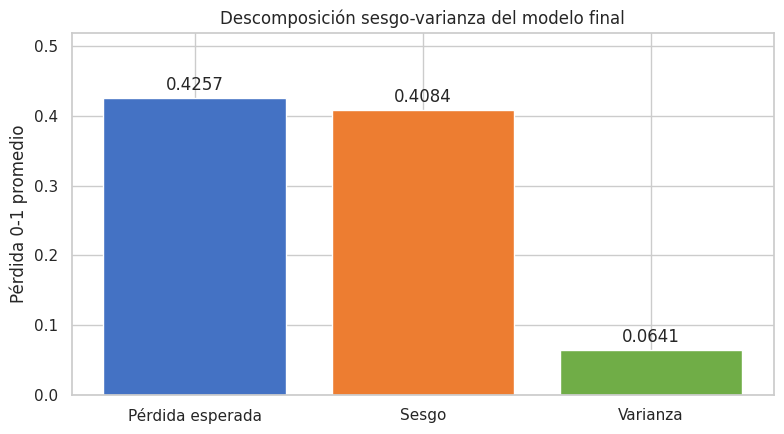

Lectura: el componente dominante es sesgo
Este diagnóstico se basa en remuestreo; no demuestra ausencia total de sesgos de datos o de evaluación.


In [ ]:

BIAS_VARIANCE_ROUNDS = 25 if MODO_RAPIDO else 50

avg_expected_loss, avg_bias, avg_variance = bias_variance_decomp(
    final_model,
    np.asarray(X_model_res),
    np.asarray(y_model_res).ravel(),
    np.asarray(X_test_final),
    np.asarray(y_test).ravel(),
    loss='0-1_loss',
    num_rounds=BIAS_VARIANCE_ROUNDS,
    random_seed=RANDOM_STATE,
)

bias_variance_result = pd.DataFrame([{
    'modelo': 'Random Forest final - 18 variables',
    'balanceo': BALANCE_FINAL,
    'rondas_bootstrap': BIAS_VARIANCE_ROUNDS,
    'perdida_esperada_0_1': float(avg_expected_loss),
    'sesgo_0_1': float(avg_bias),
    'varianza_0_1': float(avg_variance),
    'componente_dominante': 'sesgo' if avg_bias > avg_variance else 'varianza',
}])
display(bias_variance_result)
bias_variance_result.to_csv(OUT/'sesgo_varianza_modelo_final.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['Pérdida esperada', 'Sesgo', 'Varianza']
values = [avg_expected_loss, avg_bias, avg_variance]
bars = ax.bar(labels, values, color=['#4472C4', '#ED7D31', '#70AD47'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('Pérdida 0-1 promedio')
ax.set_title('Descomposición sesgo-varianza del modelo final')
ax.set_ylim(0, max(values) * 1.22 if max(values) > 0 else 1)
plt.tight_layout()
plt.savefig(OUT/'sesgo_varianza_modelo_final.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close()

print('Lectura: el componente dominante es', bias_variance_result.loc[0, 'componente_dominante'])
print('Este diagnóstico se basa en remuestreo; no demuestra ausencia total de sesgos de datos o de evaluación.')

## 18. EVALUACIÓN DE EQUIDAD OPERACIONAL CON LA POLÍTICA costo_fn_20x

En este proceso no se toman decisiones sobre personas. Por ello, granja, sexo de las aves, trimestre y cobertura climática no se denominan atributos protegidos en sentido social; se utilizan como grupos operativos para auditar si la calidad de la alerta es comparable entre contextos.

El eje principal es la familia de granja. Las sedes identificadas con números romanos se agrupan bajo su familia para evitar conclusiones basadas en muestras muy pequeñas. Solo se emite un diagnóstico de paridad cuando el grupo tiene por lo menos 20 lotes, 5 positivos y 5 negativos. Los demás grupos se conservan en las tablas como evidencia descriptiva.

Se aplica exactamente la probabilidad calibrada y el umbral aprendido para la política final costo_fn_20x. Se calculan las metodologías: paridad demográfica o tasa de selección, igualdad de oportunidad mediante TPR/recall, igualdad predictiva mediante FPR, predictive parity mediante precisión, igualdad de accuracy y equalized odds. Se usa epsilon = 0,80 como regla de diagnóstico. Debido a que la prevalencia real de alta merma puede diferir entre granjas, la tasa de alertas por sí sola no prueba inequidad; para control interno se prioriza la comparación del TPR y del FNR, porque el falso negativo es el error más crítico.

,dimension,variable_grupo,grupo,n,positivos_reales,negativos_reales,prevalencia,tasa_seleccion_stp,tpr_recall,fnr,...,error_rate,probabilidad_media,tn,fp,fn,tp,muestra_suficiente,pr_auc,roc_auc,brier
18,Cobertura climática,cobertura_clima,CON_CLIMA,394,81,313,0.205584,0.868020,1.0,0.0,...,0.662437,0.574926,52,261,0,81,True,0.560631,0.822309,0.268639
19,Cobertura climática,cobertura_clima,SIN_CLIMA,10,3,7,0.300000,0.800000,1.0,0.0,...,0.500000,0.428091,2,5,0,3,False,0.809524,0.809524,0.167178
11,Familia de granja,familia_granja,ZELA,100,19,81,0.190000,0.920000,1.0,0.0,...,0.730000,0.554245,8,73,0,19,True,0.302131,0.565952,0.295919
6,Familia de granja,familia_granja,MELGAR,62,36,26,0.580645,1.000000,1.0,0.0,...,0.419355,0.816353,0,26,0,36,True,0.822036,0.772436,0.272260
4,Familia de granja,familia_granja,JOSE OLAYA,61,2,59,0.032787,0.655738,1.0,0.0,...,0.622951,0.384879,21,38,0,2,False,0.208333,0.889831,0.159505
2,Familia de granja,familia_granja,DIEGO FERRE,51,2,49,0.039216,0.745098,1.0,0.0,...,0.705882,0.421452,13,36,0,2,False,0.222222,0.816327,0.188203
8,Familia de granja,familia_granja,MIGUEL GRAU,37,1,36,0.027027,0.783784,1.0,0.0,...,0.756757,0.406922,8,28,0,1,False,0.083333,0.694444,0.183223
10,Familia de granja,familia_granja,RUIZ GALLO,25,10,15,0.400000,1.000000,1.0,0.0,...,0.600000,0.730602,0,15,0,10,True,0.641549,0.686667,0.336228
9,Familia de granja,familia_granja,PUMACAHUA,20,2,18,0.100000,1.000000,1.0,0.0,...,0.900000,0.801801,0,18,0,2,False,0.133929,0.472222,0.586087
3,Familia de granja,familia_granja,ELIAS AGUIRRE,18,0,18,0.000000,0.777778,NaN,NaN,...,0.777778,0.420400,4,14,0,0,False,NaN,NaN,NaN


,dimension,criterio,metrica,grupos_elegibles,grupo_referencia_mayor_n,minimo,maximo,brecha_absoluta,ratio_min_max,epsilon,cumple_epsilon_0_80
0,Cobertura climática,paridad_demografica_stp,tasa_seleccion_stp,1,CON_CLIMA,0.868020,0.868020,0.000000,1.000000,0.8,False
1,Cobertura climática,igualdad_oportunidad_tpr,tpr_recall,1,CON_CLIMA,1.000000,1.000000,0.000000,1.000000,0.8,False
2,Cobertura climática,igualdad_predictiva_fpr,fpr,1,CON_CLIMA,0.833866,0.833866,0.000000,1.000000,0.8,False
3,Cobertura climática,paridad_predictiva_ppv,ppv_precision,1,CON_CLIMA,0.236842,0.236842,0.000000,1.000000,0.8,False
4,Cobertura climática,igualdad_accuracy,accuracy,1,CON_CLIMA,0.337563,0.337563,0.000000,1.000000,0.8,False
5,Cobertura climática,paridad_fnr_control,fnr,1,CON_CLIMA,0.000000,0.000000,0.000000,NaN,0.8,False
6,Familia de granja,paridad_demografica_stp,tasa_seleccion_stp,3,ZELA,0.920000,1.000000,0.080000,0.920000,0.8,True
7,Familia de granja,igualdad_oportunidad_tpr,tpr_recall,3,ZELA,1.000000,1.000000,0.000000,1.000000,0.8,True
8,Familia de granja,igualdad_predictiva_fpr,fpr,3,ZELA,0.901235,1.000000,0.098765,0.901235,0.8,True
9,Familia de granja,paridad_predictiva_ppv,ppv_precision,3,ZELA,0.206522,0.580645,0.374123,0.355676,0.8,False


,dimension,tpr_paridad,fpr_paridad,equalized_odds_cumple
0,Cobertura climática,False,False,False
1,Familia de granja,True,True,True
2,Sexo dominante de las aves,True,False,False
3,Trimestre operativo,True,True,True


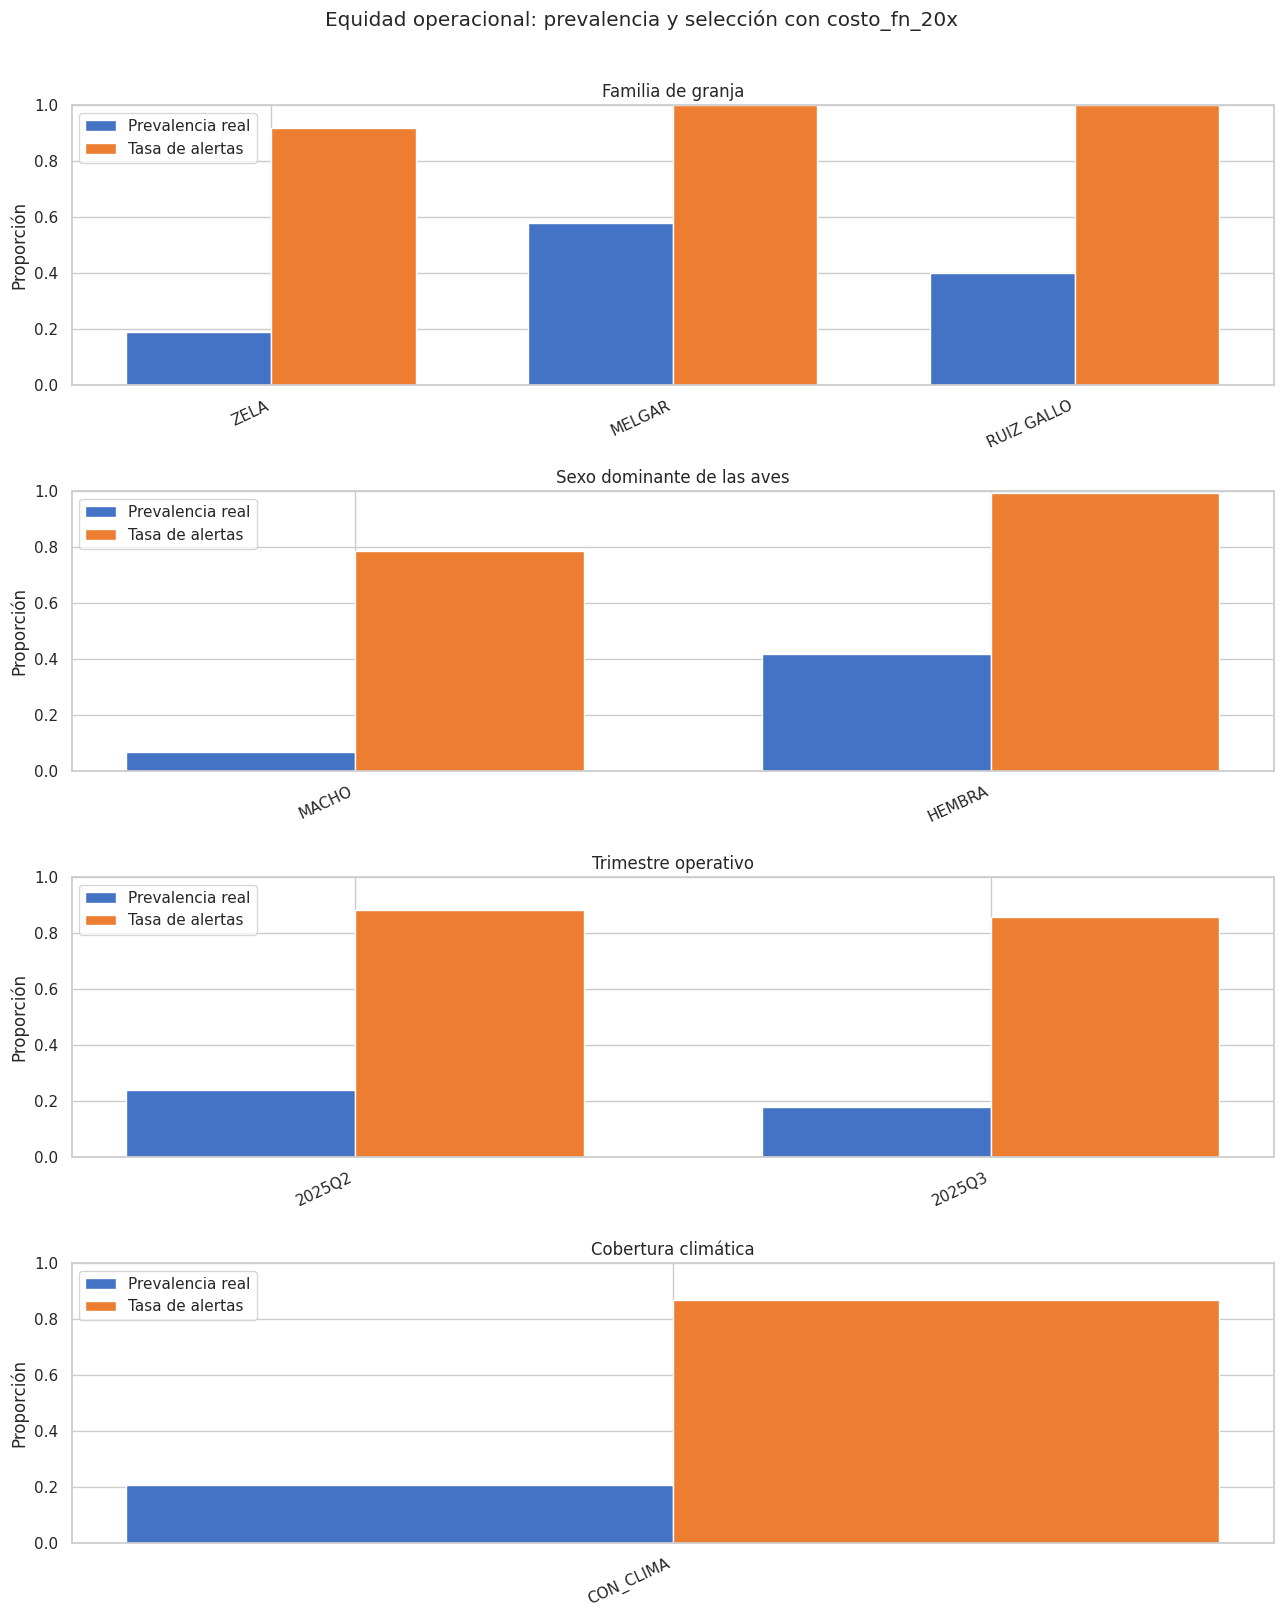

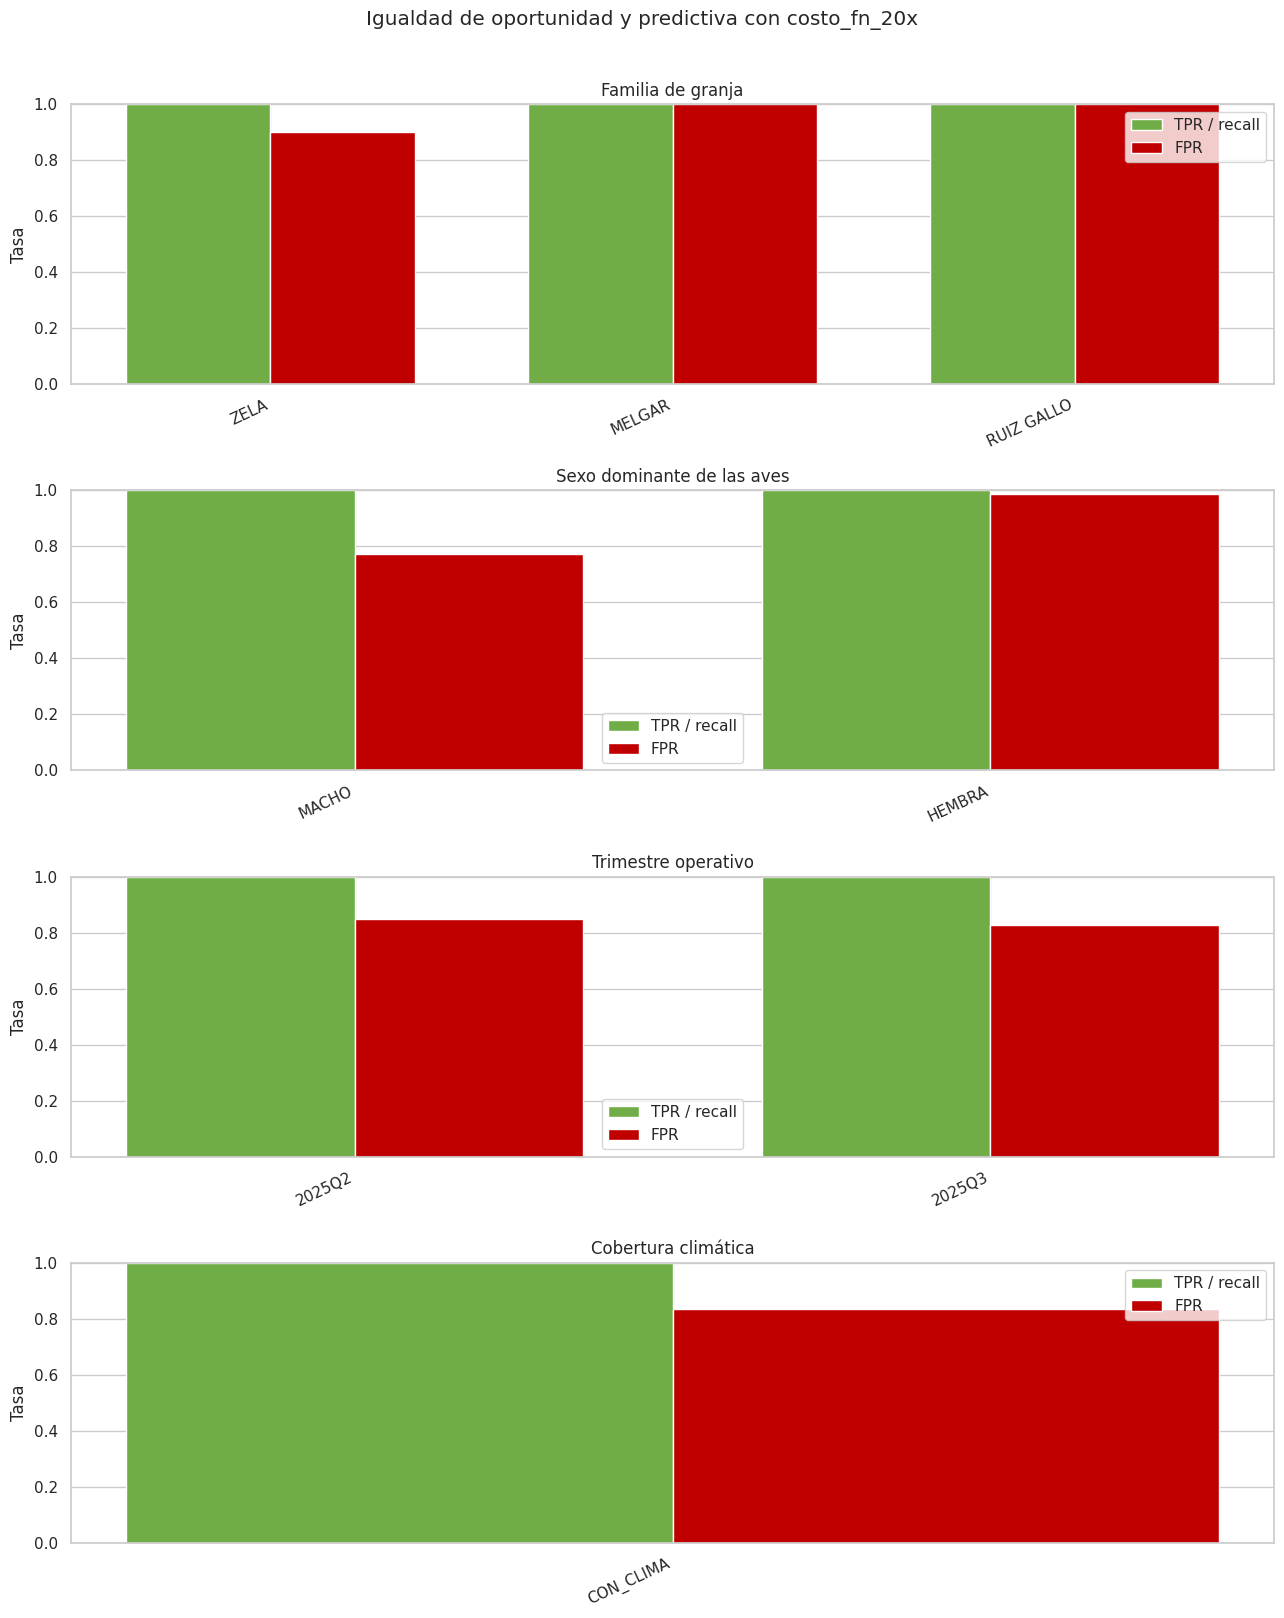

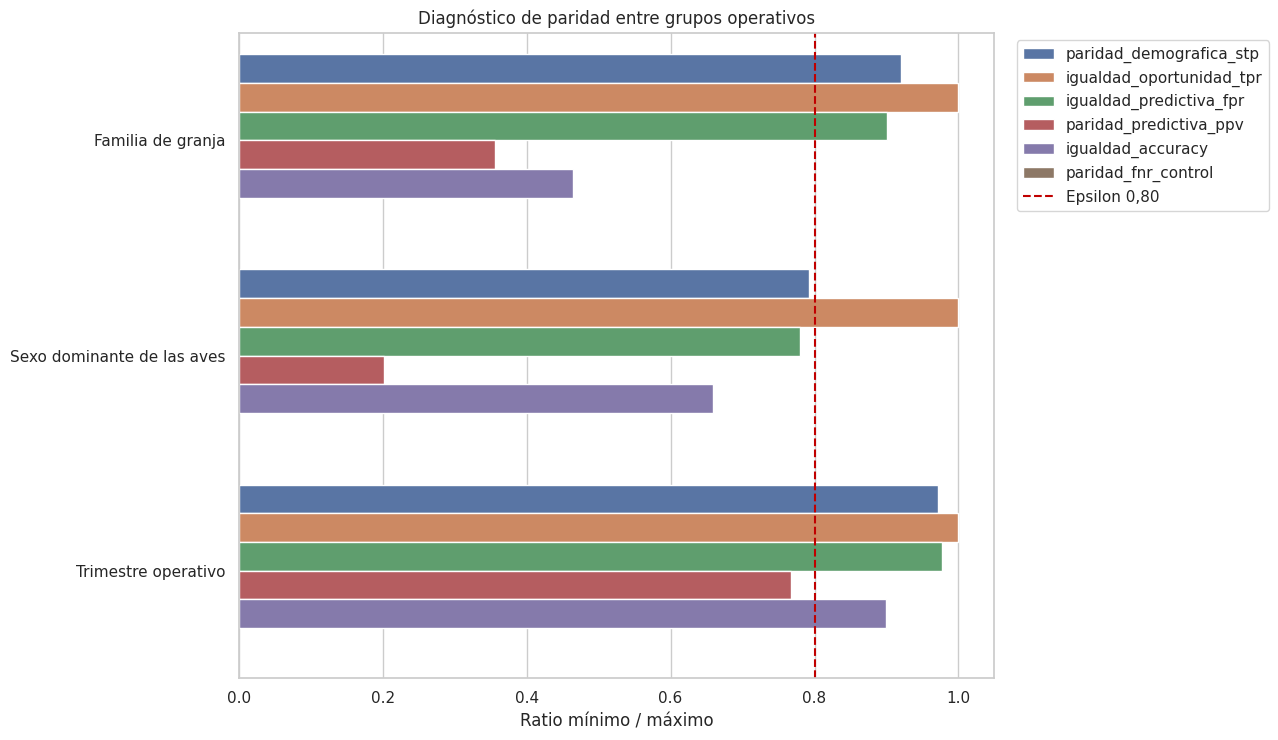

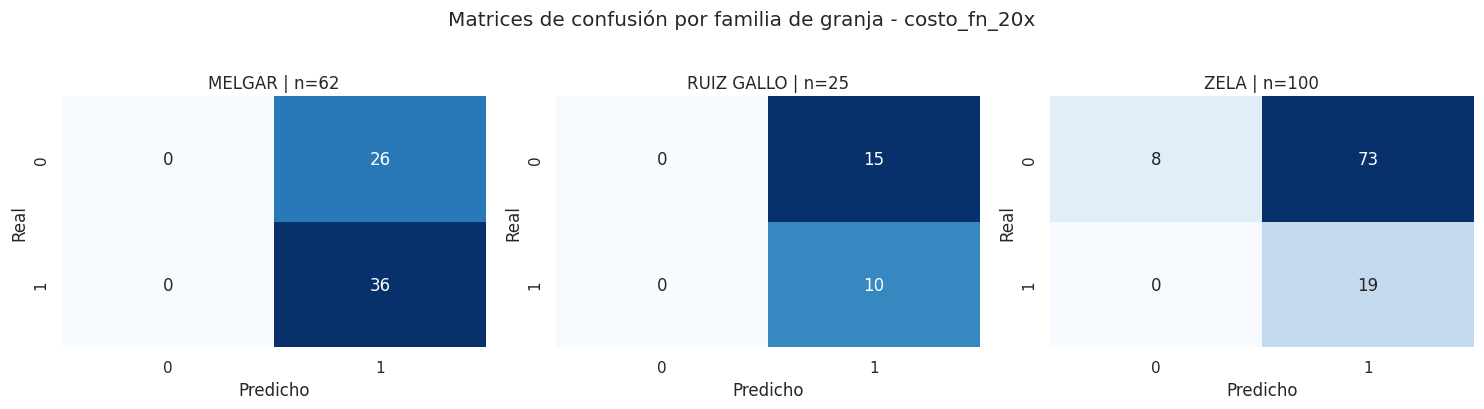

Política evaluada: costo_fn_20x | umbral: 0.312765
No se detectó una disparidad TPR superior al criterio epsilon entre las familias de granja elegibles.
Una diferencia de prevalencia o tasa de alertas no demuestra por sí sola inequidad ni causalidad.
Los resultados son de sensibilidad temporal y deben confirmarse en un periodo futuro no consultado.


In [ ]:
FAIRNESS_EPSILON = 0.80
MIN_GROUP_N = 20
MIN_CLASS_N = 5

fairness_frame = test_sensibilidad.copy().reset_index(drop=True)
fairness_frame['clase_real'] = np.asarray(y_test, int)
fairness_frame['probabilidad_alta_merma'] = np.asarray(p_test, float)
fairness_frame['alerta_costo_fn_20x'] = (p_test >= UMBRAL_FINAL).astype(int)

def family_granja(series):
    result = series.fillna('SIN_DATO').astype(str).str.upper().str.strip()
    result = result.str.replace(r'^GRANJA\s+', '', regex=True)
    result = result.str.replace(r'\s+(?:I|II|III|IV|V|VI|VII|VIII|IX|X)$', '', regex=True)
    return result

if 'granja_base' in fairness_frame:
    fairness_frame['familia_granja'] = family_granja(fairness_frame['granja_base'])
if 'ayuno_sexo_dominante' in fairness_frame:
    fairness_frame['sexo_aves'] = fairness_frame['ayuno_sexo_dominante'].fillna('SIN_DATO').astype(str).str.upper()
fairness_frame['trimestre_operativo'] = fairness_frame[date_col].dt.to_period('Q').astype(str)
climate_reference = 'clima_transporte_clima_temp_2m_c_mean'
if climate_reference in fairness_frame:
    fairness_frame['cobertura_clima'] = np.where(
        fairness_frame[climate_reference].notna(), 'CON_CLIMA', 'SIN_CLIMA'
    )

group_specs = [
    ('familia_granja', 'Familia de granja'),
    ('sexo_aves', 'Sexo dominante de las aves'),
    ('trimestre_operativo', 'Trimestre operativo'),
    ('cobertura_clima', 'Cobertura climática'),
]
group_specs = [(column, label) for column, label in group_specs if column in fairness_frame]

def safe_rate(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan

def group_fairness_metrics(frame, group_column, dimension_label):
    rows = []
    for group_value, part in frame.groupby(group_column, dropna=False):
        y_true = part['clase_real'].to_numpy()
        y_pred = part['alerta_costo_fn_20x'].to_numpy()
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        positives, negatives = int(tp + fn), int(tn + fp)
        row = {
            'dimension': dimension_label,
            'variable_grupo': group_column,
            'grupo': str(group_value),
            'n': int(len(part)),
            'positivos_reales': positives,
            'negativos_reales': negatives,
            'prevalencia': safe_rate(positives, len(part)),
            'tasa_seleccion_stp': safe_rate(tp + fp, len(part)),
            'tpr_recall': safe_rate(tp, tp + fn),
            'fnr': safe_rate(fn, tp + fn),
            'fpr': safe_rate(fp, fp + tn),
            'tnr_especificidad': safe_rate(tn, tn + fp),
            'ppv_precision': safe_rate(tp, tp + fp),
            'npv': safe_rate(tn, tn + fn),
            'accuracy': safe_rate(tp + tn, len(part)),
            'error_rate': safe_rate(fp + fn, len(part)),
            'probabilidad_media': float(part['probabilidad_alta_merma'].mean()),
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        }
        row['muestra_suficiente'] = (
            row['n'] >= MIN_GROUP_N and positives >= MIN_CLASS_N and negatives >= MIN_CLASS_N
        )
        if positives and negatives:
            row['pr_auc'] = average_precision_score(y_true, part['probabilidad_alta_merma'])
            row['roc_auc'] = roc_auc_score(y_true, part['probabilidad_alta_merma'])
            row['brier'] = brier_score_loss(y_true, part['probabilidad_alta_merma'])
        else:
            row['pr_auc'] = row['roc_auc'] = row['brier'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

fairness_tables = [group_fairness_metrics(fairness_frame, column, label)
                   for column, label in group_specs]
fairness_by_group = pd.concat(fairness_tables, ignore_index=True)

parity_metrics = {
    'paridad_demografica_stp': 'tasa_seleccion_stp',
    'igualdad_oportunidad_tpr': 'tpr_recall',
    'igualdad_predictiva_fpr': 'fpr',
    'paridad_predictiva_ppv': 'ppv_precision',
    'igualdad_accuracy': 'accuracy',
    'paridad_fnr_control': 'fnr',
}
parity_rows = []
ratio_reference_rows = []
for dimension, dimension_table in fairness_by_group.groupby('dimension'):
    eligible = dimension_table[dimension_table['muestra_suficiente']].copy()
    reference_group = eligible.sort_values('n', ascending=False).iloc[0]['grupo'] if len(eligible) else None
    for fairness_name, metric in parity_metrics.items():
        values = eligible[['grupo', metric]].dropna()
        minimum = values[metric].min() if len(values) else np.nan
        maximum = values[metric].max() if len(values) else np.nan
        ratio_min_max = safe_rate(minimum, maximum) if pd.notna(maximum) else np.nan
        parity_rows.append({
            'dimension': dimension,
            'criterio': fairness_name,
            'metrica': metric,
            'grupos_elegibles': int(len(eligible)),
            'grupo_referencia_mayor_n': reference_group,
            'minimo': minimum,
            'maximo': maximum,
            'brecha_absoluta': maximum - minimum if pd.notna(maximum) else np.nan,
            'ratio_min_max': ratio_min_max,
            'epsilon': FAIRNESS_EPSILON,
            'cumple_epsilon_0_80': bool(
                len(eligible) >= 2 and pd.notna(ratio_min_max) and ratio_min_max >= FAIRNESS_EPSILON
            ),
        })
        if reference_group is not None:
            reference_value = eligible.loc[eligible.grupo.eq(reference_group), metric].iloc[0]
            for _, group_row in eligible.iterrows():
                ratio_reference = safe_rate(group_row[metric], reference_value)
                ratio_reference_rows.append({
                    'dimension': dimension, 'criterio': fairness_name, 'metrica': metric,
                    'grupo': group_row['grupo'], 'grupo_referencia': reference_group,
                    'valor_grupo': group_row[metric], 'valor_referencia': reference_value,
                    'ratio_vs_referencia': ratio_reference,
                    'cumple_rango_0_80_1_25': bool(
                        pd.notna(ratio_reference) and
                        FAIRNESS_EPSILON <= ratio_reference <= 1 / FAIRNESS_EPSILON
                    ),
                })

fairness_parity = pd.DataFrame(parity_rows)
fairness_ratios_reference = pd.DataFrame(ratio_reference_rows)

equalized_rows = []
for dimension in fairness_parity.dimension.unique():
    block = fairness_parity[fairness_parity.dimension.eq(dimension)].set_index('criterio')
    tpr_ok = bool(block.loc['igualdad_oportunidad_tpr', 'cumple_epsilon_0_80'])
    fpr_ok = bool(block.loc['igualdad_predictiva_fpr', 'cumple_epsilon_0_80'])
    equalized_rows.append({
        'dimension': dimension,
        'tpr_paridad': tpr_ok,
        'fpr_paridad': fpr_ok,
        'equalized_odds_cumple': tpr_ok and fpr_ok,
    })
equalized_odds = pd.DataFrame(equalized_rows)

display(fairness_by_group.sort_values(['dimension', 'n'], ascending=[True, False]))
display(fairness_parity)
display(equalized_odds)

fairness_by_group.to_csv(OUT/'equidad_metricas_por_grupo.csv', index=False)
fairness_parity.to_csv(OUT/'equidad_paridad_resumen.csv', index=False)
fairness_ratios_reference.to_csv(OUT/'equidad_ratios_vs_referencia.csv', index=False)
equalized_odds.to_csv(OUT/'equidad_equalized_odds.csv', index=False)

# Gráfico 1: prevalencia real frente a tasa de alertas por grupo operativo.
eligible_plot = fairness_by_group[fairness_by_group.muestra_suficiente].copy()
fig, axes = plt.subplots(len(group_specs), 1, figsize=(13, 4 * len(group_specs)), squeeze=False)
for ax, (_, label) in zip(axes.flatten(), group_specs):
    plot_data = eligible_plot[eligible_plot.dimension.eq(label)].sort_values('n', ascending=False)
    x = np.arange(len(plot_data)); width = .36
    ax.bar(x - width/2, plot_data.prevalencia, width, label='Prevalencia real', color='#4472C4')
    ax.bar(x + width/2, plot_data.tasa_seleccion_stp, width, label='Tasa de alertas', color='#ED7D31')
    ax.set_xticks(x); ax.set_xticklabels(plot_data.grupo, rotation=25, ha='right')
    ax.set_ylim(0, 1); ax.set_title(label); ax.set_ylabel('Proporción'); ax.legend()
plt.suptitle('Equidad operacional: prevalencia y selección con costo_fn_20x', y=1.01)
plt.tight_layout(); plt.savefig(OUT/'equidad_prevalencia_vs_alertas.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close()

# Gráfico 2: TPR y FPR. El TPR es prioritario porque su complemento es el FNR.
fig, axes = plt.subplots(len(group_specs), 1, figsize=(13, 4 * len(group_specs)), squeeze=False)
for ax, (_, label) in zip(axes.flatten(), group_specs):
    plot_data = eligible_plot[eligible_plot.dimension.eq(label)].sort_values('n', ascending=False)
    x = np.arange(len(plot_data)); width = .36
    ax.bar(x - width/2, plot_data.tpr_recall, width, label='TPR / recall', color='#70AD47')
    ax.bar(x + width/2, plot_data.fpr, width, label='FPR', color='#C00000')
    ax.set_xticks(x); ax.set_xticklabels(plot_data.grupo, rotation=25, ha='right')
    ax.set_ylim(0, 1); ax.set_title(label); ax.set_ylabel('Tasa'); ax.legend()
plt.suptitle('Igualdad de oportunidad y predictiva con costo_fn_20x', y=1.01)
plt.tight_layout(); plt.savefig(OUT/'equidad_tpr_fpr_por_grupo.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close()

# Gráfico 3: ratios min/max; valores bajo 0,80 requieren revisión.
parity_plot = fairness_parity[fairness_parity.grupos_elegibles.ge(2)].copy()
plt.figure(figsize=(13, max(5, .42 * len(parity_plot))))
sns.barplot(data=parity_plot, y='dimension', x='ratio_min_max', hue='criterio')
plt.axvline(FAIRNESS_EPSILON, color='#C00000', linestyle='--', label='Epsilon 0,80')
plt.xlim(0, 1.05); plt.xlabel('Ratio mínimo / máximo'); plt.ylabel('')
plt.title('Diagnóstico de paridad entre grupos operativos')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.savefig(OUT/'equidad_ratios_paridad.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close()

# Gráfico 4: matrices de confusión de familias de granja con muestra suficiente.
farm_data = eligible_plot[eligible_plot.variable_grupo.eq('familia_granja')].copy()
if len(farm_data):
    cols = min(3, len(farm_data)); rows = int(np.ceil(len(farm_data) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    for ax, (_, row) in zip(axes.flatten(), farm_data.iterrows()):
        matrix = np.array([[row.tn, row.fp], [row.fn, row.tp]])
        sns.heatmap(matrix, annot=True, fmt='.0f', cbar=False, cmap='Blues', ax=ax)
        ax.set_title(f"{row.grupo} | n={int(row.n)}")
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    for ax in axes.flatten()[len(farm_data):]: ax.axis('off')
    plt.suptitle('Matrices de confusión por familia de granja - costo_fn_20x', y=1.02)
    plt.tight_layout(); plt.savefig(OUT/'equidad_matrices_confusion_granjas.png', dpi=180, bbox_inches='tight')
    plt.show(); plt.close()

farm_tpr = fairness_parity[
    fairness_parity.dimension.eq('Familia de granja') &
    fairness_parity.criterio.eq('igualdad_oportunidad_tpr')
]
if len(farm_tpr) and farm_tpr.iloc[0].grupos_elegibles >= 2:
    if farm_tpr.iloc[0].cumple_epsilon_0_80:
        fairness_conclusion = 'No se detectó una disparidad TPR superior al criterio epsilon entre las familias de granja elegibles.'
    else:
        fairness_conclusion = 'Se detectó una alerta de disparidad TPR entre familias de granja; debe revisarse antes de congelar el modelo.'
else:
    fairness_conclusion = 'La muestra no permite concluir paridad TPR entre familias de granja con el criterio definido.'

print('Política evaluada:', POLITICA_FINAL, '| umbral:', f'{UMBRAL_FINAL:.6f}')
print(fairness_conclusion)
print('Una diferencia de prevalencia o tasa de alertas no demuestra por sí sola inequidad ni causalidad.')
print('Los resultados son de sensibilidad temporal y deben confirmarse en un periodo futuro no consultado.')

### Interpretación metodológica de sesgo y equidad

- La descomposición sesgo-varianza responde si el algoritmo es sistemáticamente erróneo o excesivamente sensible a la muestra. No identifica por sí sola sesgos históricos de medición o de evaluación.
- La evaluación por familias de granja busca detectar sesgo de evaluación: una métrica global aceptable puede ocultar falsos negativos concentrados en determinados orígenes.
- Para este objetivo de control interno, igualdad de oportunidad (TPR) y FNR tienen prioridad. Un TPR menor en una granja significa que allí el modelo deja pasar proporcionalmente más lotes que realmente superan 1,7 %.
- La paridad demográfica se informa, pero no se exige de forma aislada: si la prevalencia de alta merma es distinta entre granjas, es razonable que también cambie la tasa de alertas.
- Equalized odds exige simultáneamente TPR y FPR comparables. Puede entrar en tensión con precisión, carga de revisión y costo de falsos negativos; por eso ninguna mitigación se aplica automáticamente.
- Si un grupo incumple epsilon = 0,80, el hallazgo se trata como señal de revisión. Antes de modificar el modelo se debe comprobar tamaño de muestra, prevalencia, calidad de datos, calibración y estabilidad temporal.
- Granja, sexo de las aves, trimestre y cobertura climática son segmentos operativos, no atributos protegidos de personas. El resultado evalúa consistencia del control, no discriminación.